In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from helper_utils import (
    data_split, boxplot_grid, bar_chart_grid,
    correlation_table, scatter_subplot, missing_summary,
)
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("./data/AmesHousing.csv")
X_train, X_test, y_train, y_test = data_split(df)

In [3]:
df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,382,527359050,20,RL,80.000,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,7,5,1976,1976,Gable,CompShg,HdBoard,HdBoard,BrkFace,189.000,TA,TA,CBlock,Gd,TA,No,Unf,0.000,Unf,0.000,"1,090.000","1,090.000",GasA,TA,Y,SBrkr,1370,0,0,1370,0.000,0.000,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2.000,479.000,TA,TA,Y,0,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Family,152000
1,835,906475070,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,1Fam,2Story,5,5,1967,1967,Flat,Tar&Grv,Plywood,Plywood,NaN,0.000,TA,TA,PConc,TA,Gd,Gd,LwQ,249.000,ALQ,764.000,0.000,"1,013.000",GasA,TA,Y,SBrkr,1160,966,0,2126,0.000,1.000,2,1,3,1,TA,7,Min2,0,NaN,Attchd,"1,967.000",Fin,2.000,538.000,TA,TA,Y,486,0,0,0,225,0,NaN,NaN,NaN,0,6,2009,WD,Abnorml,185000
2,1899,534429030,90,RL,70.000,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,Duplex,1Story,4,5,1962,1962,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,TA,TA,Slab,NaN,NaN,NaN,NaN,0.000,NaN,0.000,0.000,0.000,GasA,TA,Y,SBrkr,1224,0,0,1224,0.000,0.000,2,0,2,2,TA,6,Typ,0,NaN,CarPort,"1,962.000",Unf,2.000,462.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal,101800
3,679,535451170,90,RL,60.000,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,Duplex,1Story,4,5,1949,1950,Gable,CompShg,BrkFace,Stone,NaN,0.000,TA,TA,Slab,NaN,NaN,NaN,NaN,0.000,NaN,0.000,0.000,0.000,Wall,Fa,N,FuseF,1040,0,0,1040,0.000,0.000,2,0,2,2,TA,6,Typ,0,NaN,Detchd,"1,956.000",Unf,2.000,420.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal,90000
4,701,902109130,190,RM,63.000,7627,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Artery,Norm,2fmCon,2Story,4,6,1920,1950,Gable,CompShg,AsbShng,AsbShng,NaN,0.000,Fa,TA,BrkTil,Fa,Po,No,Unf,0.000,Unf,0.000,600.000,600.000,GasA,Gd,N,SBrkr,1101,600,0,1701,0.000,0.000,2,0,4,2,Fa,8,Typ,0,NaN,NaN,NaN,NaN,0.000,0.000,NaN,NaN,N,0,0,148,0,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal,94550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,1639,527226040,190,RL,195.000,41600,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,Gilbert,Norm,Norm,2fmCon,1Story,5,5,1969,1990,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,"1,047.000",Unf,0.000,53.000,"1,100.000",GasW,TA,Y,SBrkr,1424,0,0,1424,1.000,0.000,1,1,3,1,TA,7,Mod,0,NaN,2Types,"1,969.000",Unf,3.000,828.000,TA,TA,N,144,0,0,0,0,0,NaN,NaN,NaN,0,11,2007,WD,Normal,155000
2340,1096,528290090,60,RL,NaN,7750,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,RRAn,Norm,1Fam,2Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0.000,Unf,0.000,707.000,707.000,GasA,Ex,Y,SBrkr,707,707,0,1414,0.000,0.000,2,1,3,1,Gd,6,Typ,1,Gd,Attchd,"2,002.000",Fin,2.000,403.000,TA,TA,Y,100,35,0,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Normal,176000
2341,1131,528490080,60,FV,64.000,8791,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,N

In [4]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [5]:
# Order and PID are identifiers — they shouldn't correlate with SalePrice
df[["PID", "Order", "SalePrice"]].corr()[["SalePrice"]].drop(index="SalePrice")

,SalePrice
PID,-0.233
Order,-0.021


## Zoning & Lot Info
| Column | Meaning |
|---|---|
| **MS SubClass** | Type of dwelling involved in the sale (e.g., 1-story, 2-story, split-level — coded numerically) |
| **MS Zoning** | General zoning classification (Residential Low/Medium/High Density, Commercial, etc.) |
| **Lot Frontage** | Linear feet of street connected to the property |
| **Lot Area** | Lot size in square feet |
| **Street** | Type of road access (Gravel/Paved) |
| **Alley** | Type of alley access (Gravel/Paved/None) |
| **Lot Shape** | General shape of the lot (Regular/Irregular) |
| **Land Contour** | Flatness of the property |
| **Utilities** | Type of utilities available |
| **Lot Config** | Lot configuration (Inside, Corner, Cul-de-sac, etc.) |
| **Land Slope** | Slope of the property |
| **Neighborhood** | Physical location (subdivision) within Ames |
| **Condition 1 / Condition 2** | Proximity to various conditions (main road, railroad, etc.) — Condition 2 captures a *second* nearby condition if applicable |

In [6]:
zoning_cols = df[['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'SalePrice']]
zoning_cols

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,SalePrice
0,20,RL,80.000,10400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,152000
1,60,RL,NaN,28698,Pave,NaN,IR2,Low,AllPub,CulDSac,Sev,ClearCr,Norm,Norm,185000
2,90,RL,70.000,9842,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,101800
3,90,RL,60.000,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,90000
4,190,RM,63.000,7627,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Artery,Norm,94550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,190,RL,195.000,41600,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,Gilbert,Norm,Norm,155000
2340,60,RL,NaN,7750,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,RRAn,Norm,176000
2341,60,FV,64.000,8791,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,207500
2342,50,RM,81.000,7308,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Artery,Norm,122250


In [7]:
zoning_cols['MS SubClass'].value_counts()  # values are codes, not real-valued

MS SubClass
20     871
60     446
50     225
120    151
30     113
70     112
160    102
80      94
90      83
190     50
85      41
75      21
180     15
45      14
40       5
150      1
Name: count, dtype: int64

In [8]:
correlation_table(zoning_cols, ['Lot Frontage', 'Lot Area'])

,Pearson,Spearman,Kendall
Lot Frontage,0.329,0.374,0.265
Lot Area,0.261,0.418,0.288


In [9]:
zoning_cols['log_sales'] = np.log1p(zoning_cols["SalePrice"])
zoning_cols['log_lot_frontage'] = np.log1p(zoning_cols['Lot Frontage'])
zoning_cols['log_lot_area'] = np.log1p(zoning_cols['Lot Area'])

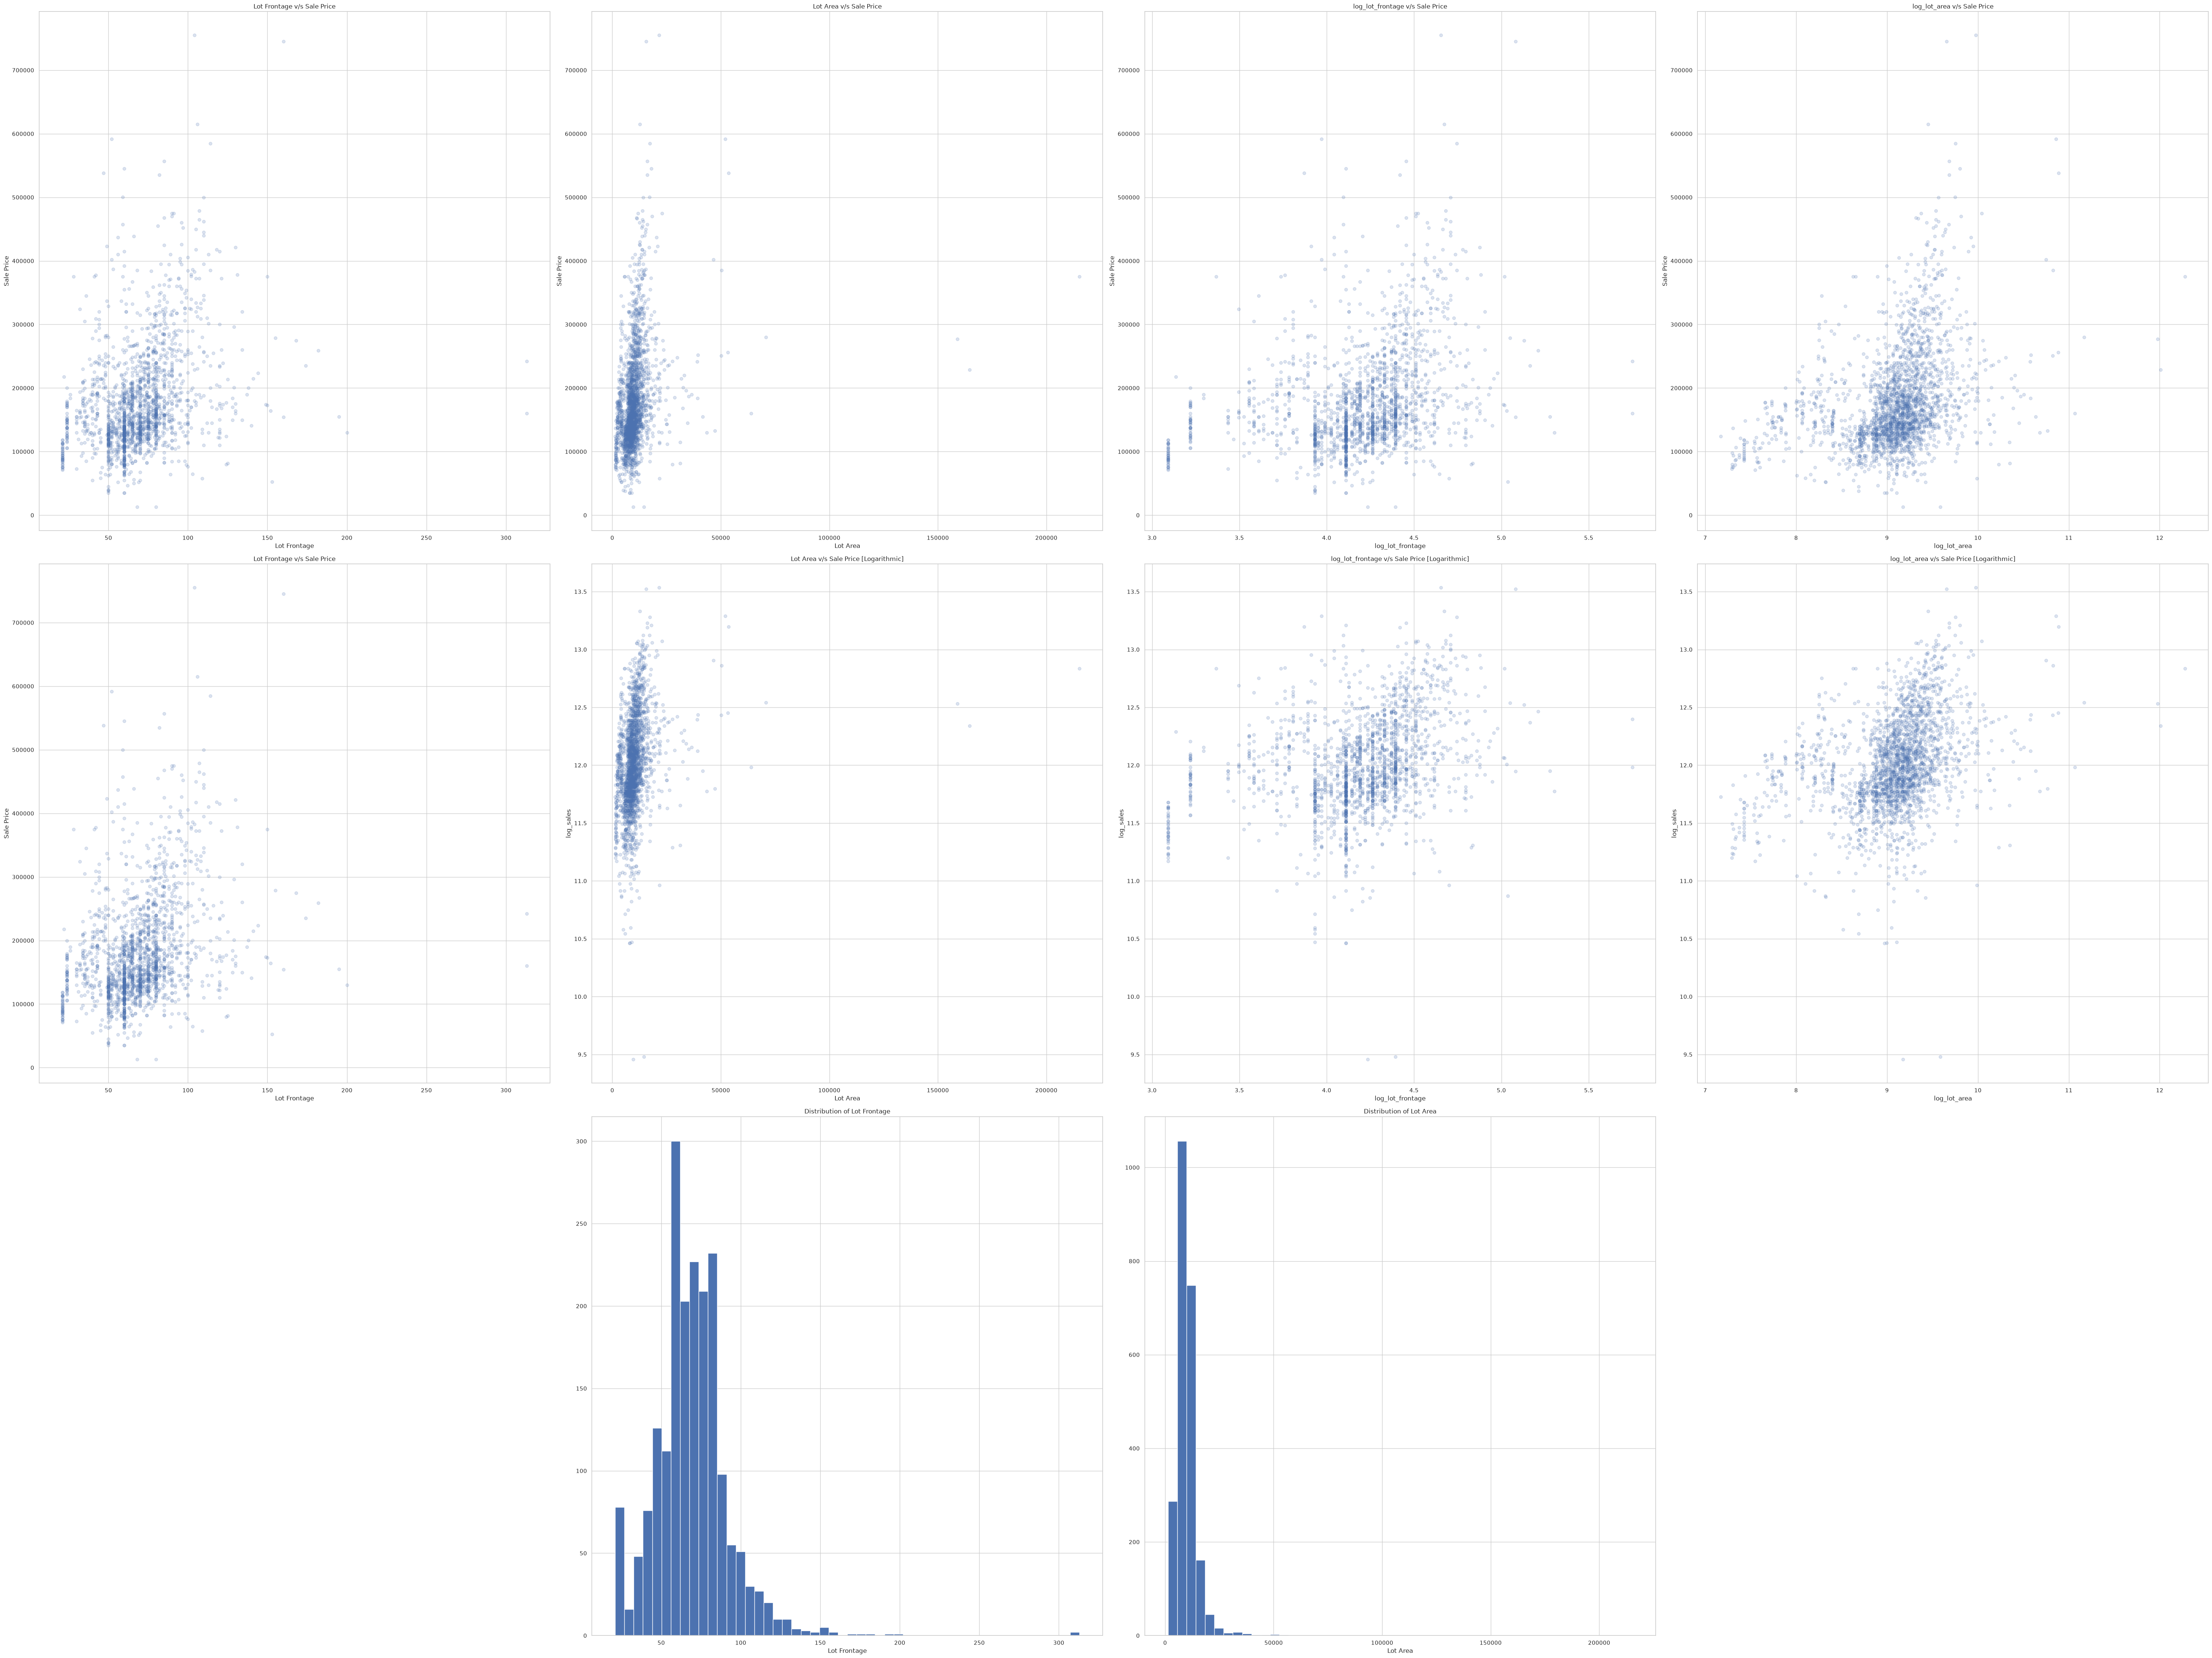

In [10]:
features = ['Lot Frontage', 'Lot Area', 'log_lot_frontage', 'log_lot_area',
            'Lot Frontage', 'Lot Area', 'log_lot_frontage', 'log_lot_area',
            'Lot Frontage', 'Lot Area']
row = 3
column = 4
fig, axes = plt.subplots(3, 4, figsize=(15 * column, 15 * row))
for i, ax in enumerate(axes.flatten()):
    if i < 5:
        ax.scatter(zoning_cols[features[i]], zoning_cols["SalePrice"], alpha=0.2)
        ax.set_xlabel(features[i])
        ax.set_ylabel("Sale Price")
        ax.set_title(f'{features[i]} v/s Sale Price')
    elif i < 8:
        ax.scatter(zoning_cols[features[i]], zoning_cols["log_sales"], alpha=0.2)
        ax.set_xlabel(features[i])
        ax.set_ylabel("log_sales")
        ax.set_title(f'{features[i]} v/s Sale Price [Logarithmic]')
    elif i > 8 and i <= 10:
        ax.hist(zoning_cols[features[i - 1]], bins=50)
        ax.set_xlabel(features[i - 1])
        ax.set_title(f'Distribution of {features[i - 1]}')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig("./images/lot-correlation-to-price.png")
plt.show()

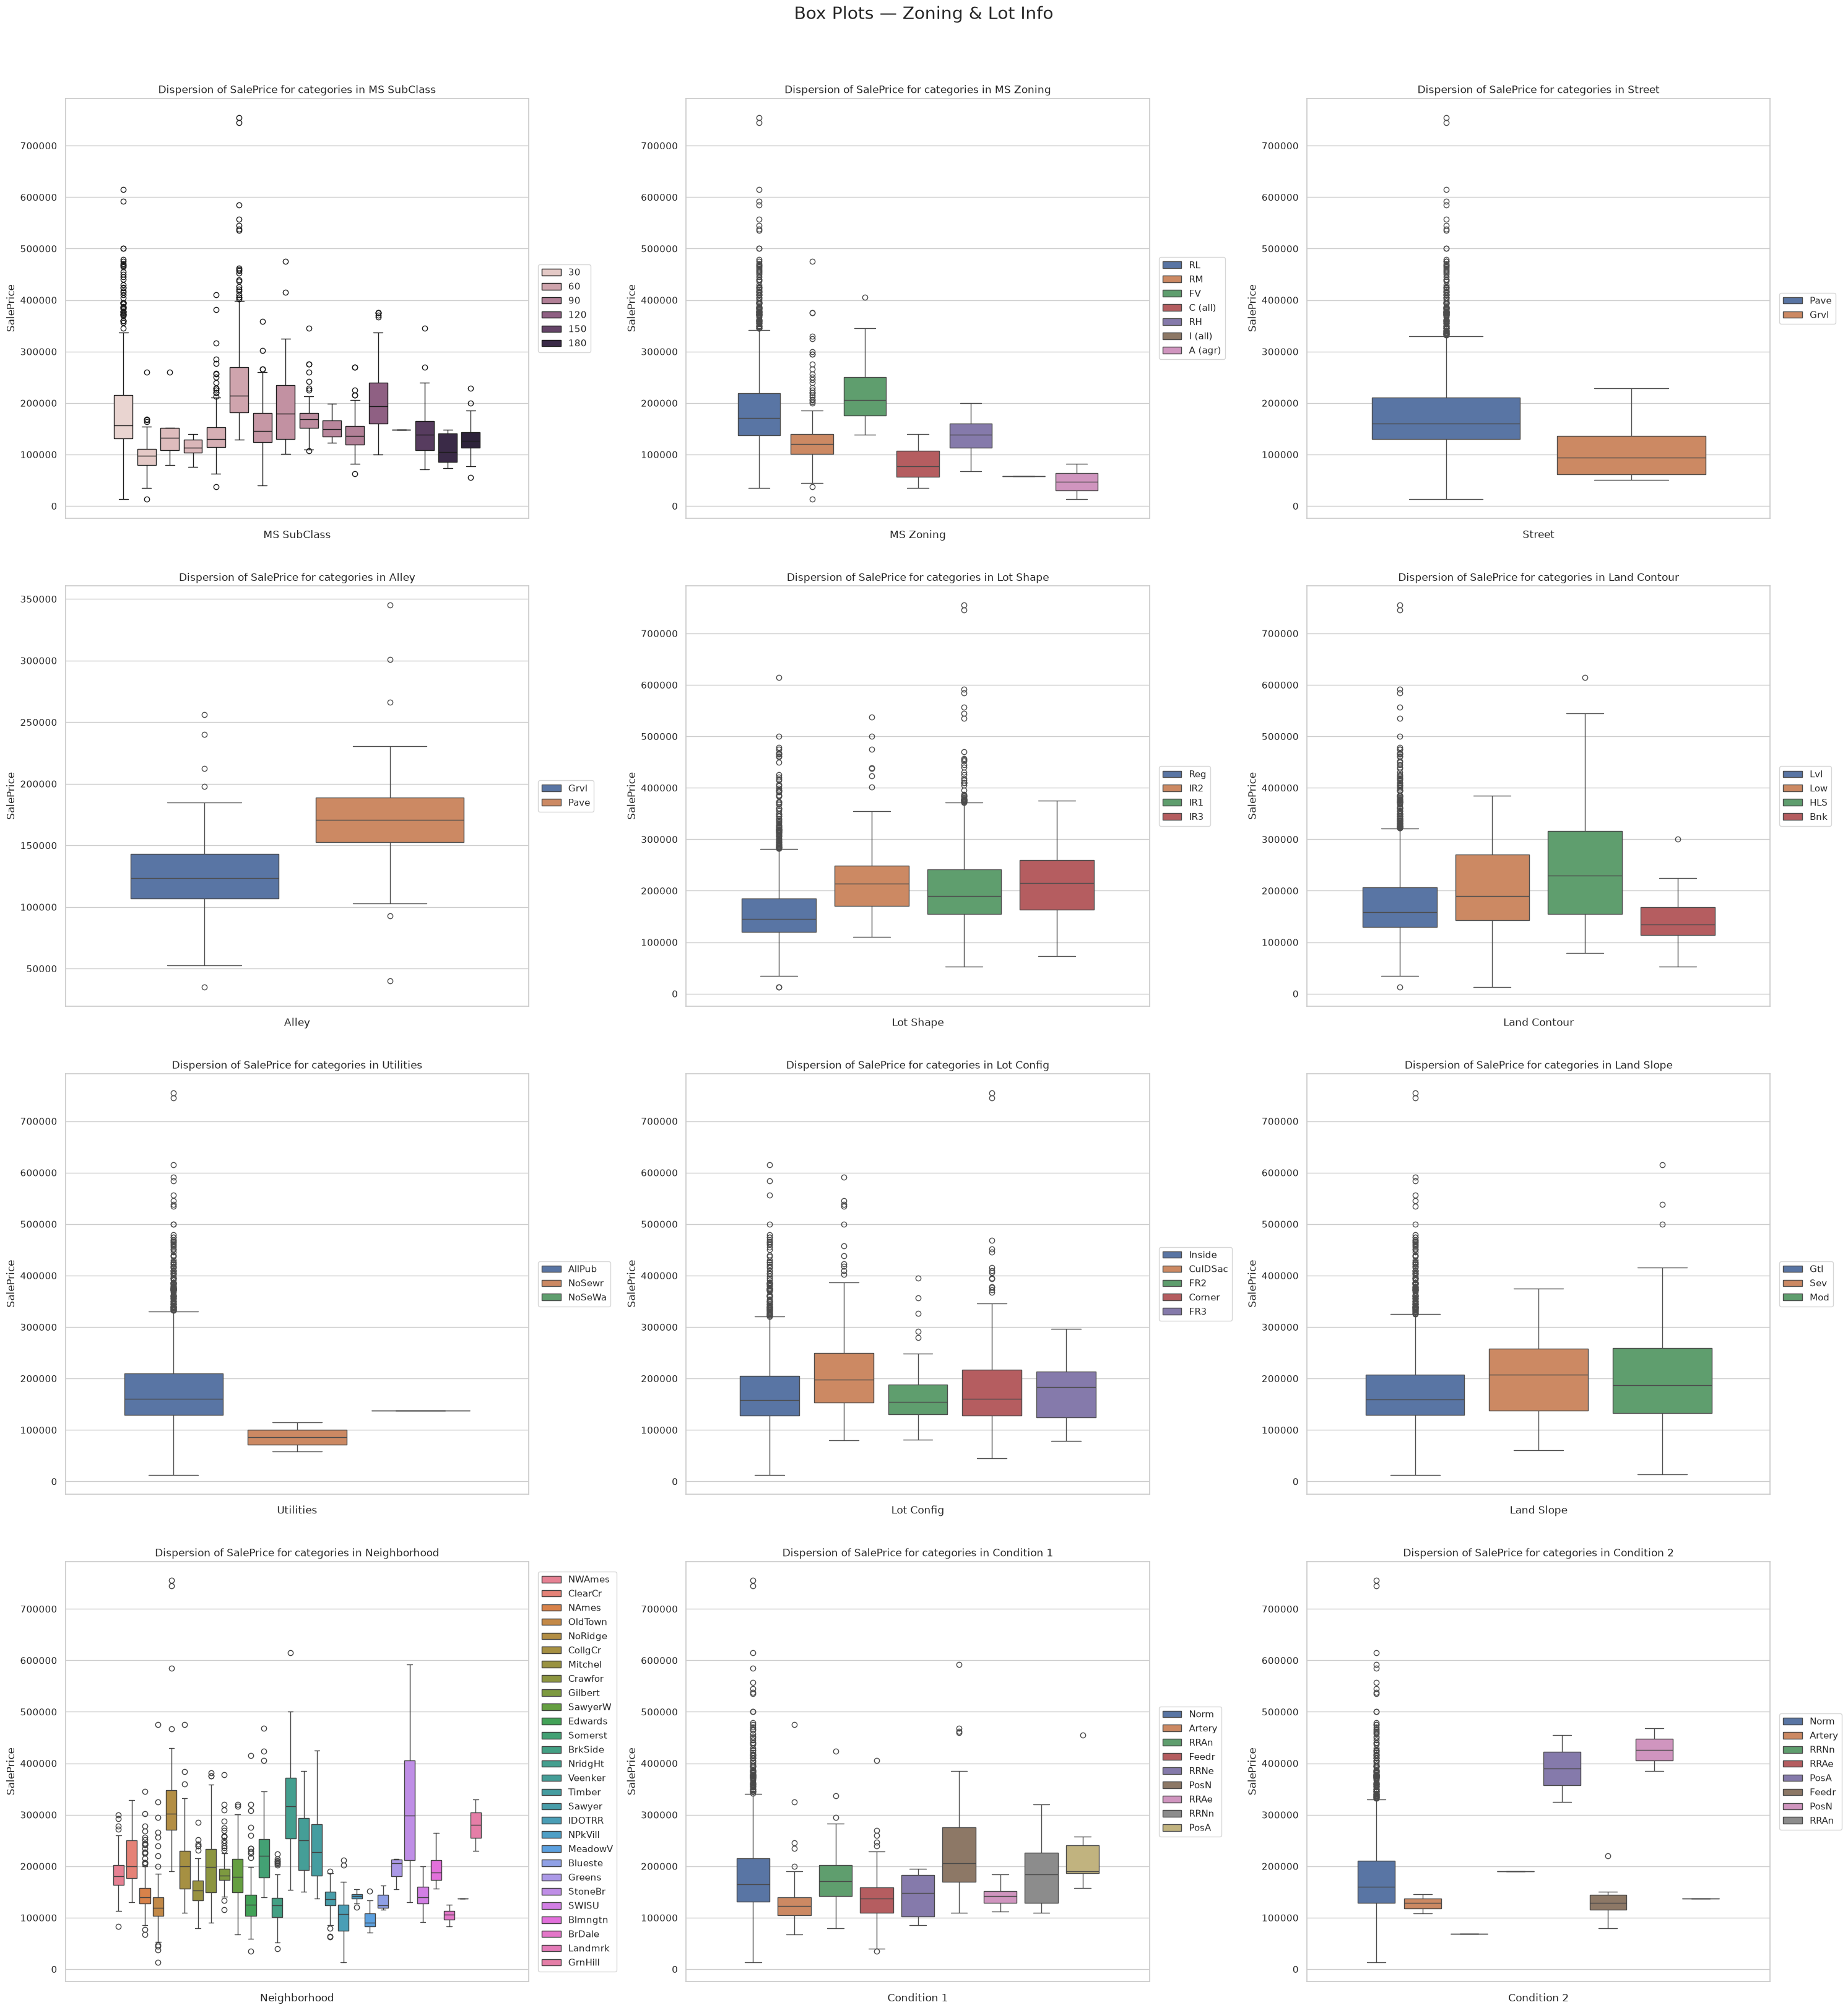

In [11]:
plot_columns = ['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape',
                'Land Contour', 'Utilities', 'Lot Config', 'Land Slope',
                'Neighborhood', 'Condition 1', 'Condition 2']

boxplot_grid(zoning_cols, plot_columns, ncols=3,
             save_path="./images/boxplots-for-zoning-information.png",
             suptitle="Box Plots — Zoning & Lot Info")

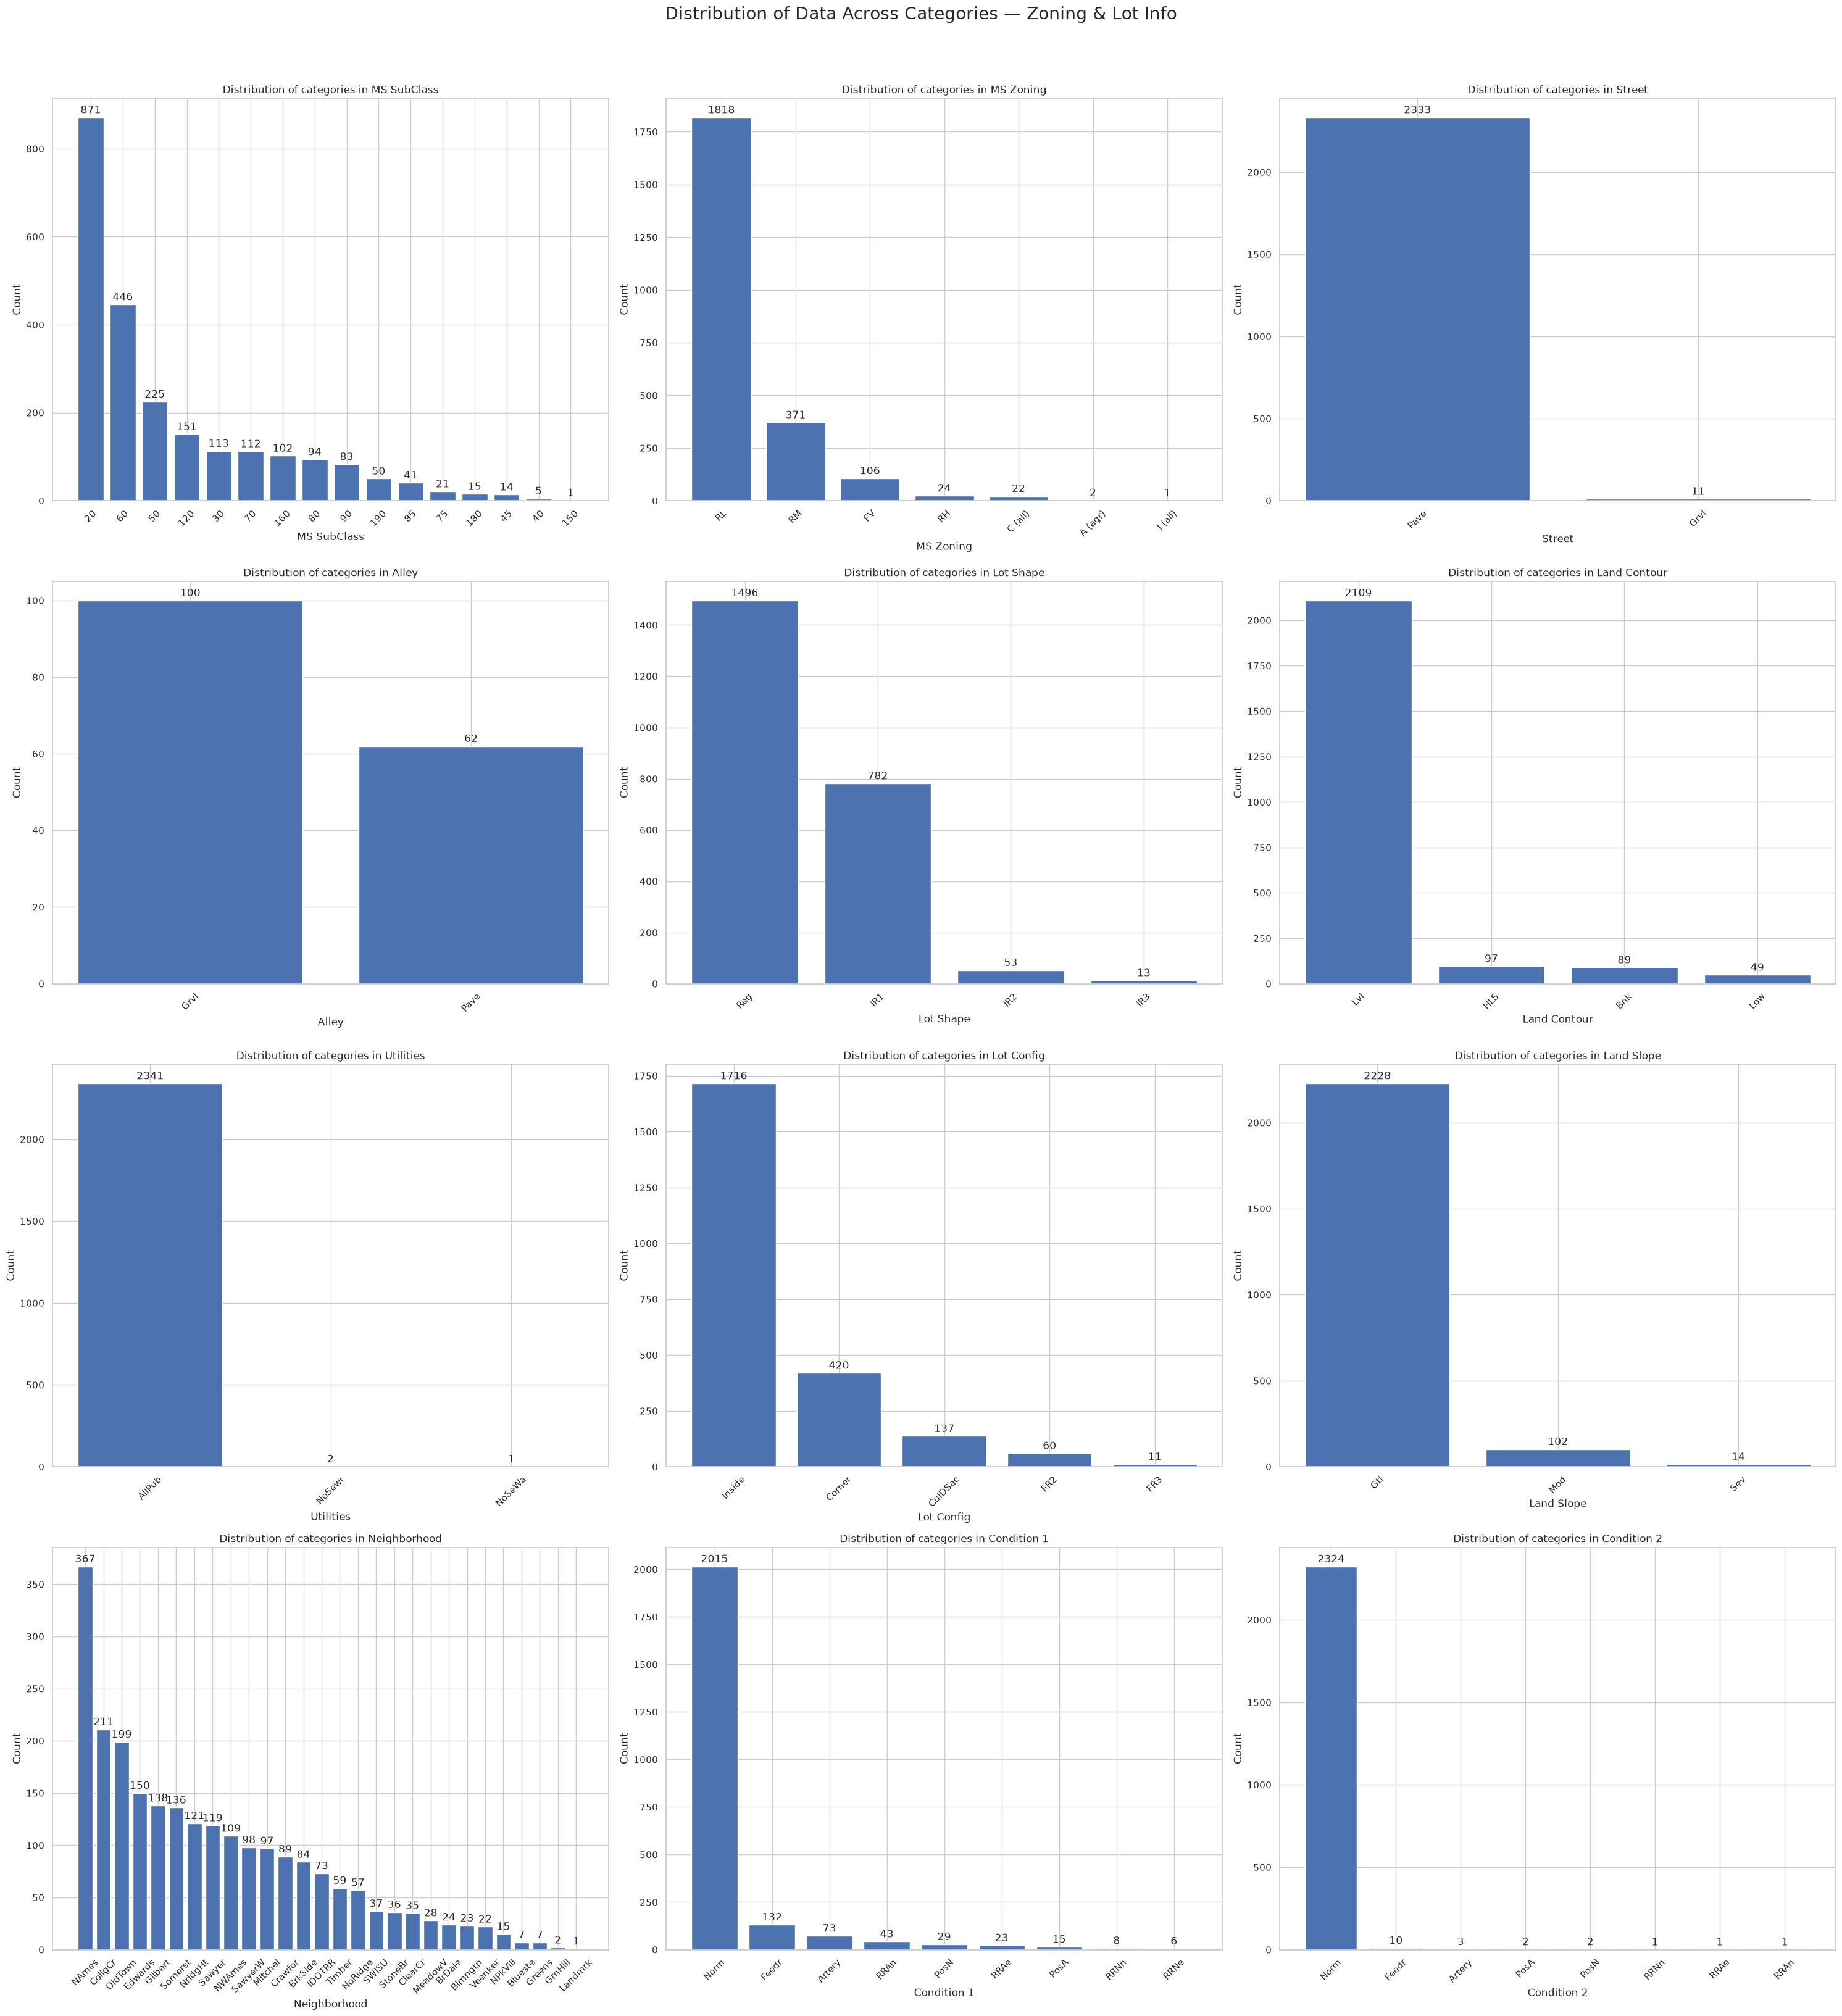

In [12]:
bar_chart_grid(zoning_cols, plot_columns, ncols=3,
               save_path="./images/dispersion-of-data-for-zoning-information.png",
               suptitle="Distribution of Data Across Categories — Zoning & Lot Info")

In [13]:
missing_summary(zoning_cols)

,Empty rows
MS SubClass,0
MS Zoning,0
Lot Frontage,393
Lot Area,0
Street,0
Alley,2182
Lot Shape,0
Land Contour,0
Utilities,0
Lot Config,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| **Alley** | 2182 missing (~85%) — actually means "no alley access," not unknown | `fillna('NoAlley')` — treat as a genuine category, not an imputation |
| **Lot Frontage** | 393 missing (~15%) — true missing values | Neighborhood-grouped median imputation (not global median): `groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))` |

2. Skew Correction (Continuous Features)

| Column | Issue | Fix |
|---|---|---|
| **Lot Frontage** | Right-skewed | PowerTransformer (Yeo-Johnson, standardize=True) — apply *after* missing-value fix above |
| **Lot Area** | Heavily right-skewed | PowerTransformer (Yeo-Johnson, standardize=True) |
| **SalePrice** (target) | Right-skewed | log1p transform (already done as `log_sales`) |

3. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **MS SubClass** | Numeric code, but actually categorical (no ordinal meaning) | One-hot encode (or target encode) — do NOT treat as continuous numeric |

4. Rare-Category Handling (low sample size → unstable estimates)

| Column | Rare categories | Fix |
|---|---|---|
| **MS Zoning** | C(all), A(agr), I(all) — <20 obs each | Group into `'Other'` |
| **MS SubClass** | 40, 150, 45, 180 — single/low-digit counts | Group rarest into `'Other'` |
| **Lot Shape** | IR2, IR3 — <50 each | Consider collapsing into IR1 (or a single `'Irregular'` vs `'Regular'` binary) |
| **Lot Config** | FR2, FR3 — thin | Consider grouping with CulDSac/Corner if still noisy after encoding |
| **Condition 1 & 2** | Overwhelmingly "Norm"; all others are slivers | Collapse to binary flag: `Norm` vs `Special Condition` (or keep Condition 1 detailed, drop/binarize Condition 2) |

5. Drop Candidates (near-zero variance / no predictive value)

| Column | Reason |
|---|---|
| **Utilities** | 99%+ AllPub — effectively constant |
| **Street** | 99%+ Pave — effectively constant |
| **Land Slope** | 95%+ Gtl — near-constant; binarize if kept (`Gentle` vs `Not Gentle`) instead of dropping outright |

---

## Building Type & Style
| Column | Meaning |
|---|---|
| **Bldg Type** | Type of dwelling (Single-family, Duplex, Townhouse, etc.) |
| **House Style** | Style of dwelling (1-story, 2-story, Split Foyer, etc.) |
| **Overall Qual** | Overall material/finish quality (rated 1–10) |
| **Overall Cond** | Overall condition rating (1–10) |
| **Year Built** | Original construction year |
| **Year Remod/Add** | Remodel date (same as Year Built if no remodeling) |

In [14]:
bld_columns = df[['Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'SalePrice']]

In [15]:
bld_columns.dtypes

Bldg Type         str
House Style       str
Overall Qual    int64
Overall Cond    int64
SalePrice       int64
dtype: object

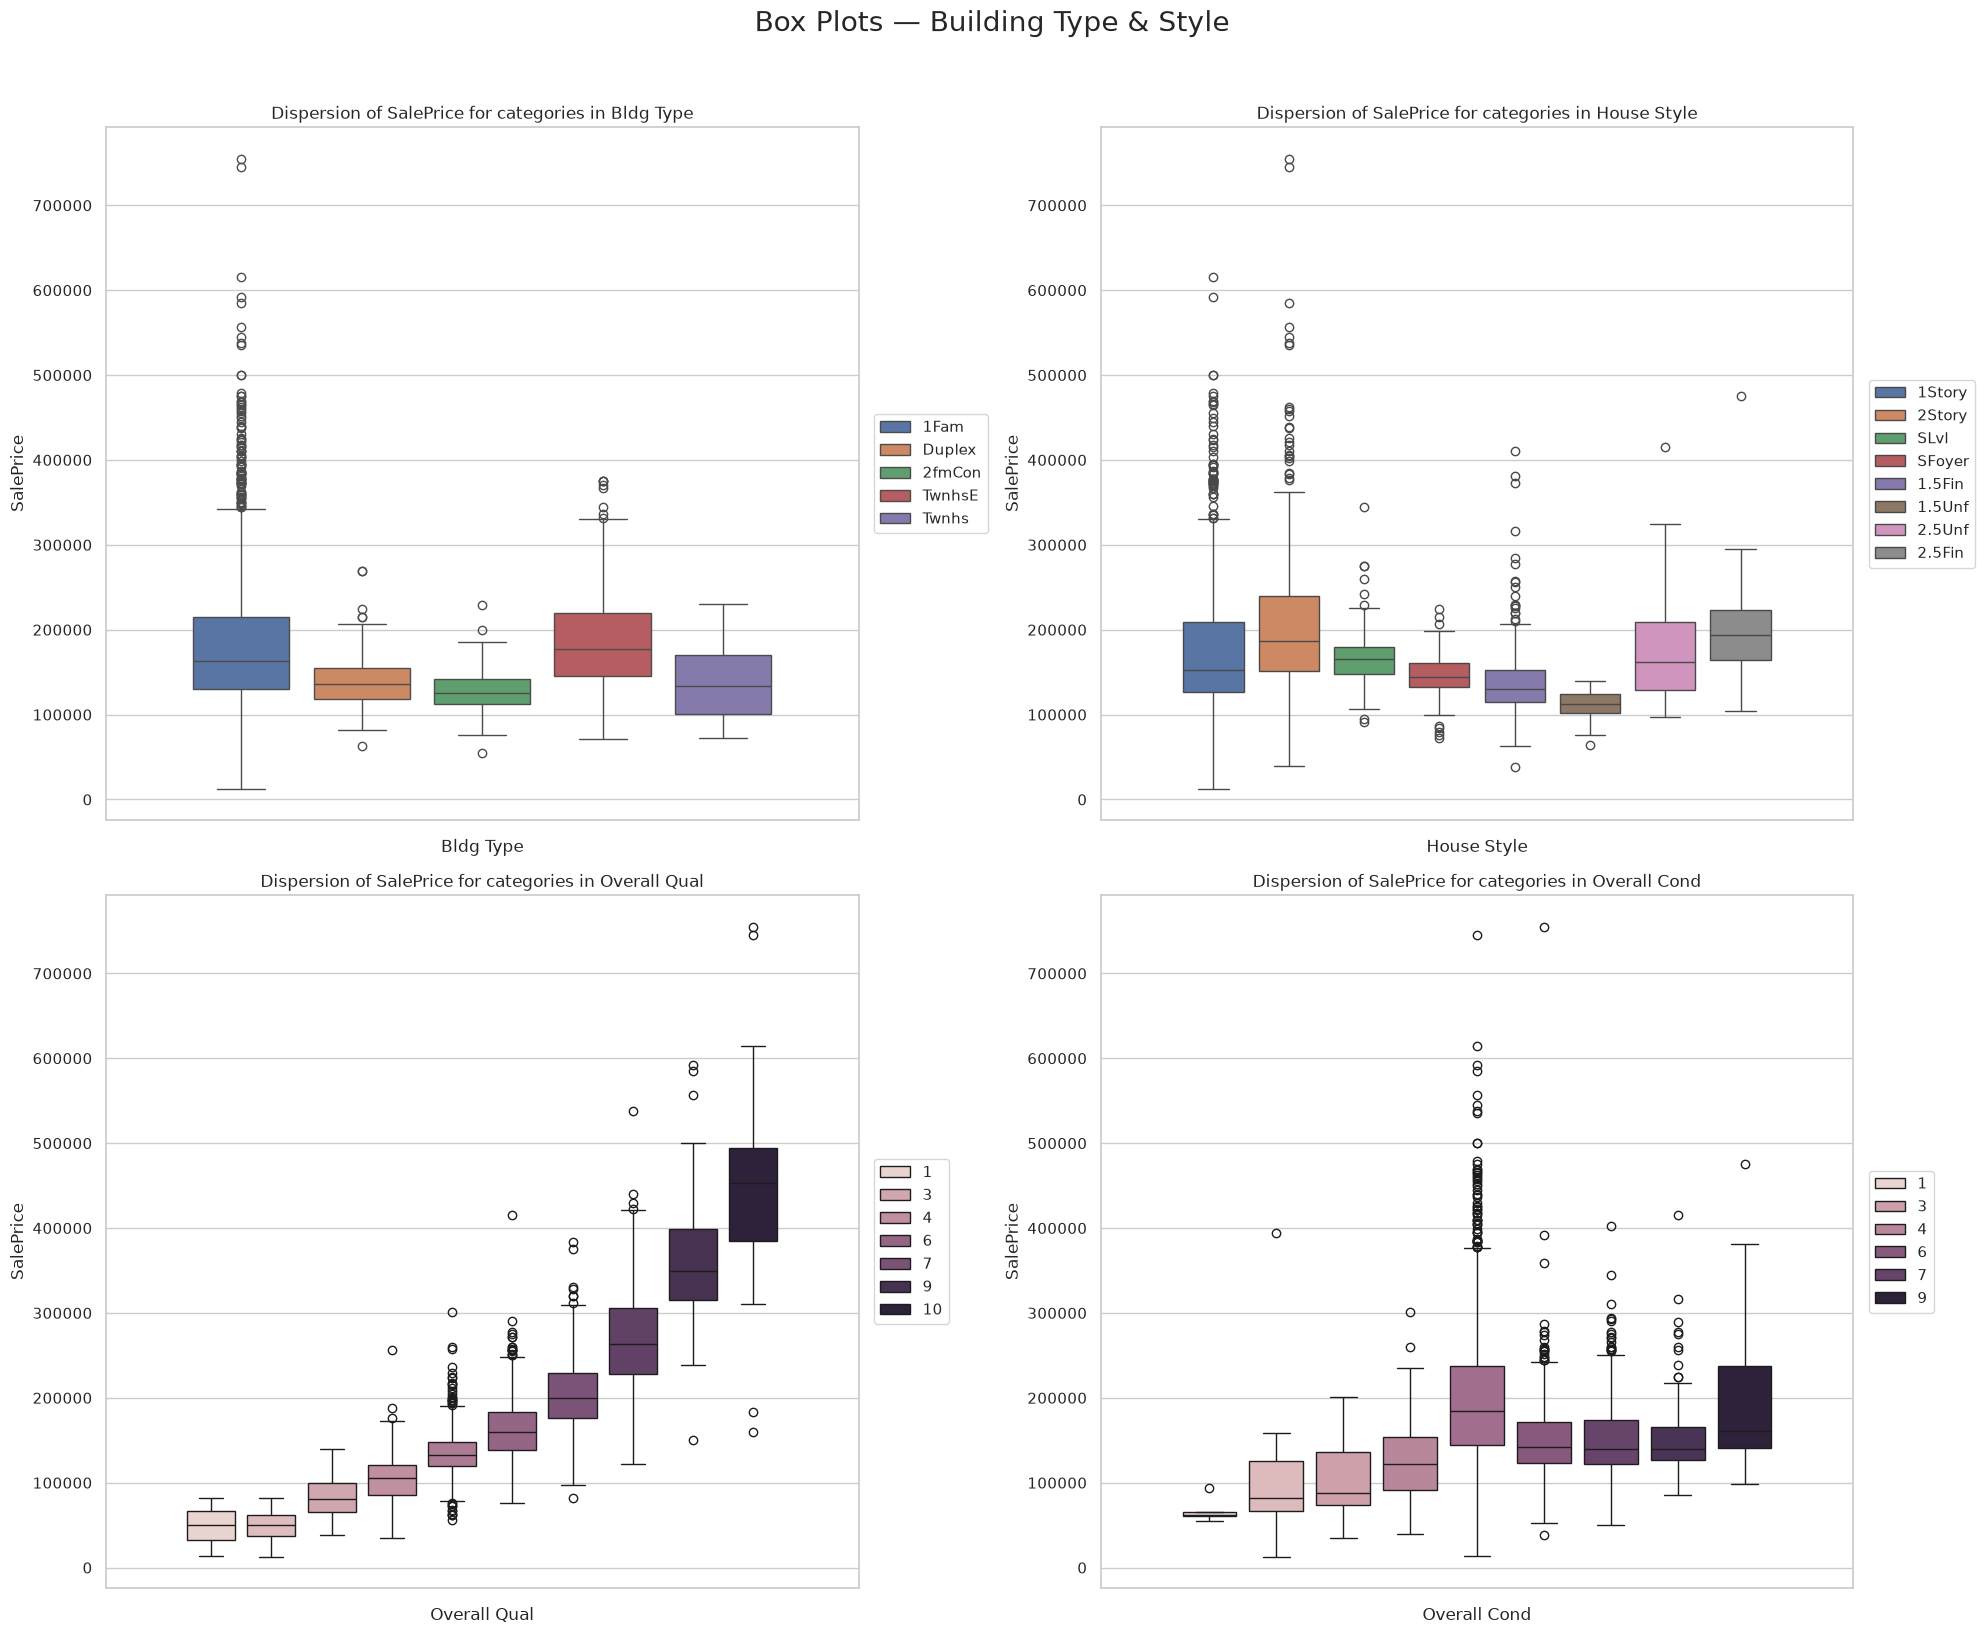

In [16]:
plot_columns = ['Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond']

boxplot_grid(bld_columns, plot_columns, ncols=2,
             save_path="./images/boxplots-for-build-information.png",
             suptitle="Box Plots — Building Type & Style")

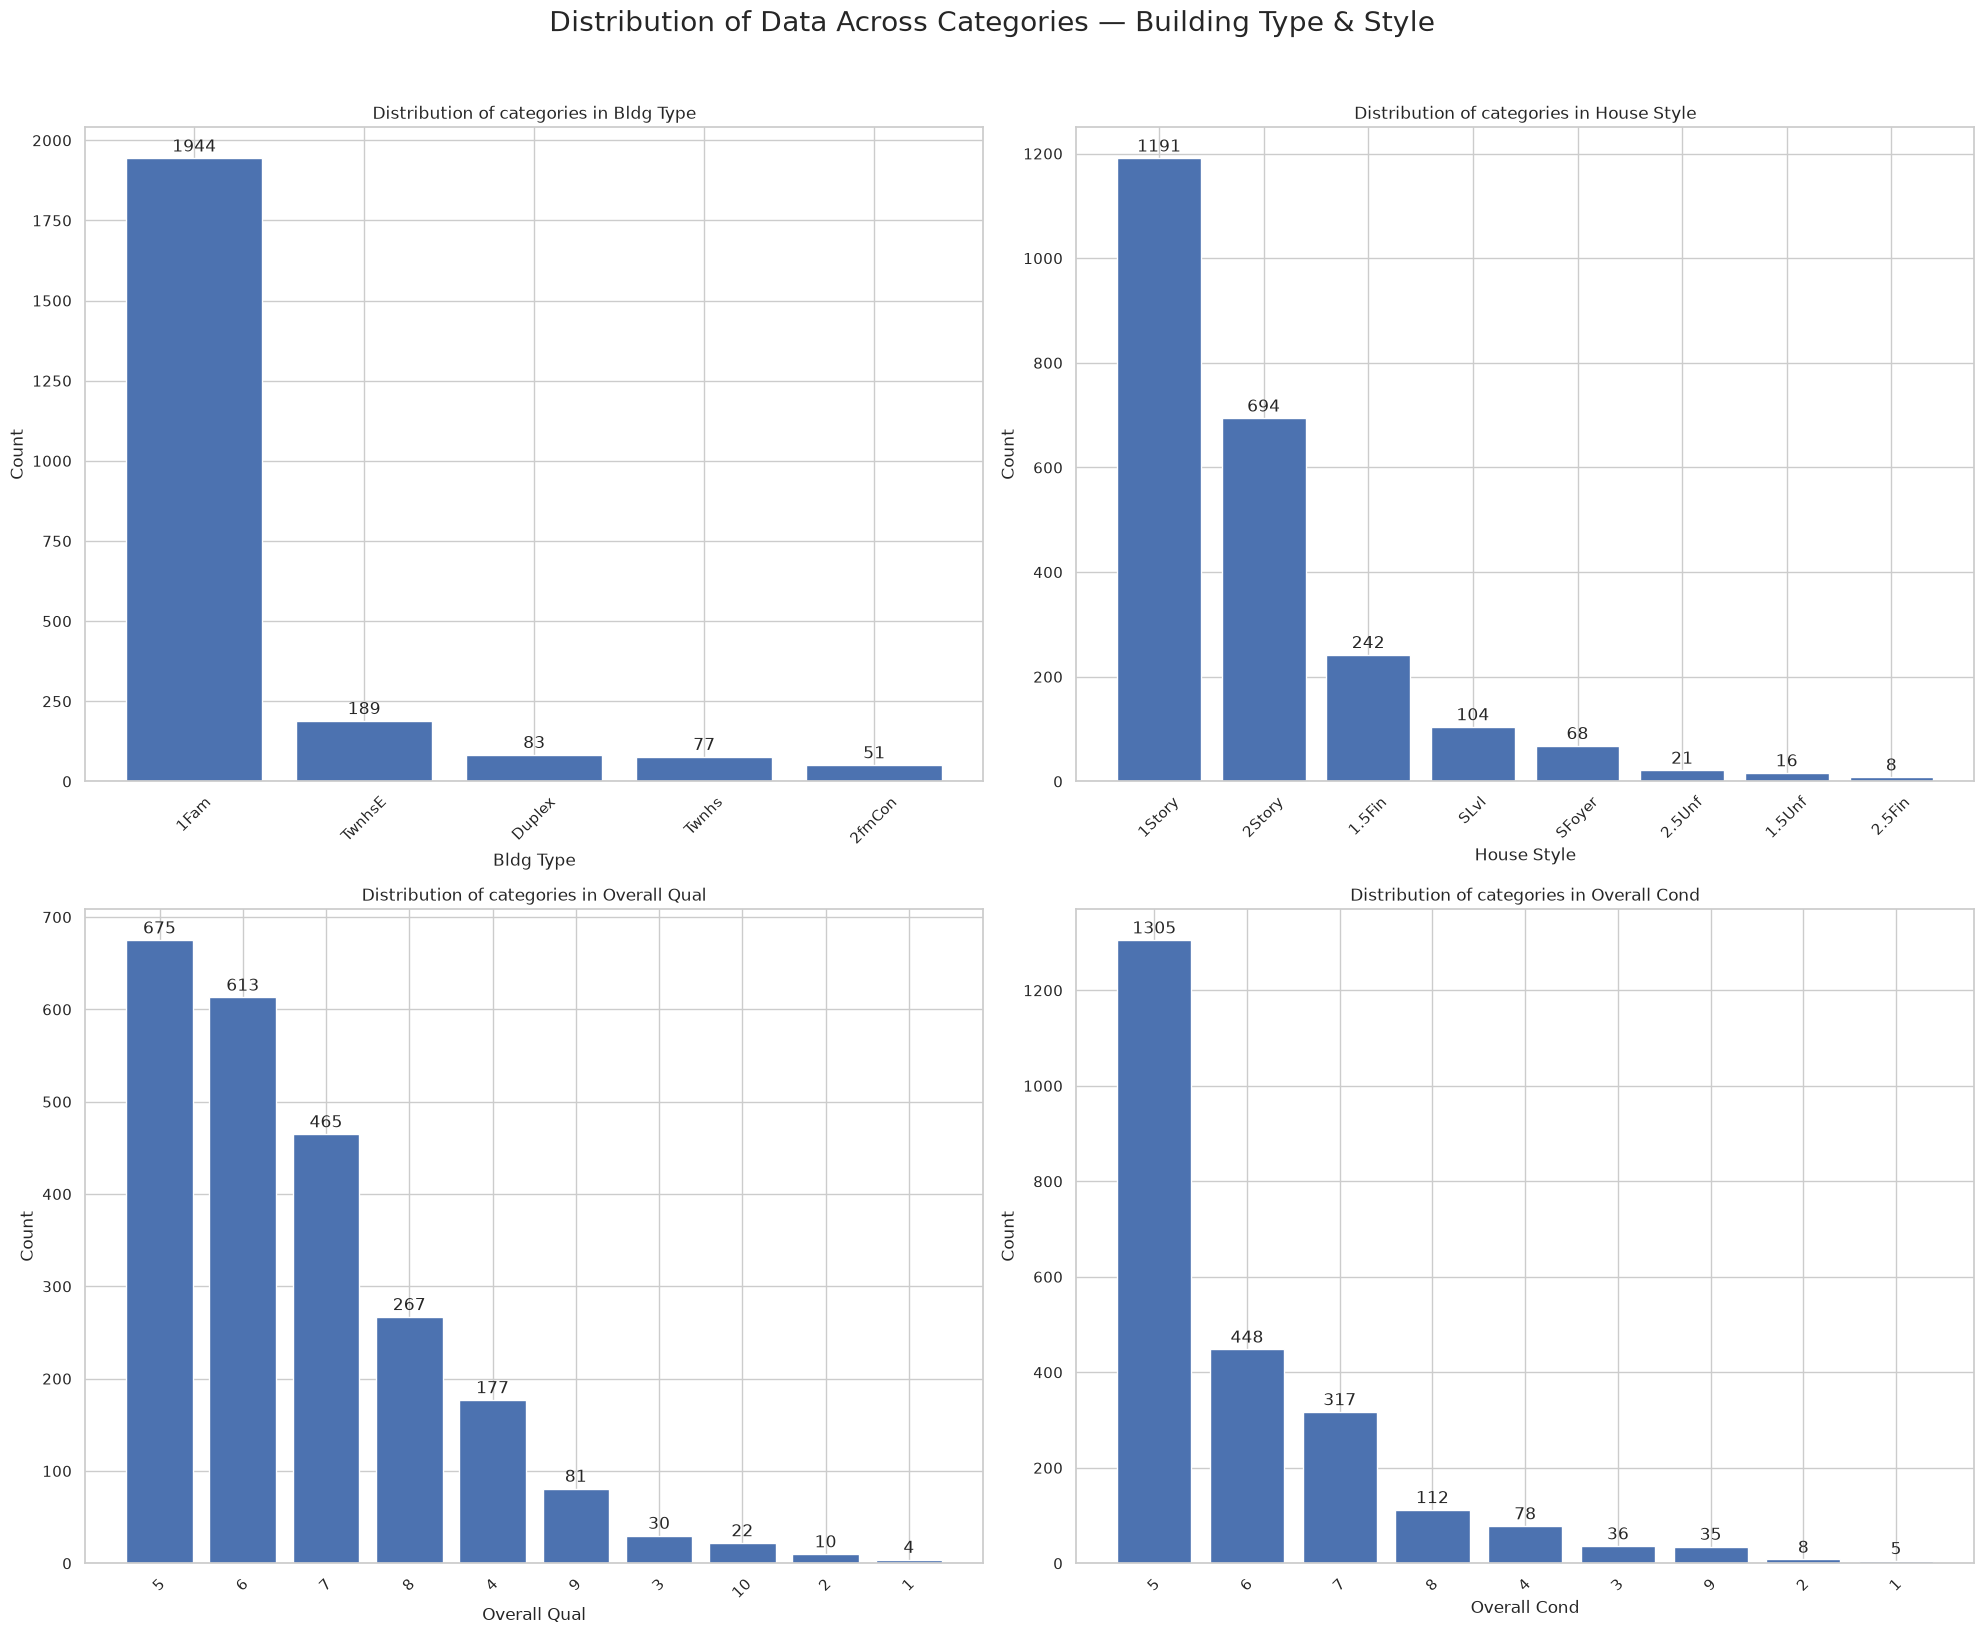

In [17]:
bar_chart_grid(bld_columns, plot_columns, ncols=2,
               save_path="./images/dispersion-of-data-for-build-information.png",
               suptitle="Distribution of Data Across Categories — Building Type & Style")

In [18]:
missing_summary(bld_columns, col_name="empty cells")

,empty cells
Bldg Type,0
House Style,0
Overall Qual,0
Overall Cond,0
SalePrice,0


---
## Age & Depreciation
| Column | Meaning |
|---|---|
| **Year Built** | Original construction date |
| **Year Remod/Add** | Remodel date (same as Year Built if no remodeling/additions) |
| **Mo Sold** | Month sold (1–12) |
| **Yr Sold** | Year sold (2006–2010) |

> **Derived features:** `depreciation_time = Yr Sold − Year Built` and `remod_age = Yr Sold − Year Remod/Add` capture *age at time of sale* — a more meaningful predictor than raw calendar year.
---

In [19]:
age_column = df[['Year Built', 'Year Remod/Add', 'Mo Sold', 'Yr Sold', 'SalePrice']].copy()
age_column['depreciation_time'] = age_column['Yr Sold'] - age_column['Year Built']
age_column['remod_age'] = age_column['Yr Sold'] - age_column['Year Remod/Add']

In [20]:
correlation_table(age_column, ['Year Built', 'Year Remod/Add', 'Yr Sold',
                                'Mo Sold', 'depreciation_time', 'remod_age'])

,Pearson,Spearman,Kendall
Year Built,0.545,0.665,0.479
Year Remod/Add,0.518,0.581,0.419
Yr Sold,-0.038,-0.020,-0.015
Mo Sold,0.031,0.036,0.025
depreciation_time,-0.546,-0.663,-0.478
remod_age,-0.520,-0.585,-0.419


/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/trozan24/Downloads/Coding/projects/Ames-House-Prediction/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


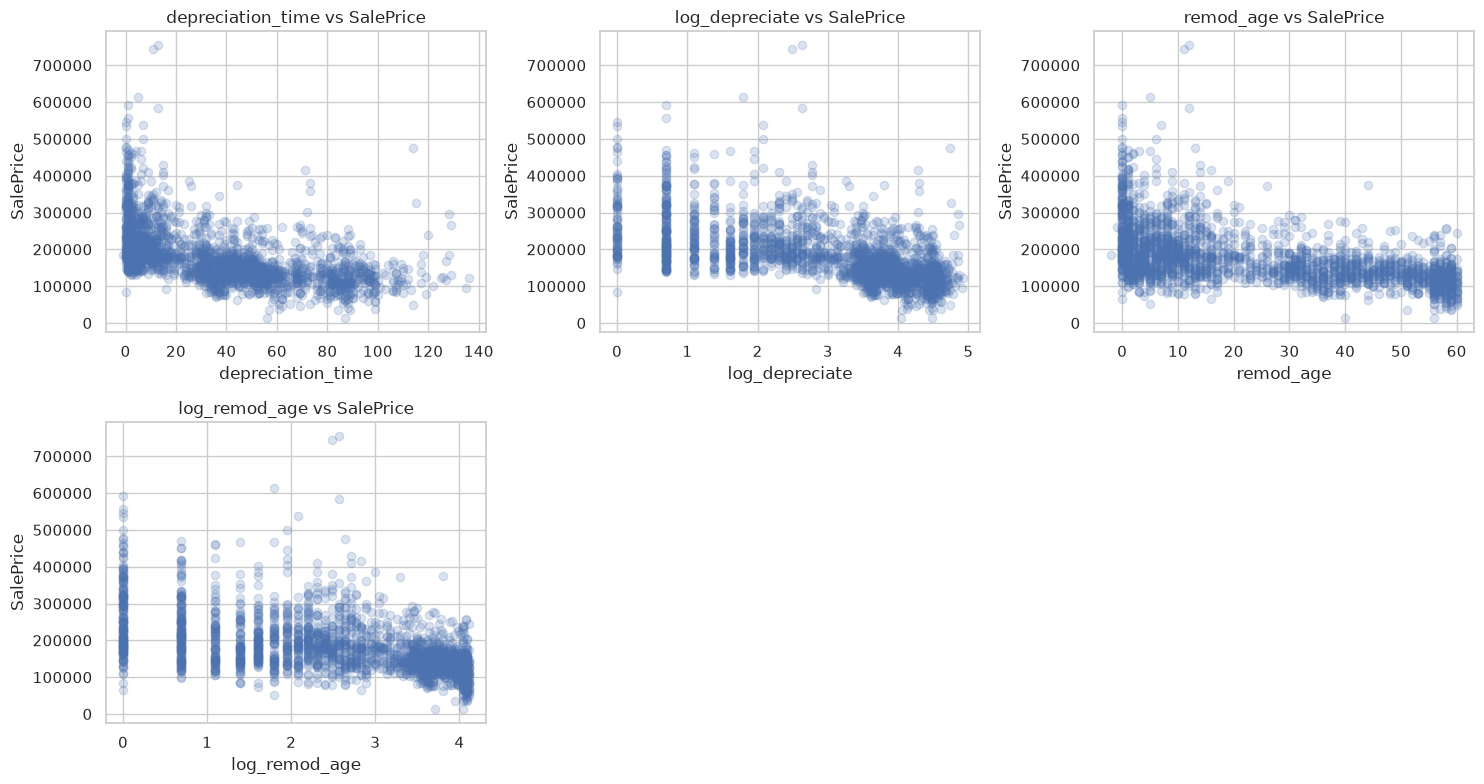

In [21]:
age_column['log_depreciate'] = np.log1p(age_column['depreciation_time'])
age_column['log_remod_age'] = np.log1p(age_column['remod_age'])

scatter_subplot(age_column,
                ['depreciation_time', 'log_depreciate', 'remod_age', 'log_remod_age'],
                'SalePrice',
                save_path="./images/age-depreciation-vs-price.png")

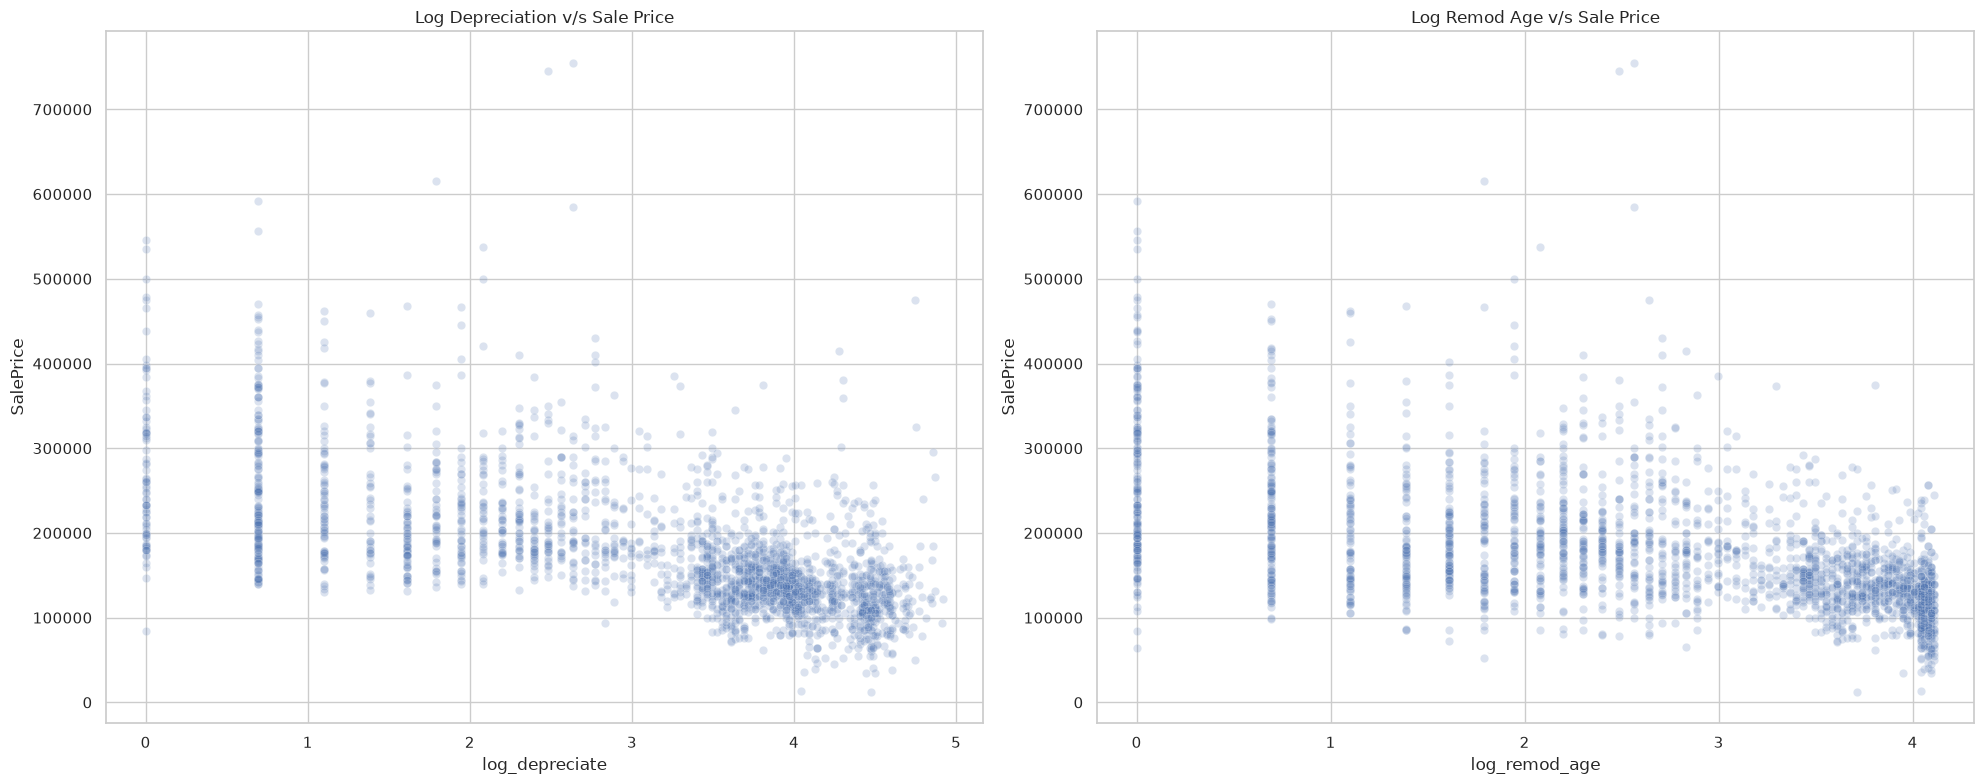

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(data=age_column, x='log_depreciate', y='SalePrice', alpha=0.2, ax=axes[0])
axes[0].set_title("Log Depreciation v/s Sale Price")

sns.scatterplot(data=age_column, x='log_remod_age', y='SalePrice', alpha=0.2, ax=axes[1])
axes[1].set_title("Log Remod Age v/s Sale Price")

plt.tight_layout()
plt.savefig("./images/depreciation-vs-Sales-Price.png")
plt.show()

In [23]:
missing_summary(age_column)

,Empty rows
Year Built,0
Year Remod/Add,0
Mo Sold,0
Yr Sold,0
SalePrice,0
depreciation_time,0
remod_age,0
log_depreciate,0
log_remod_age,1


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| — | No missing values in this group | — |

2. Key Predictors

| Column | Spearman ρ | Note |
|---|---|---|
| **Year Built** | ~0.57 | Strong — newer homes sell for more |
| **Year Remod/Add** | ~0.57 | Strong — tracks Year Built when no remodel happened |
| **depreciation_time** | ~−0.57 | Mirror of Year Built — older house at sale = lower price |
| **remod_age** | ~−0.57 | Similar to depreciation but anchored on remodel year |
| **Mo Sold** | ~0.04 | Negligible — month of sale has almost no relationship to price |
| **Yr Sold** | ~−0.02 | Negligible — 5-year window too narrow for trend signal |

3. Feature Engineering

| Feature | Source | Note |
|---|---|---|
| **HouseAgeAtSale** | `Yr Sold − Year Built` | Already in `AmesFeatureEngineer` — clipped to ≥ 0 |
| **RemodAgeAtSale** | `Yr Sold − Year Remod/Add` | Already in `AmesFeatureEngineer` — clipped to ≥ 0 |

4. Observations

- **depreciation_time** and **Year Built** are mirror images (ρ ≈ −0.57 vs +0.57) — keeping both is redundant. `HouseAgeAtSale` in the pipeline is the right form.
- **Year Remod/Add = Year Built** for ~60% of houses (never remodeled) — so `remod_age` only diverges for remodeled homes. This makes it a useful secondary signal but highly correlated with depreciation_time for the majority.
- The **log transform** compresses the right tail (very old houses) and linearizes the relationship with SalePrice — confirms Yeo-Johnson in preprocessing is appropriate.

---

## Roof & Exterior
| Column | Meaning |
|---|---|
| **Roof Style** | Type of roof (Gable, Hip, etc.) |
| **Roof Matl** | Roof material |
| **Exterior 1st / Exterior 2nd** | Exterior covering material(s) — 2nd used if more than one material |
| **Mas Vnr Type** | Masonry veneer type (Brick, Stone, None) |
| **Mas Vnr Area** | Masonry veneer area (sq ft) |
| **Exter Qual** | Exterior material quality |
| **Exter Cond** | Present condition of exterior material |
| **Foundation** | Type of foundation |

In [24]:
roof_columns = df[['Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
                    'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond',
                    'Foundation', 'SalePrice']]

In [25]:
roof_columns.dtypes

Roof Style          str
Roof Matl           str
Exterior 1st        str
Exterior 2nd        str
Mas Vnr Type        str
Mas Vnr Area    float64
Exter Qual          str
Exter Cond          str
Foundation          str
SalePrice         int64
dtype: object

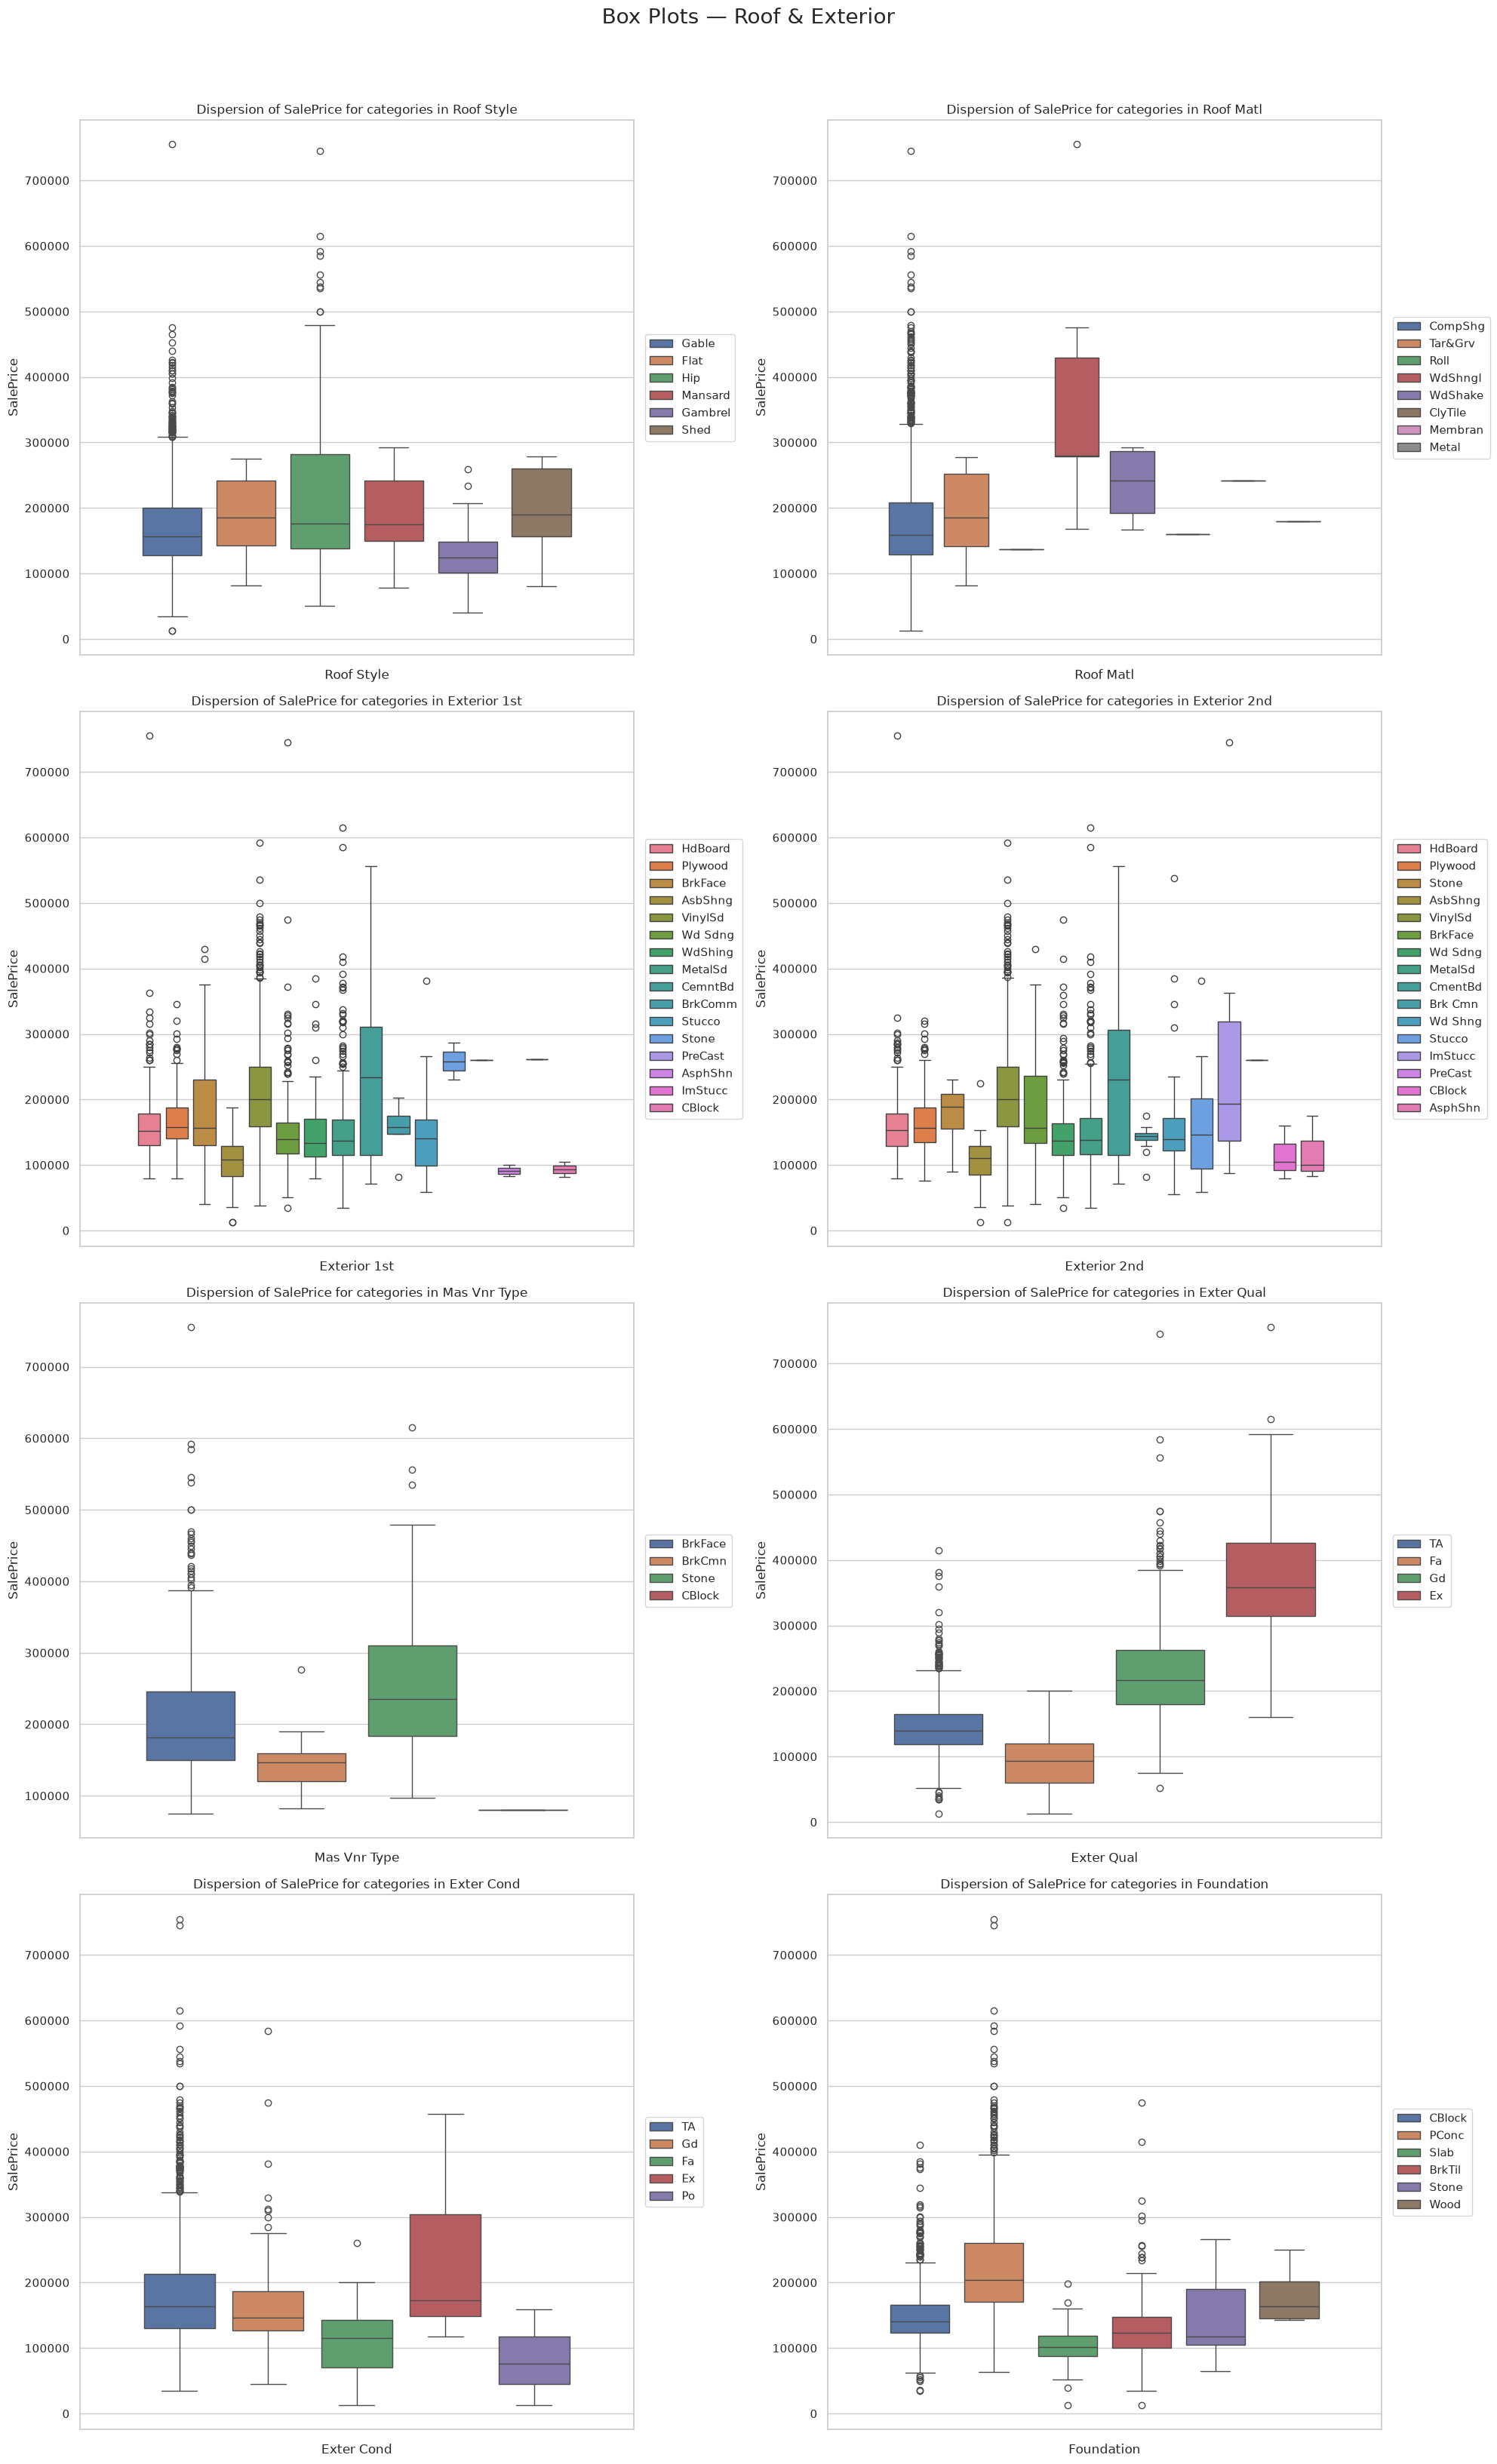

In [26]:
plot_columns = ['Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
                'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation']

boxplot_grid(roof_columns, plot_columns, ncols=2,
             save_path="./images/boxplots-for-roof-information.png",
             suptitle="Box Plots — Roof & Exterior")

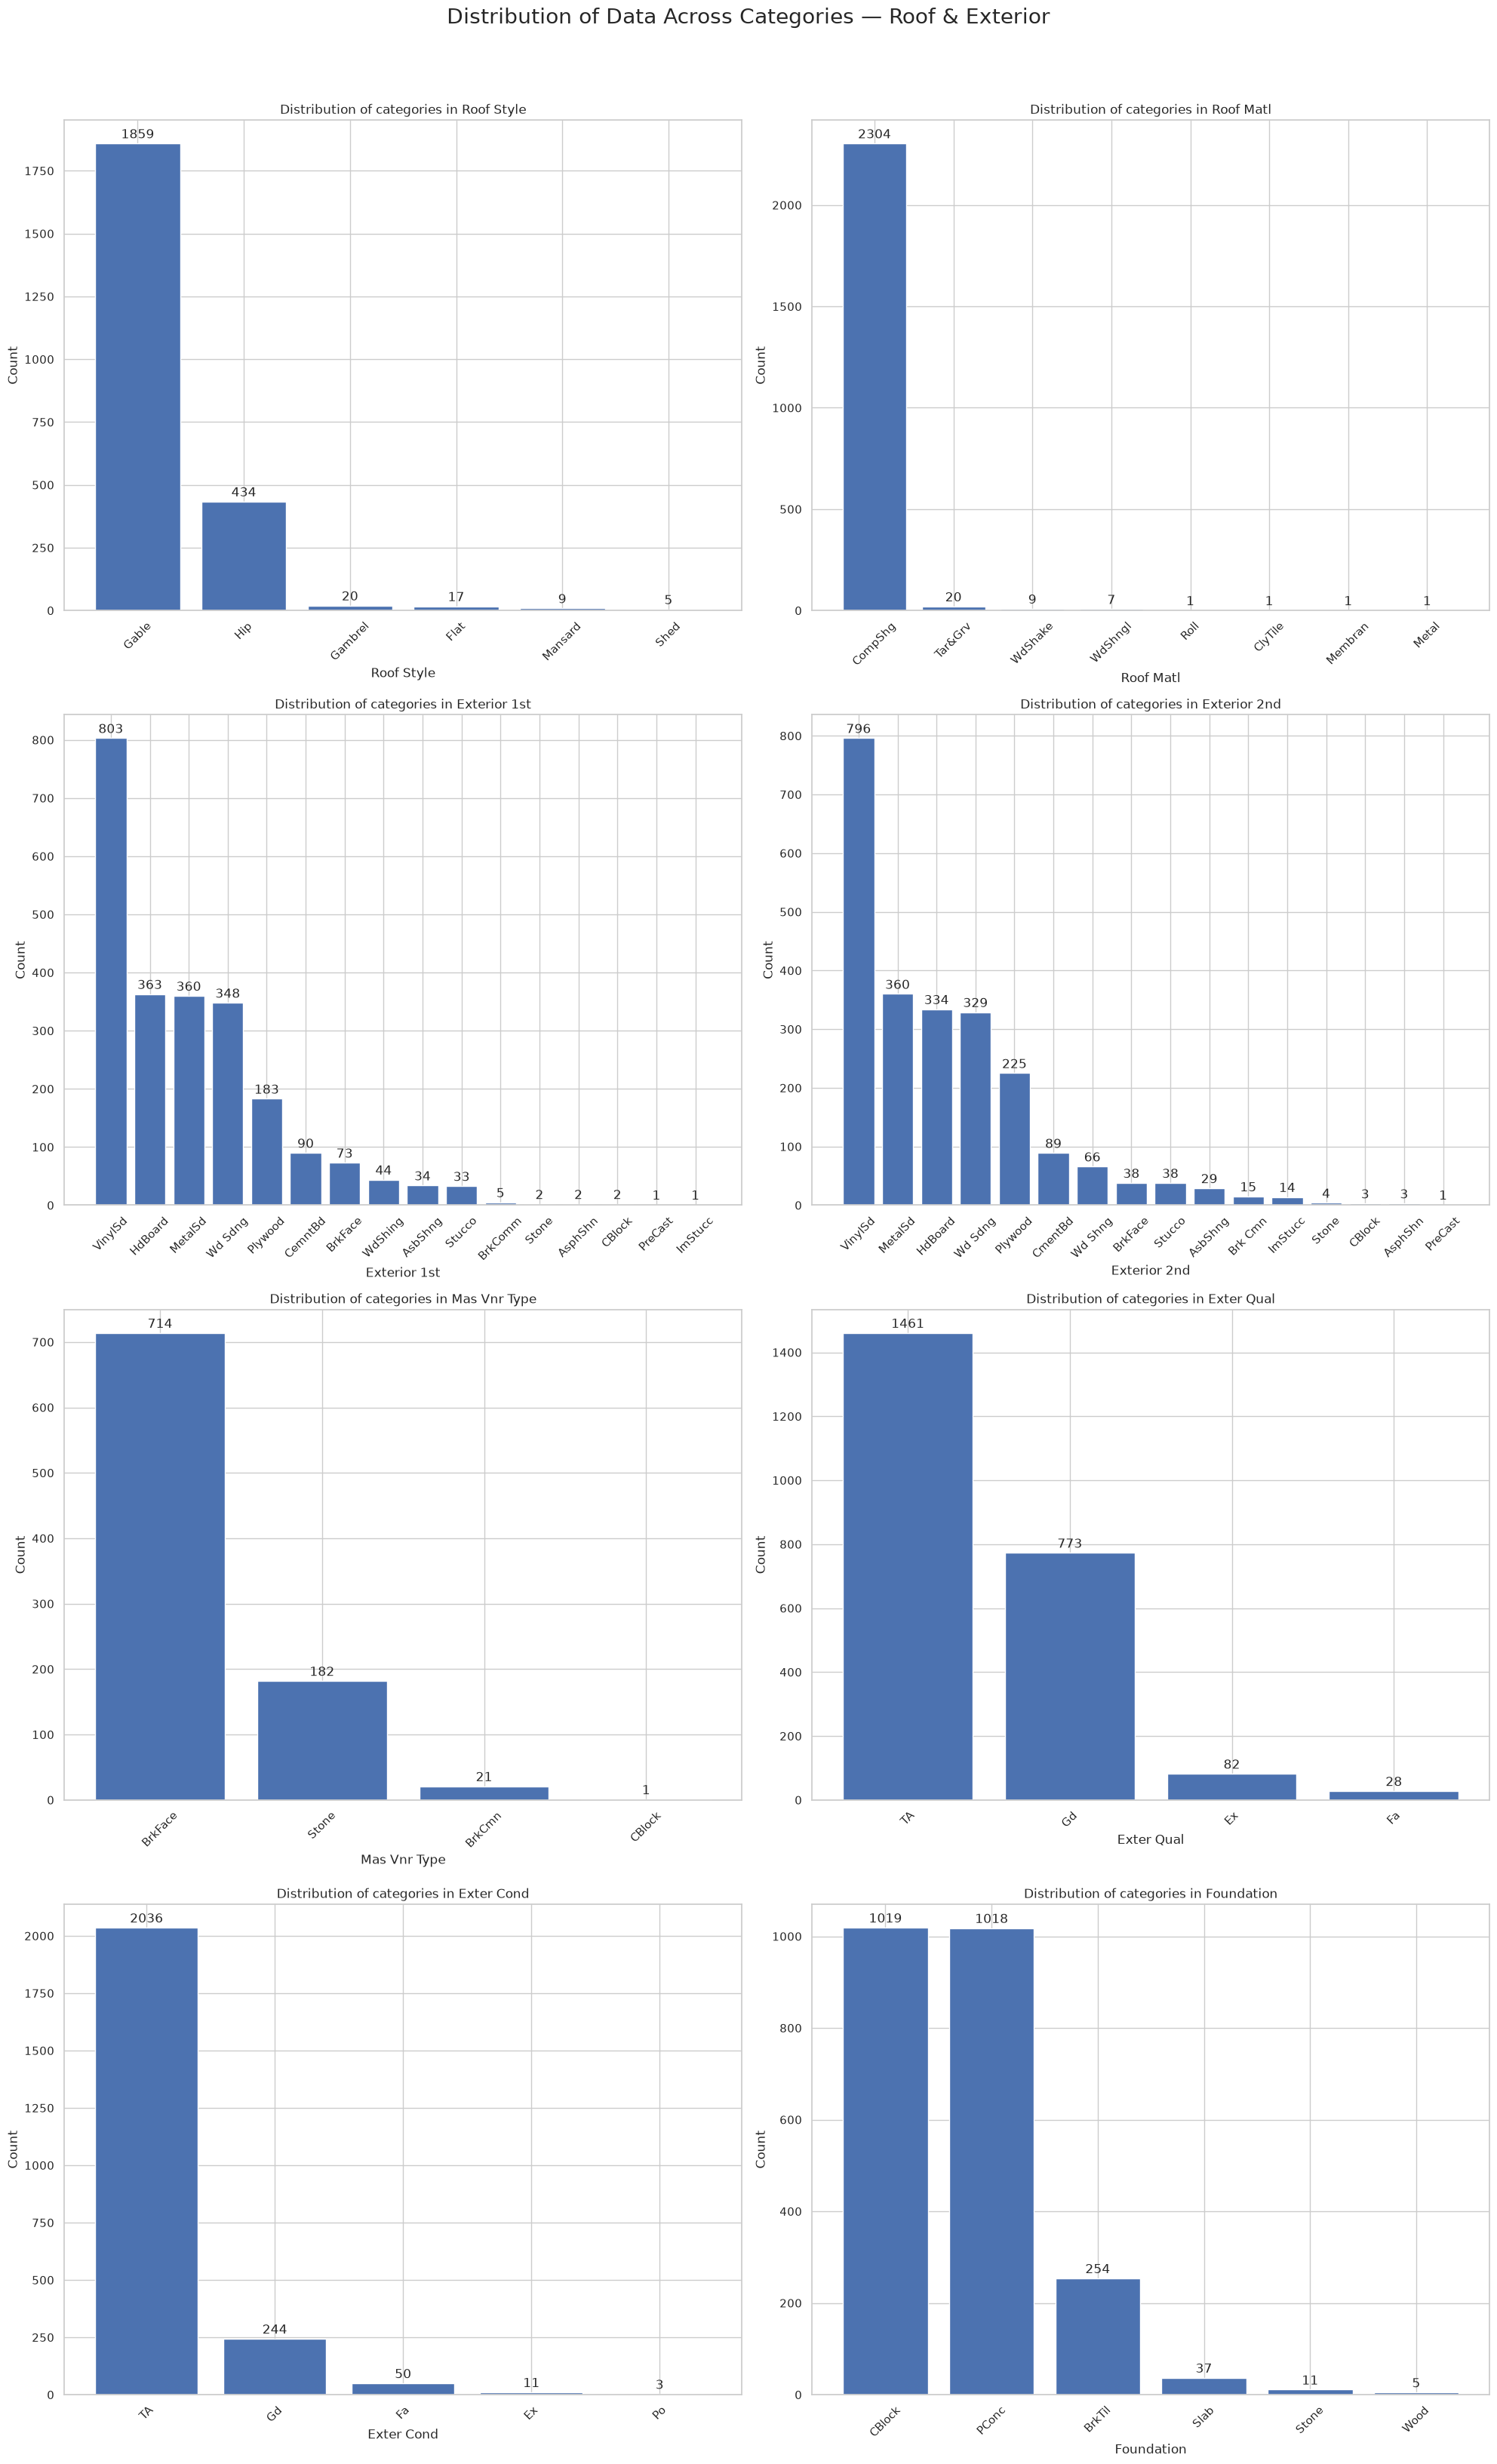

In [27]:
bar_chart_grid(roof_columns, plot_columns, ncols=2,
               save_path="./images/dispersion-of-data-for-roof-information.png",
               suptitle="Distribution of Data Across Categories — Roof & Exterior")

In [28]:
missing_summary(roof_columns)

,Empty rows
Roof Style,0
Roof Matl,0
Exterior 1st,0
Exterior 2nd,0
Mas Vnr Type,1426
Mas Vnr Area,19
Exter Qual,0
Exter Cond,0
Foundation,0
SalePrice,0


In [29]:
correlation_table(roof_columns, ['Mas Vnr Area'])

,Pearson,Spearman,Kendall
Mas Vnr Area,0.491,0.423,0.324


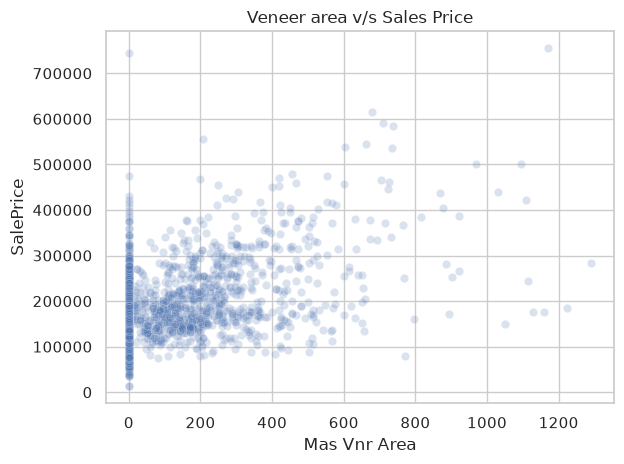

In [30]:
sns.scatterplot(data=roof_columns, x='Mas Vnr Area', y='SalePrice', alpha=0.2)
plt.title("Veneer area v/s Sales Price")
plt.tight_layout()
plt.savefig("./images/Veneer-Area-vs-Sales-Price.png")
plt.show()

---
## Basement
| Column | Meaning |
|---|---|
| **Bsmt Qual** | Height of basement (quality proxy) |
| **Bsmt Cond** | General condition of basement |
| **Bsmt Exposure** | Walkout/garden level walls |
| **BsmtFin Type 1 / BsmtFin SF 1** | Rating of finished basement area 1 / its square footage |
| **BsmtFin Type 2 / BsmtFin SF 2** | Same, for a second finished area (if basement has multiple finish types) |
| **Bsmt Unf SF** | Unfinished basement square feet |
| **Total Bsmt SF** | Total basement square feet |
---

In [31]:
basment_df = df[['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                  'BsmtFin Type 1', 'BsmtFin SF 1',
                  'BsmtFin Type 2', 'BsmtFin SF 2',
                  'Bsmt Unf SF', 'Total Bsmt SF', 'SalePrice']]

In [32]:
pd.DataFrame(basment_df.dtypes, columns=["data type"])

,data type
Bsmt Qual,str
Bsmt Cond,str
Bsmt Exposure,str
BsmtFin Type 1,str
BsmtFin SF 1,float64
BsmtFin Type 2,str
BsmtFin SF 2,float64
Bsmt Unf SF,float64
Total Bsmt SF,float64
SalePrice,int64


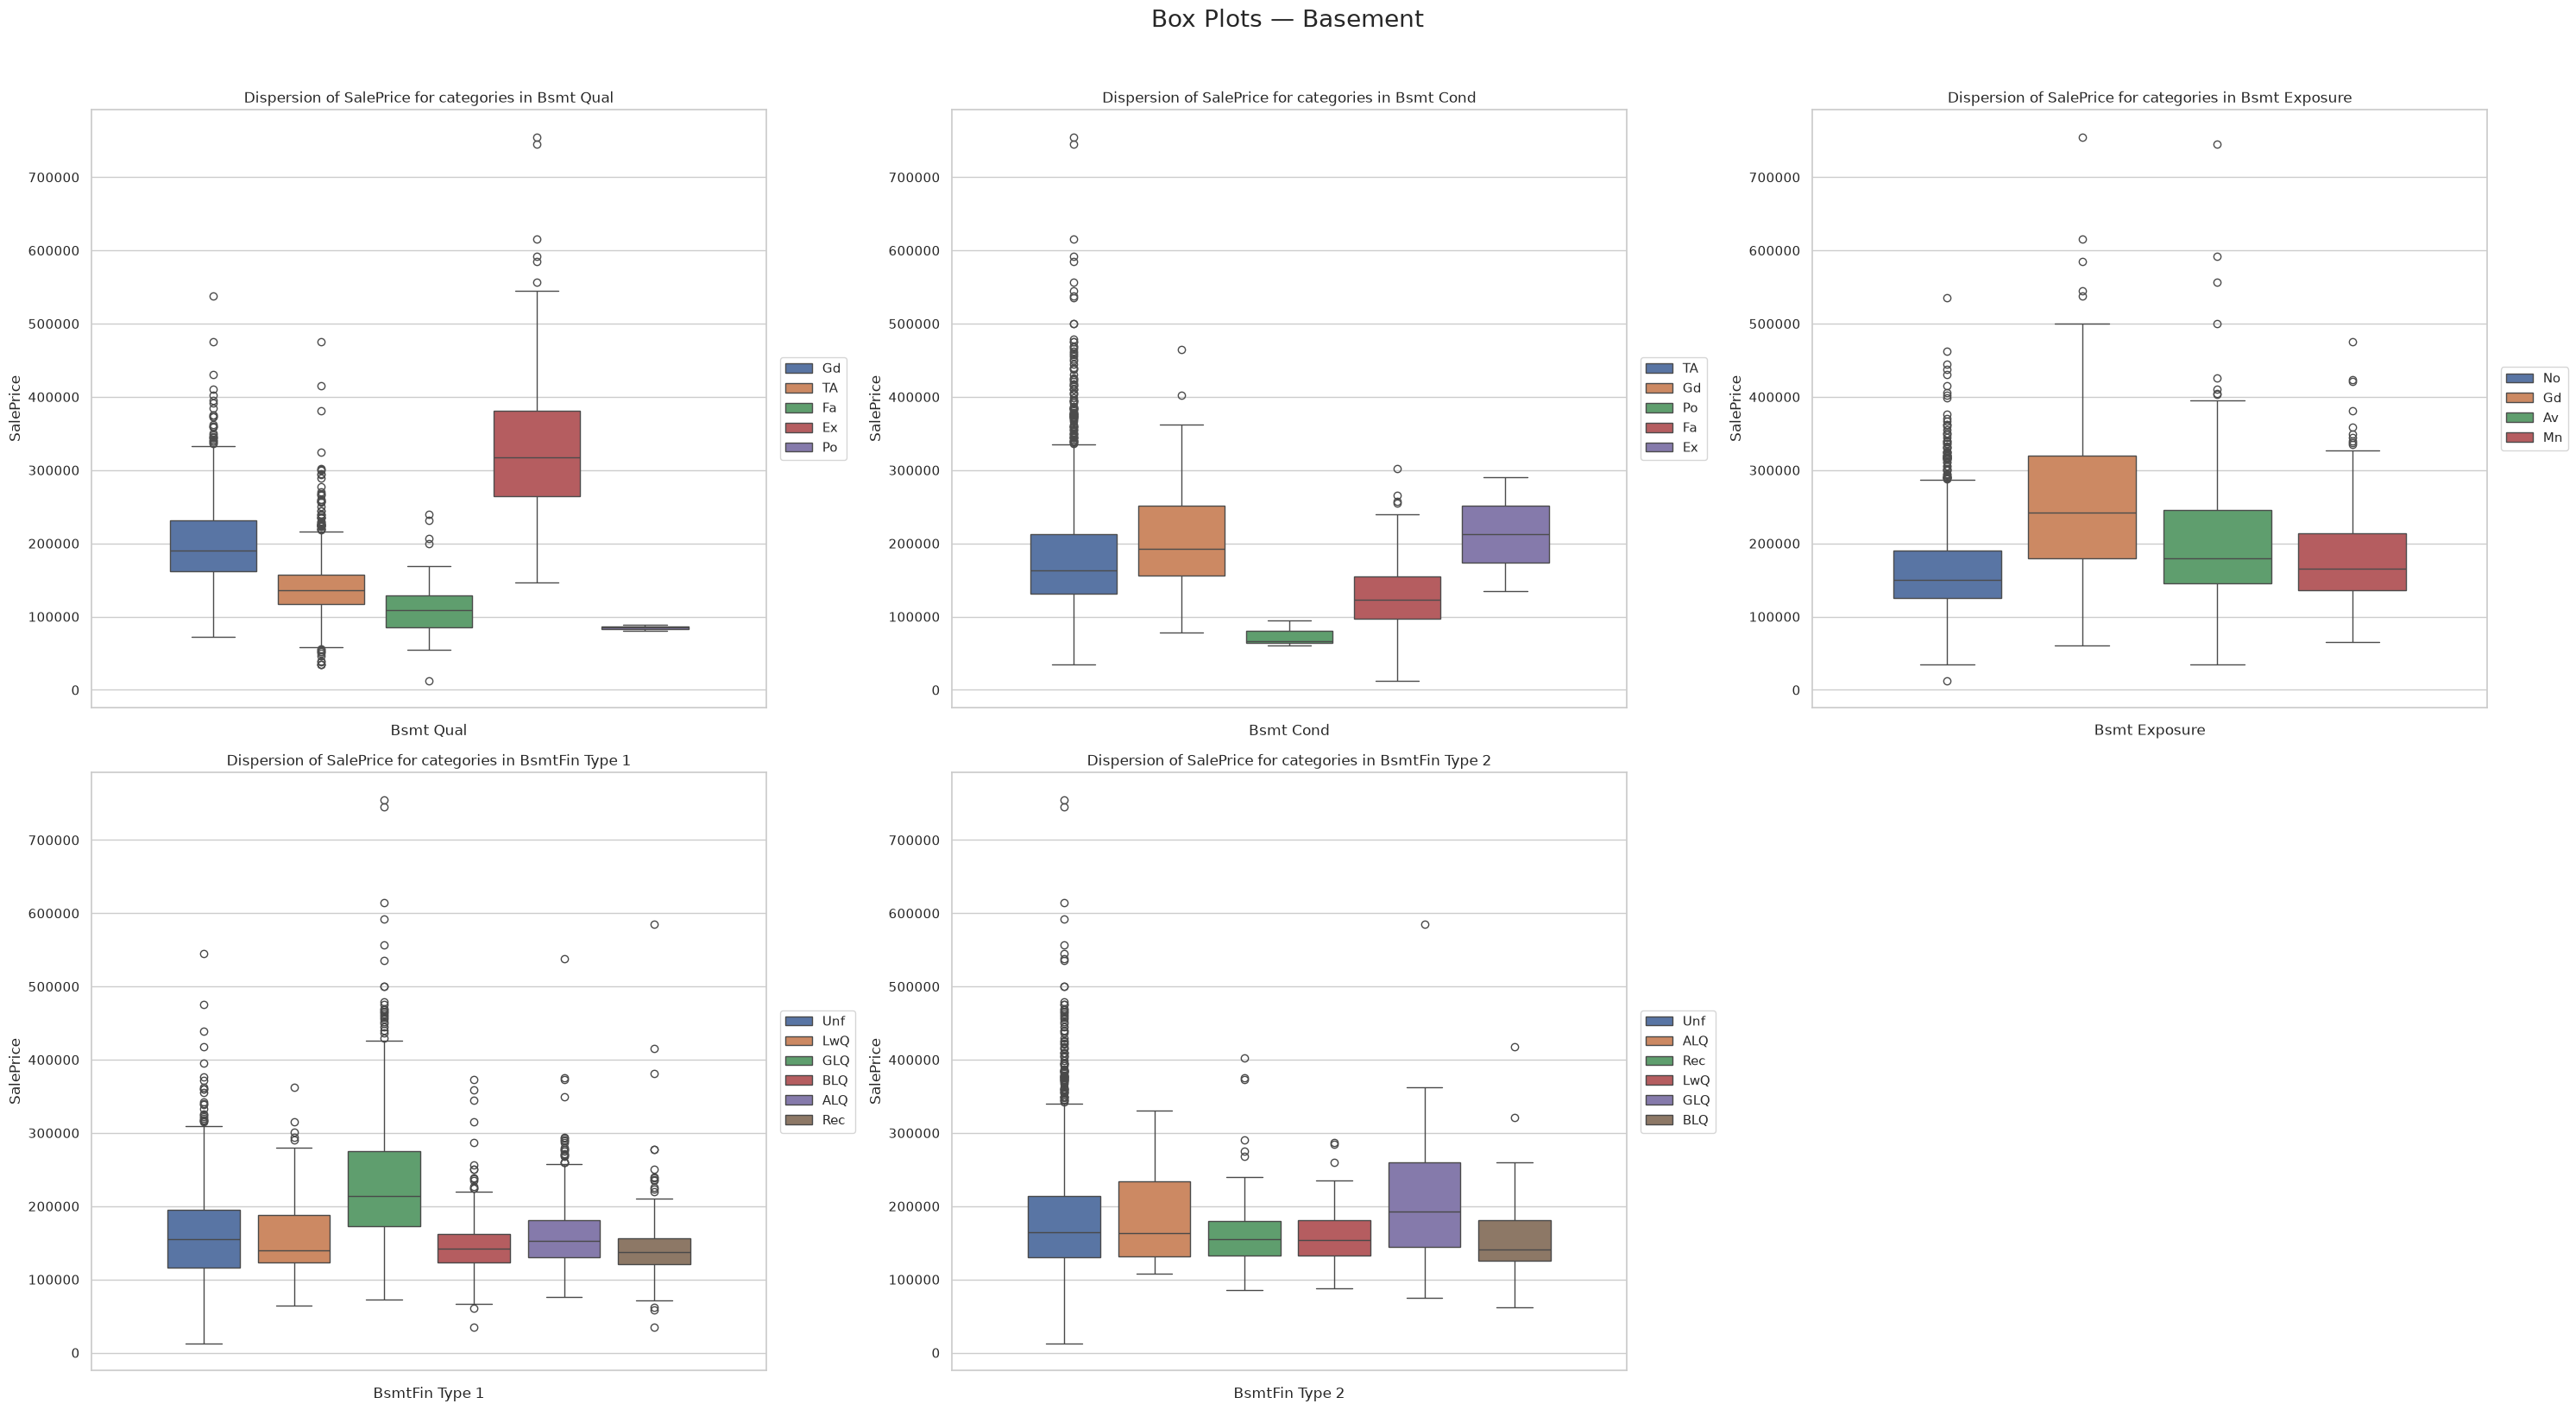

In [33]:
plot_columns = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                'BsmtFin Type 1', 'BsmtFin Type 2']

boxplot_grid(basment_df, plot_columns, ncols=3,
             save_path="./images/boxplots-for-Basement-information.png",
             suptitle="Box Plots — Basement")

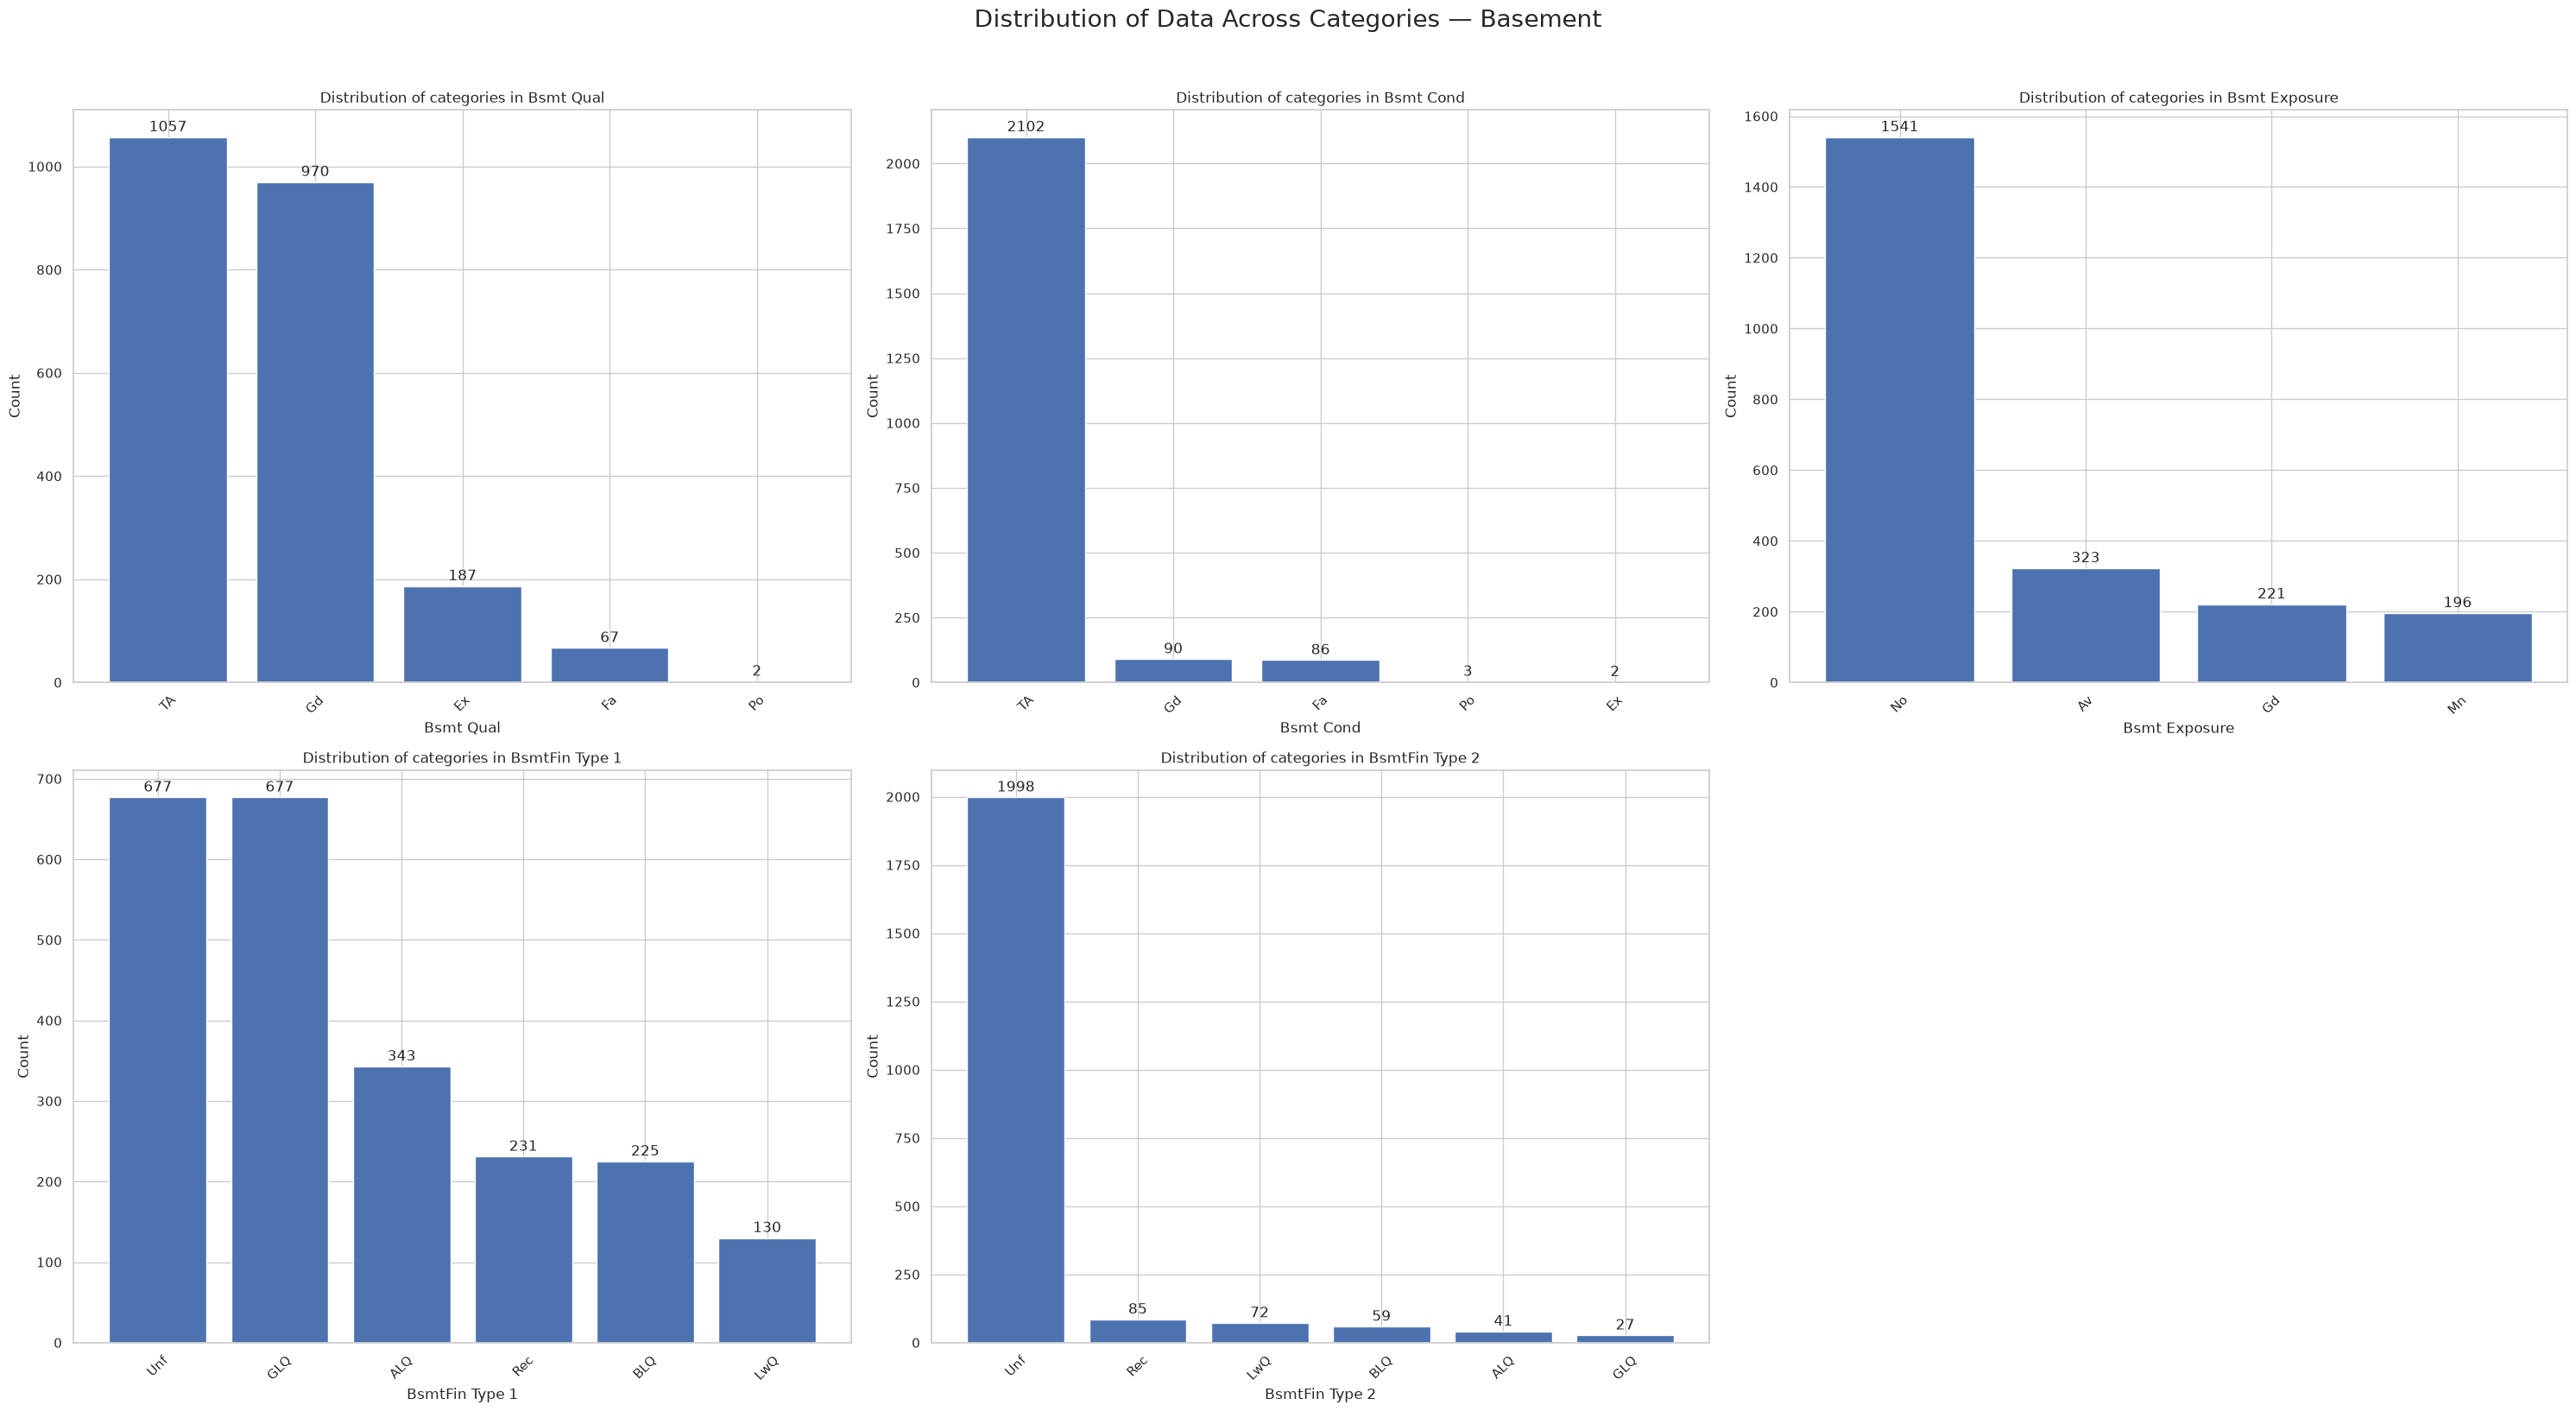

In [34]:
bar_chart_grid(basment_df, plot_columns, ncols=3,
               save_path="./images/dispersion-of-data-for-basment-information.png",
               suptitle="Distribution of Data Across Categories — Basement")

In [35]:
missing_summary(basment_df)

,Empty rows
Bsmt Qual,61
Bsmt Cond,61
Bsmt Exposure,63
BsmtFin Type 1,61
BsmtFin SF 1,1
BsmtFin Type 2,62
BsmtFin SF 2,1
Bsmt Unf SF,1
Total Bsmt SF,1
SalePrice,0


In [36]:
correlation_table(basment_df, ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF'])
# strong monotonic linear correlation

,Pearson,Spearman,Kendall
BsmtFin SF 1,0.424,0.339,0.247
BsmtFin SF 2,0.027,-0.019,-0.015
Bsmt Unf SF,0.164,0.141,0.097
Total Bsmt SF,0.612,0.592,0.427


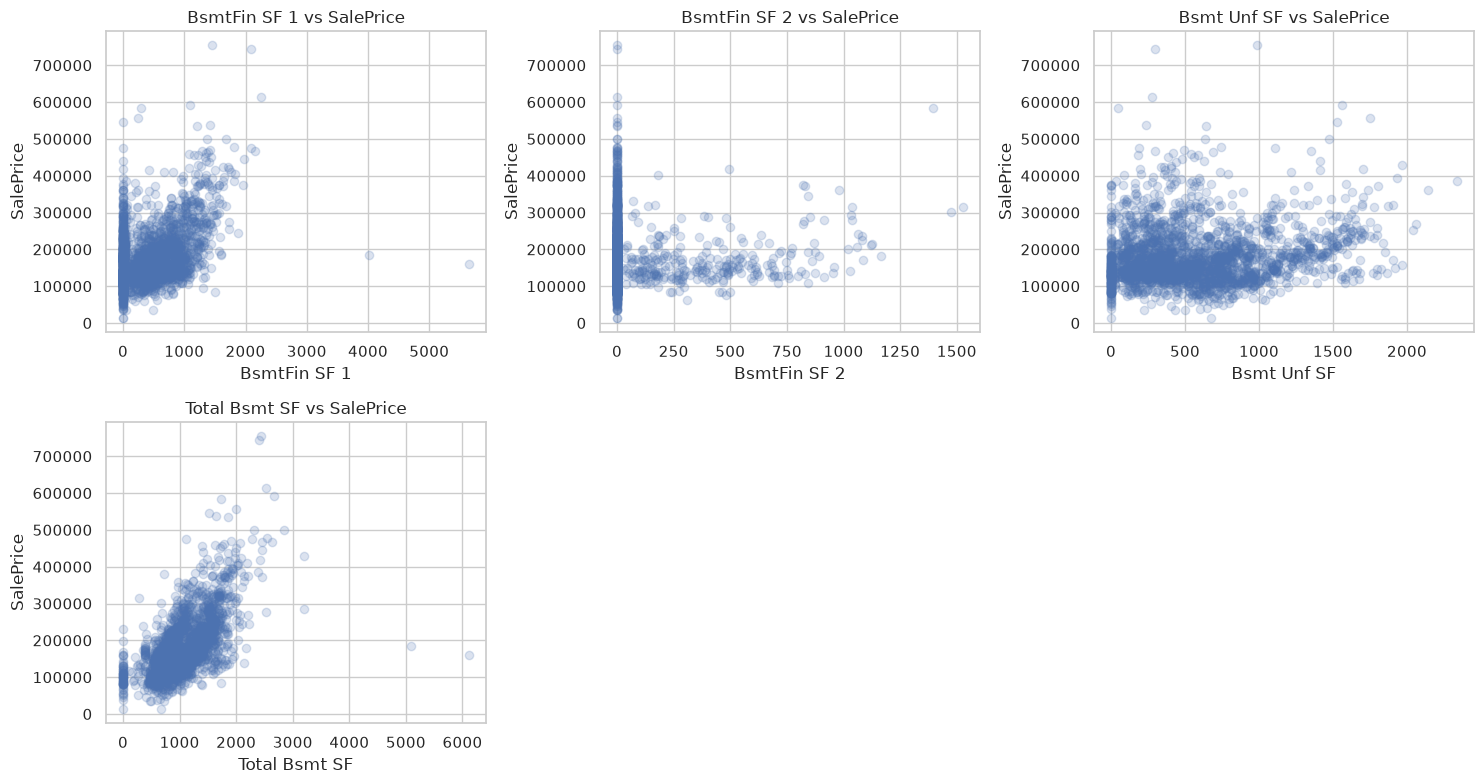

In [37]:
scatter_subplot(basment_df,
                ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF'],
                'SalePrice',
                save_path="./images/plots-for-basement-features-and-sales-correlation.png")

---
## Heating & Utilities
| Column | Meaning |
|---|---|
| **Heating** | Type of heating (Gas forced-air, Gas hot-water, Gravity furnace, etc.) |
| **Heating QC** | Heating quality and condition (Ex/Gd/TA/Fa/Po) |
| **Central Air** | Central air conditioning (Y/N) |
| **Electrical** | Electrical system (Standard Circuit Breakers, Fuse types, etc.) |
---

In [38]:
heating_df = df[['Heating', 'Heating QC', 'Central Air', 'Electrical', 'SalePrice']]

In [39]:
heating_df.dtypes

Heating          str
Heating QC       str
Central Air      str
Electrical       str
SalePrice      int64
dtype: object

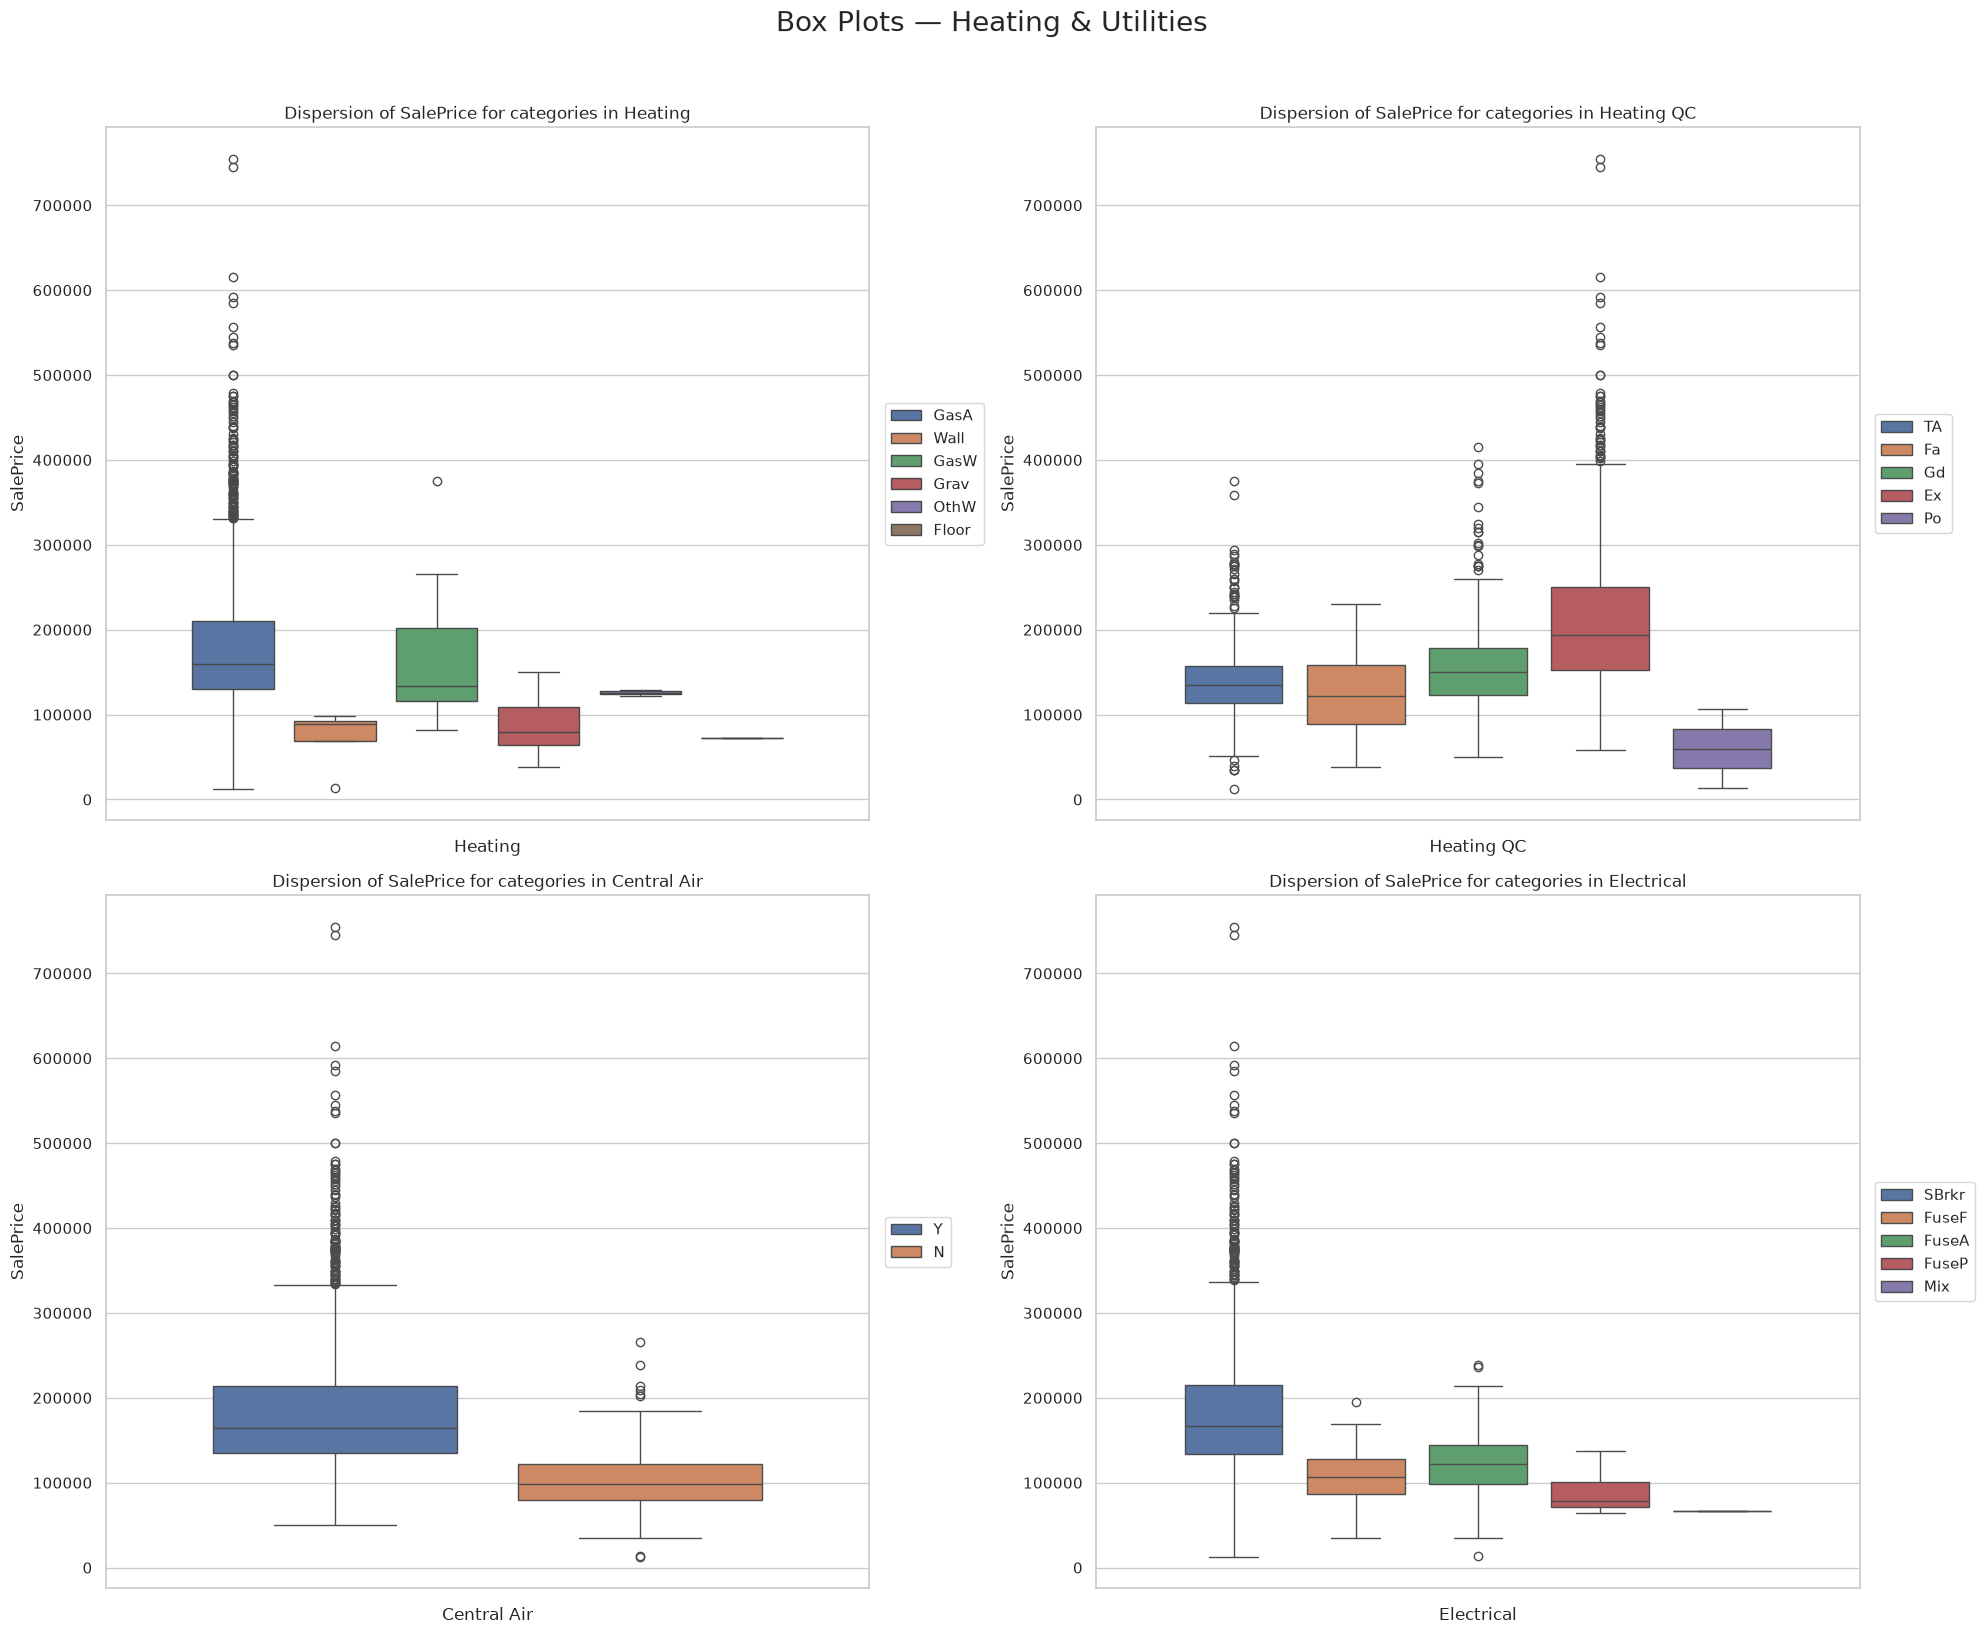

In [40]:
plot_columns = ['Heating', 'Heating QC', 'Central Air', 'Electrical']

boxplot_grid(heating_df, plot_columns, ncols=2,
             save_path="./images/boxplots-for-heating-information.png",
             suptitle="Box Plots — Heating & Utilities")

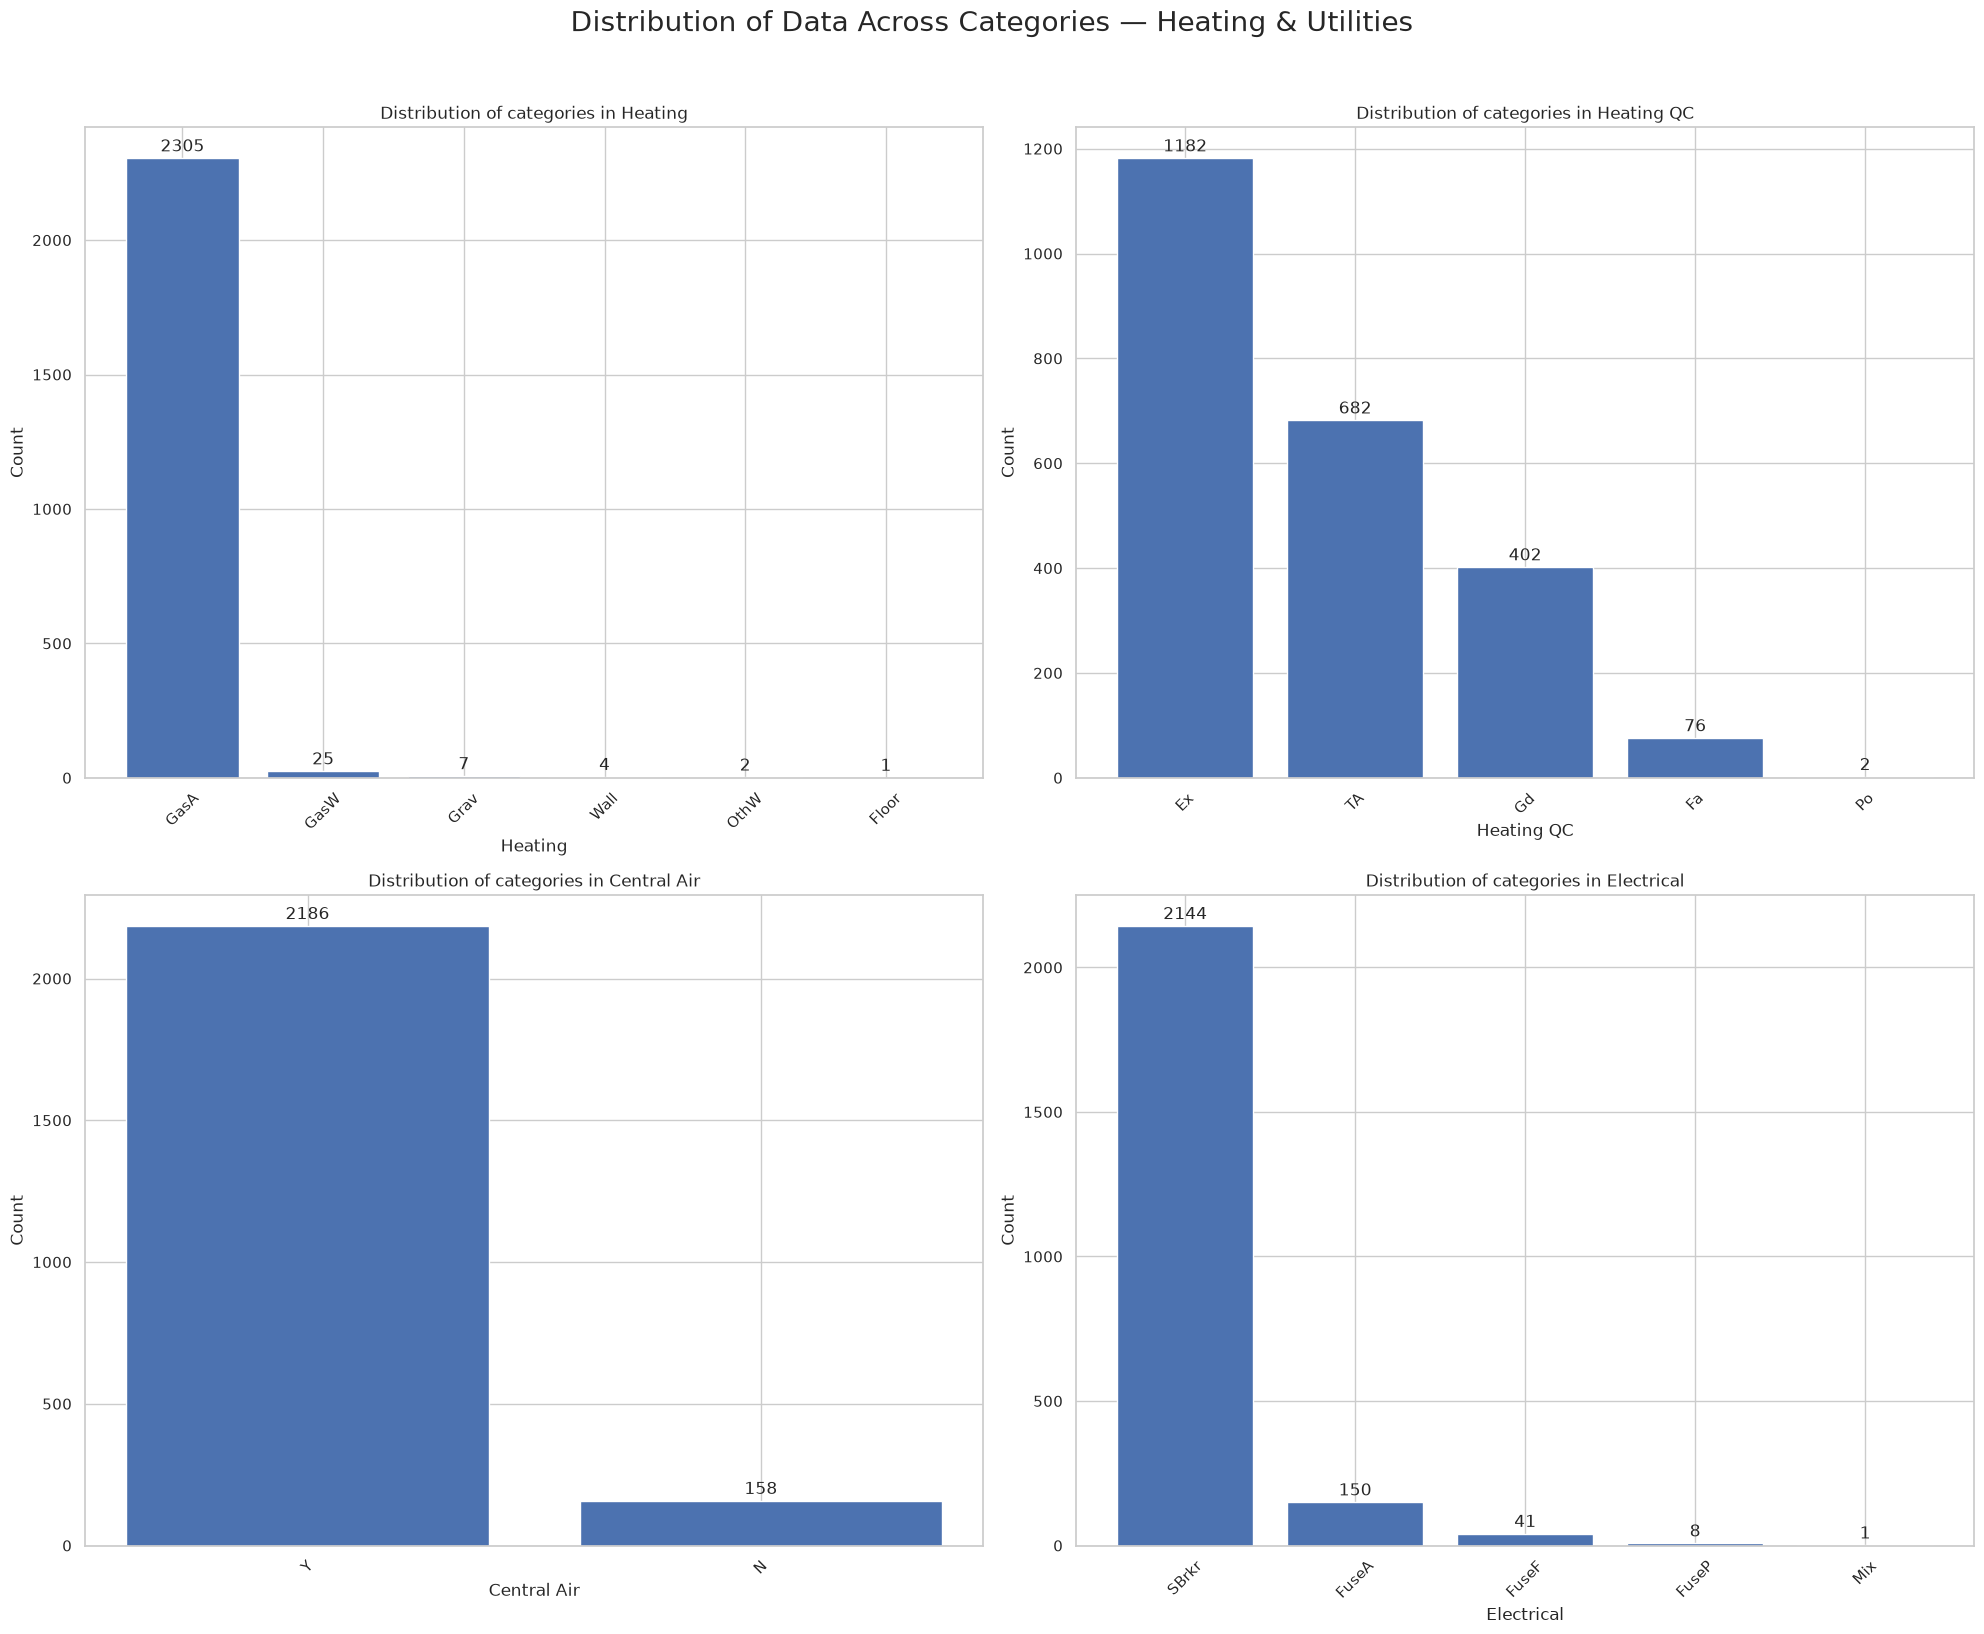

In [41]:
bar_chart_grid(heating_df, plot_columns, ncols=2,
               save_path="./images/dispersion-of-data-for-heating-information.png",
               suptitle="Distribution of Data Across Categories — Heating & Utilities")

In [42]:
missing_summary(heating_df)

,Empty rows
Heating,0
Heating QC,0
Central Air,0
Electrical,0
SalePrice,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| — | No missing values in this group | — |

2. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **Heating QC** | Ordinal quality scale (Ex/Gd/TA/Fa/Po) | Map to numeric 5/4/3/2/1 — already handled in `QUALITY_MAPPINGS` |
| **Central Air** | Binary Y/N | Map to 1/0 — already handled in `QUALITY_MAPPINGS` |

3. Rare-Category Handling

| Column | Rare categories | Fix |
|---|---|---|
| **Heating** | Grav (7), Wall (4), Floor (1), OthW (2) — combined <1% | Collapse into `'Other'` — already in `CATEGORY_COLLAPSE` |
| **Electrical** | FuseP (8), Mix (1) — <0.5% | Collapse into `'Other'` — already in `CATEGORY_COLLAPSE` |

4. Drop Candidates (near-zero variance)

| Column | Reason |
|---|---|
| **Heating** | 98%+ GasA — near-constant even after collapsing rare categories |
| **Central Air** | 93% Y — low variance but boxplot shows clear price separation, **keep** |

---

---
## Living Area & Rooms
| Column | Meaning |
|---|---|
| **1st Flr SF** | First floor square feet |
| **2nd Flr SF** | Second floor square feet (0 if no second floor) |
| **Low Qual Fin SF** | Low quality finished square feet (all floors) |
| **Gr Liv Area** | Above grade (ground) living area square feet |
| **Bsmt Full Bath** | Basement full bathrooms |
| **Bsmt Half Bath** | Basement half bathrooms |
| **Full Bath** | Full bathrooms above grade |
| **Half Bath** | Half bathrooms above grade |
| **Bedroom AbvGr** | Bedrooms above grade |
| **Kitchen AbvGr** | Kitchens above grade |
| **Kitchen Qual** | Kitchen quality (Ex/Gd/TA/Fa/Po) |
| **TotRms AbvGrd** | Total rooms above grade (does not include bathrooms) |
| **Functional** | Home functionality (Typ = Typical, deductions for each level of deficiency) |
---

In [43]:
living_df = df[['1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
                 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
                 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
                 'TotRms AbvGrd', 'Functional', 'SalePrice']]

In [44]:
living_df.dtypes

1st Flr SF           int64
2nd Flr SF           int64
Low Qual Fin SF      int64
Gr Liv Area          int64
Bsmt Full Bath     float64
Bsmt Half Bath     float64
Full Bath            int64
Half Bath            int64
Bedroom AbvGr        int64
Kitchen AbvGr        int64
Kitchen Qual           str
TotRms AbvGrd        int64
Functional             str
SalePrice            int64
dtype: object

In [45]:
numeric_features = ['1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
                    'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
                    'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd']
correlation_table(living_df, numeric_features)

,Pearson,Spearman,Kendall
1st Flr SF,0.607,0.570,0.408
2nd Flr SF,0.279,0.251,0.198
Low Qual Fin SF,-0.016,-0.048,-0.039
Gr Liv Area,0.698,0.712,0.527
Bsmt Full Bath,0.287,0.271,0.221
Bsmt Half Bath,-0.024,-0.017,-0.014
Full Bath,0.542,0.632,0.514
Half Bath,0.285,0.336,0.273
Bedroom AbvGr,0.149,0.193,0.153
Kitchen AbvGr,-0.116,-0.136,-0.111


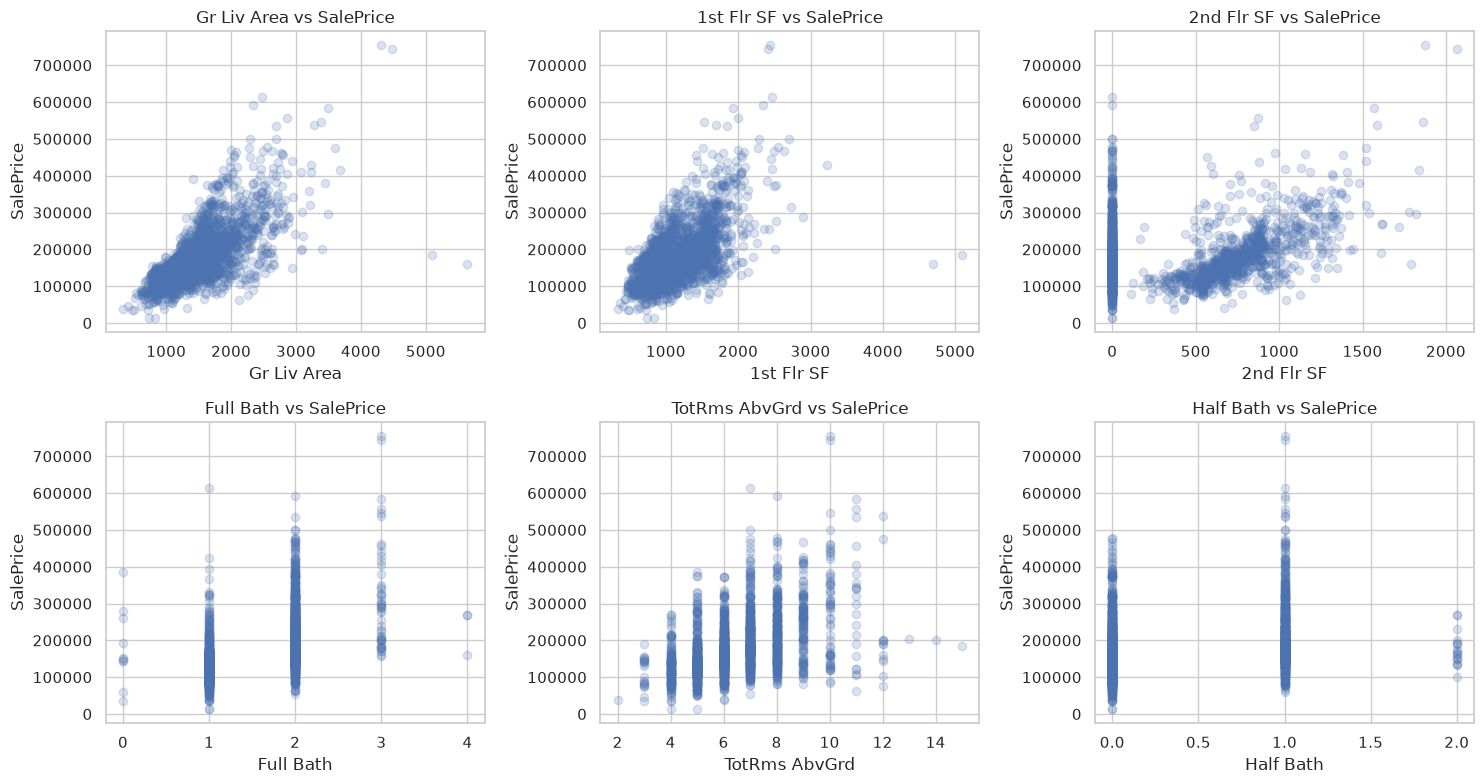

In [46]:
scatter_subplot(living_df,
                ['Gr Liv Area', '1st Flr SF', '2nd Flr SF', 'Full Bath',
                 'TotRms AbvGrd', 'Half Bath'],
                'SalePrice',
                save_path="./images/scatter-living-area-vs-price.png")

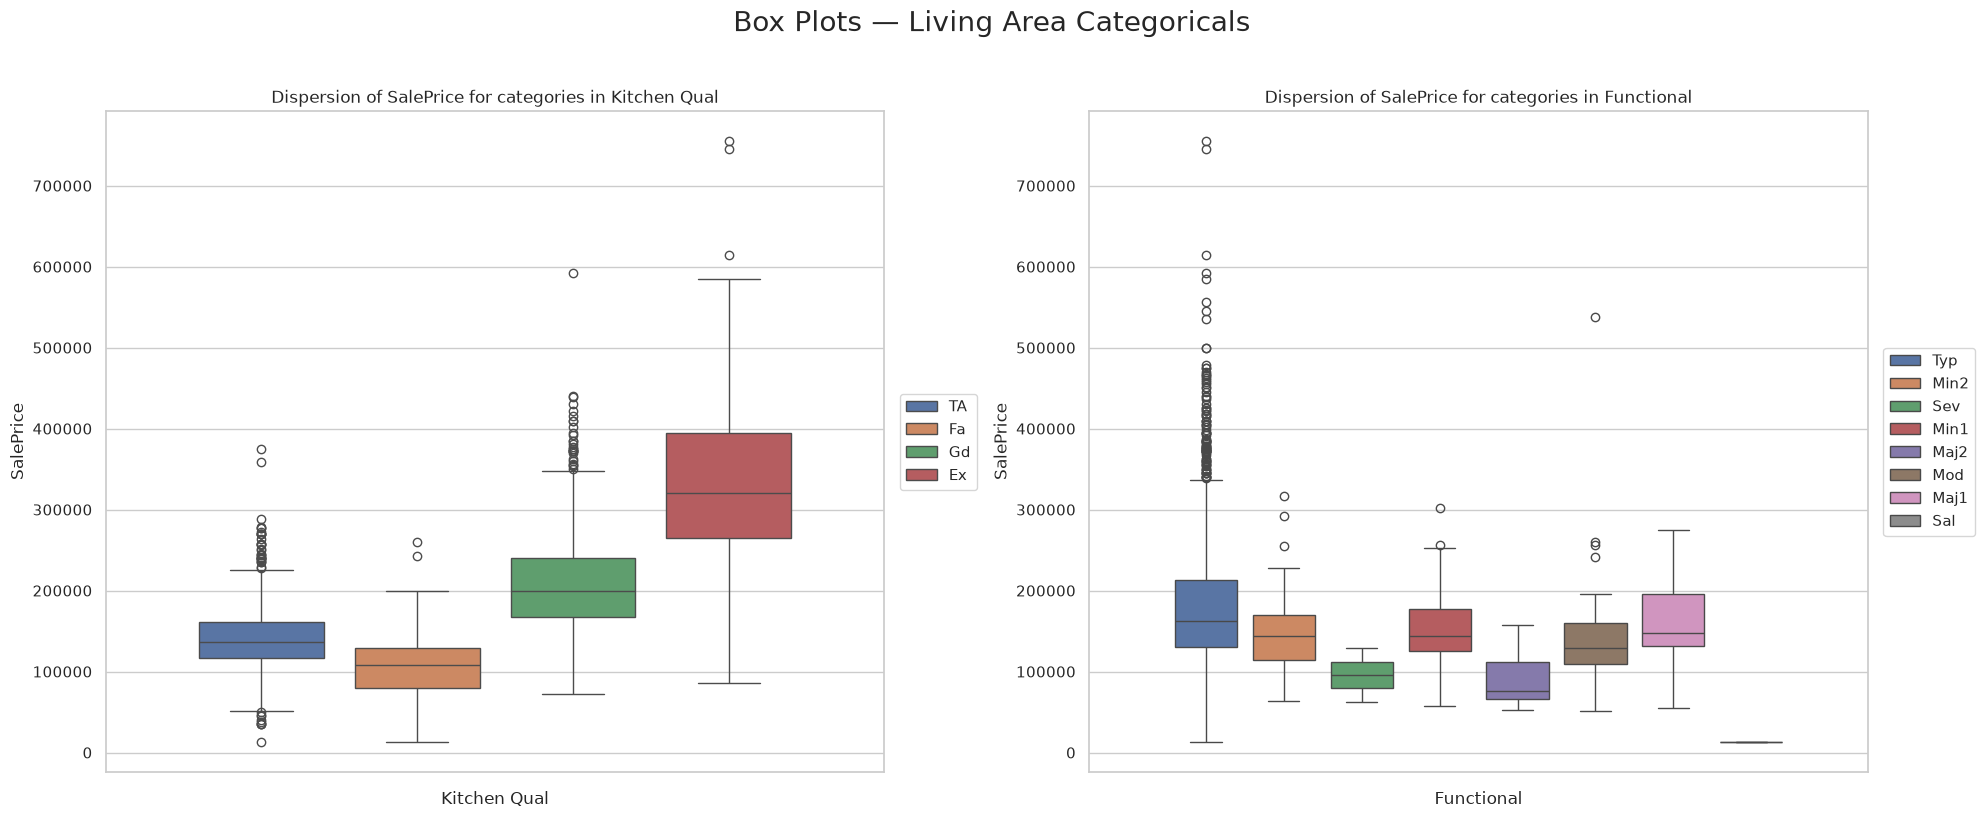

In [47]:
cat_columns = ['Kitchen Qual', 'Functional']

boxplot_grid(living_df, cat_columns, ncols=2,
             save_path="./images/boxplots-for-living-area-information.png",
             suptitle="Box Plots — Living Area Categoricals")

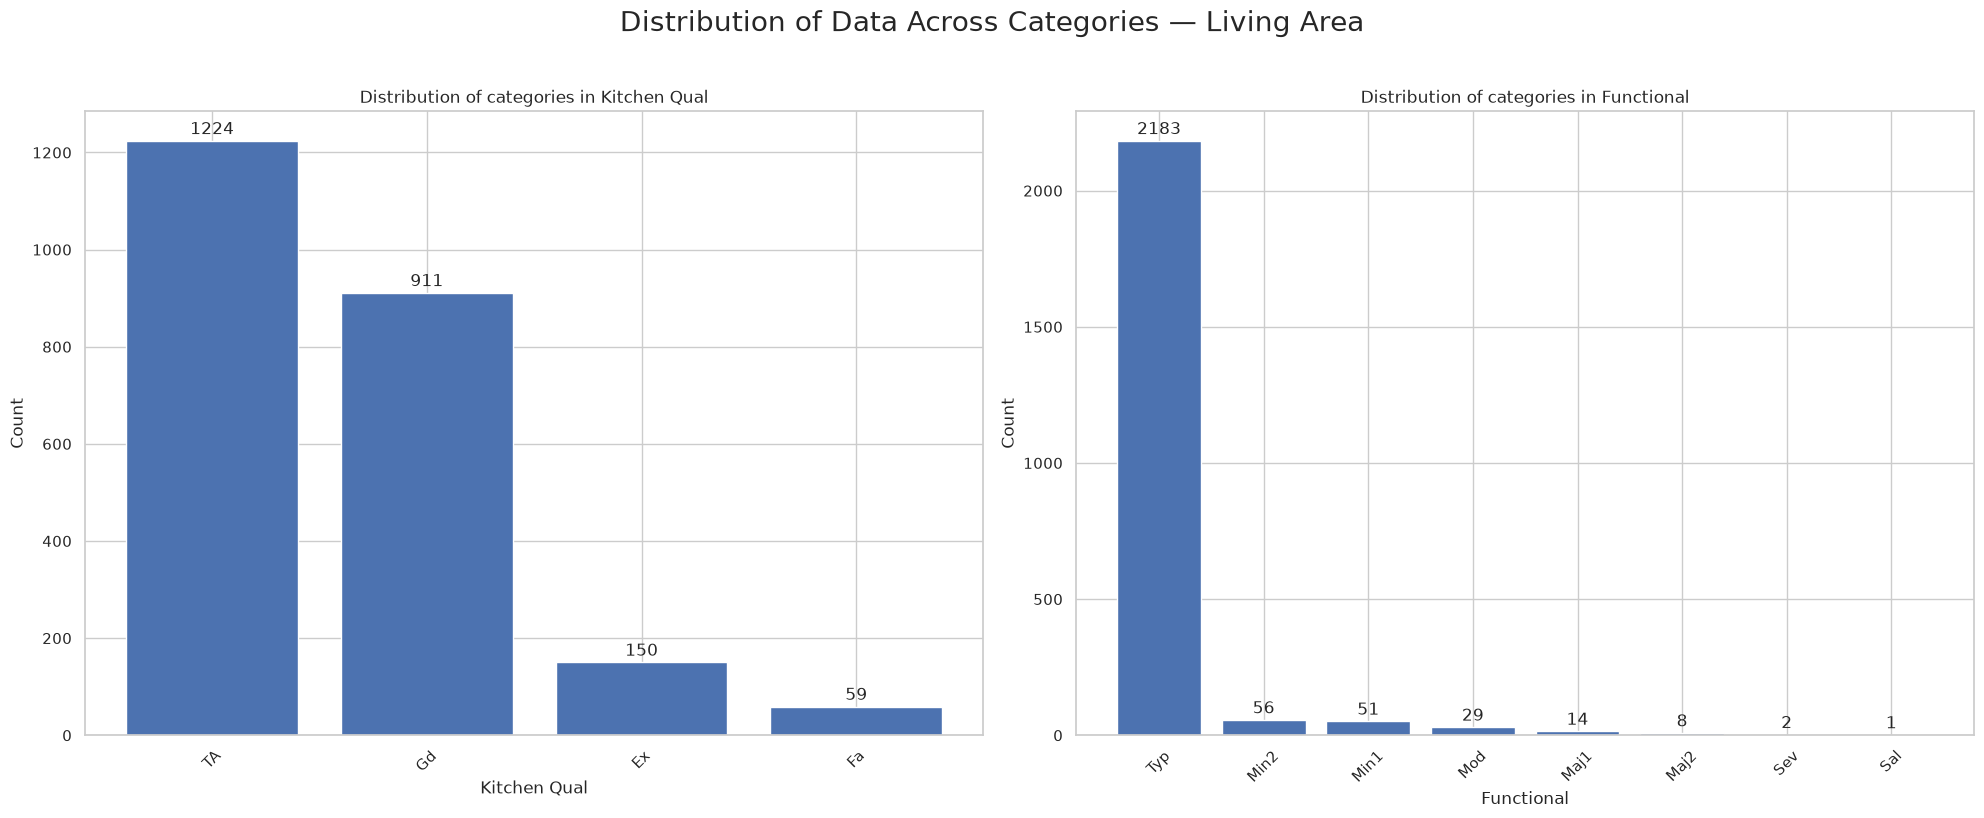

In [48]:
bar_chart_grid(living_df, cat_columns, ncols=2,
               save_path="./images/dispersion-of-data-for-living-area-information.png",
               suptitle="Distribution of Data Across Categories — Living Area")

In [49]:
missing_summary(living_df)

,Empty rows
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0
Bsmt Full Bath,1
Bsmt Half Bath,1
Full Bath,0
Half Bath,0
Bedroom AbvGr,0
Kitchen AbvGr,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| **Bsmt Full Bath** | 1 missing — likely no basement | `fillna(0)` |
| **Bsmt Half Bath** | 1 missing — likely no basement | `fillna(0)` |

2. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **Kitchen Qual** | Ordinal quality scale (Ex/Gd/TA/Fa) | Map to numeric 5/4/3/2 — already in `QUALITY_MAPPINGS` |
| **Functional** | Ordinal deduction scale, but rare categories | Collapse Min1/Min2→Min, Maj1/Maj2→Maj — already in `CATEGORY_COLLAPSE` |

3. Key Predictors

| Column | Spearman ρ | Note |
|---|---|---|
| **Gr Liv Area** | ~0.71 | Strongest single predictor — total above-grade living area |
| **Full Bath** | ~0.63 | Strong; aggregated into `TotalBath` in feature engineering |
| **1st Flr SF** | ~0.57 | Aggregated into `TotalSF` |
| **TotRms AbvGrd** | ~0.49 | Correlated with Gr Liv Area — potential multicollinearity |

4. Drop Candidates

| Column | Reason |
|---|---|
| **Low Qual Fin SF** | Median=0, mean≈4; 97%+ zeros; Spearman ρ ≈ −0.05 — near-zero signal |
| **Kitchen AbvGr** | 96%+ have exactly 1 kitchen — near-constant |
| **Bsmt Half Bath** | Median=0, Spearman ρ ≈ −0.02 — near-zero signal |

---

---
## Fireplace
| Column | Meaning |
|---|---|
| **Fireplaces** | Number of fireplaces |
| **Fireplace Qu** | Fireplace quality (Ex/Gd/TA/Fa/Po) |
---

In [50]:
fire_df = df[['Fireplaces', 'Fireplace Qu', 'SalePrice']]

In [51]:
fire_df.dtypes

Fireplaces      int64
Fireplace Qu      str
SalePrice       int64
dtype: object

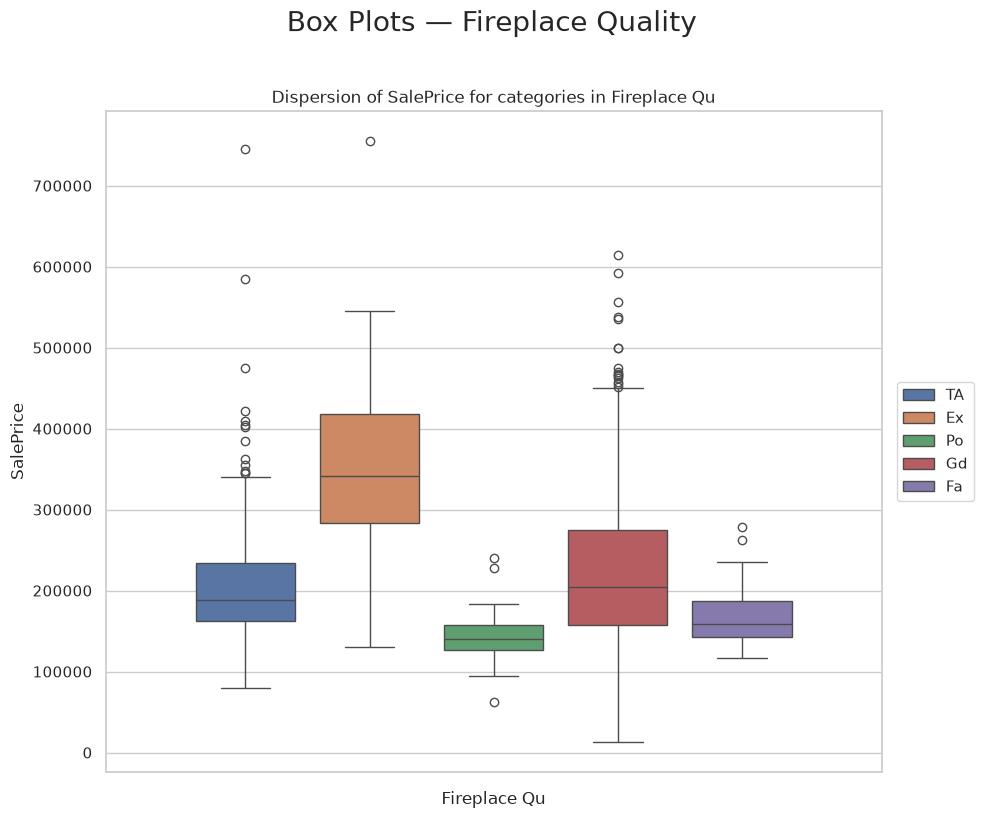

In [52]:
boxplot_grid(fire_df, ['Fireplace Qu'], ncols=1,
             save_path="./images/boxplots-for-fireplace-information.png",
             suptitle="Box Plots — Fireplace Quality")

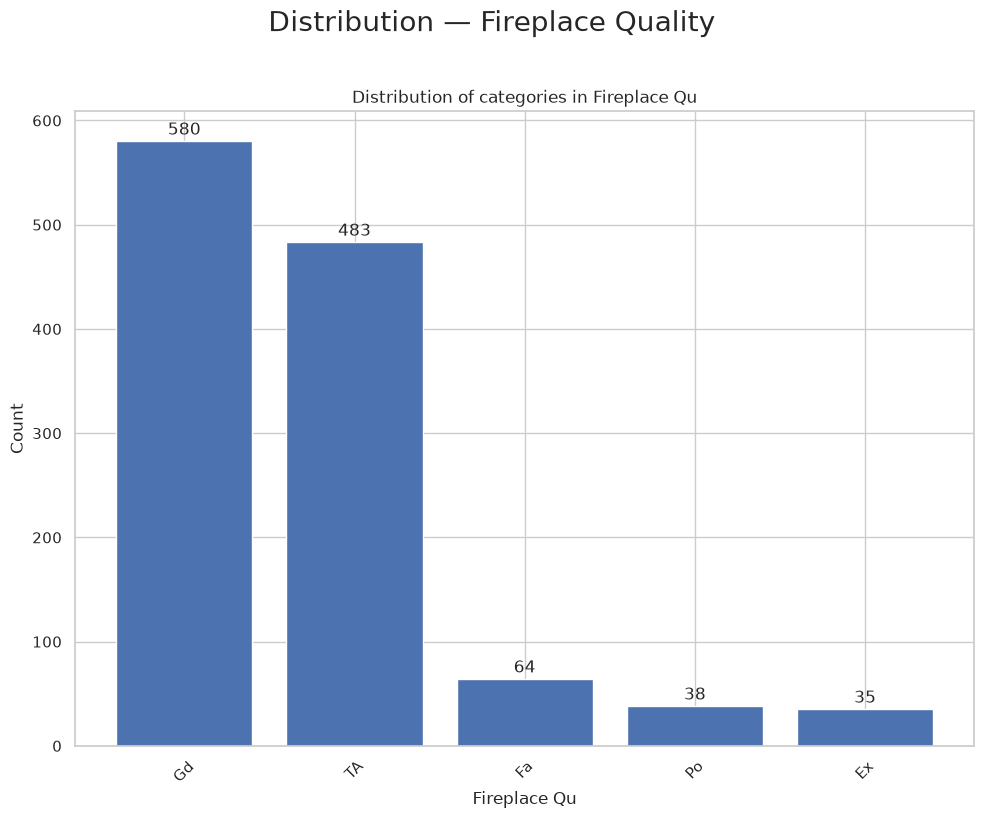

In [53]:
bar_chart_grid(fire_df, ['Fireplace Qu'], ncols=1,
               save_path="./images/dispersion-of-data-for-fireplace-information.png",
               suptitle="Distribution — Fireplace Quality")

In [54]:
correlation_table(fire_df, ['Fireplaces'])

,Pearson,Spearman,Kendall
Fireplaces,0.468,0.516,0.411


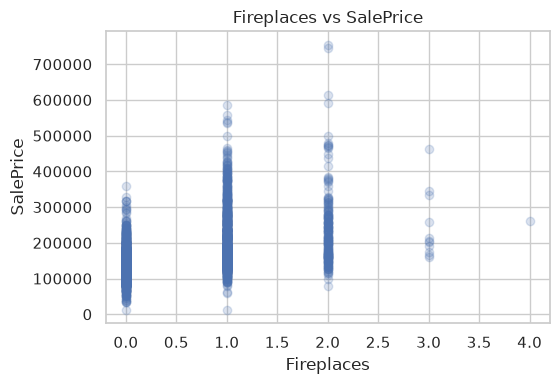

In [55]:
scatter_subplot(fire_df, ['Fireplaces'], 'SalePrice',
                save_path="./images/scatter-fireplaces-vs-price.png")

In [56]:
missing_summary(fire_df)

,Empty rows
Fireplaces,0
Fireplace Qu,1144
SalePrice,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| **Fireplace Qu** | ~1144 missing (~49%) — means "no fireplace" | `fillna('None')` → maps to 0 via `QUALITY_MAPPINGS` |

2. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **Fireplace Qu** | Ordinal quality scale (Ex/Gd/TA/Fa/Po/None) | Map to numeric 5/4/3/2/1/0 — already in `QUALITY_MAPPINGS` |

3. Key Predictors

| Column | Spearman ρ | Note |
|---|---|---|
| **Fireplaces** | ~0.52 | Moderate positive — more fireplaces = higher price |

4. Feature Engineering

| Feature | Source | Note |
|---|---|---|
| **HasFireplace** | `Fireplaces > 0` | Binary flag — already in `AmesFeatureEngineer` |

---

---
## Garage
| Column | Meaning |
|---|---|
| **Garage Type** | Garage location (Attached, Detached, Built-In, Basement, Car Port, etc.) |
| **Garage Yr Blt** | Year garage was built |
| **Garage Finish** | Interior finish of the garage (Finished, Rough Finished, Unfinished) |
| **Garage Cars** | Size of garage in car capacity |
| **Garage Area** | Size of garage in square feet |
| **Garage Qual** | Garage quality (Ex/Gd/TA/Fa/Po) |
| **Garage Cond** | Garage condition (Ex/Gd/TA/Fa/Po) |
| **Paved Drive** | Paved driveway (Y = Paved, P = Partial, N = Dirt/Gravel) |
---

In [57]:
garage_df = df[['Garage Type', 'Garage Yr Blt', 'Garage Finish',
                 'Garage Cars', 'Garage Area', 'Garage Qual',
                 'Garage Cond', 'Paved Drive', 'SalePrice']]

In [58]:
garage_df.dtypes

Garage Type          str
Garage Yr Blt    float64
Garage Finish        str
Garage Cars      float64
Garage Area      float64
Garage Qual          str
Garage Cond          str
Paved Drive          str
SalePrice          int64
dtype: object

In [59]:
correlation_table(garage_df, ['Garage Yr Blt', 'Garage Cars', 'Garage Area'])

,Pearson,Spearman,Kendall
Garage Yr Blt,0.516,0.620,0.441
Garage Cars,0.644,0.691,0.571
Garage Area,0.633,0.646,0.476


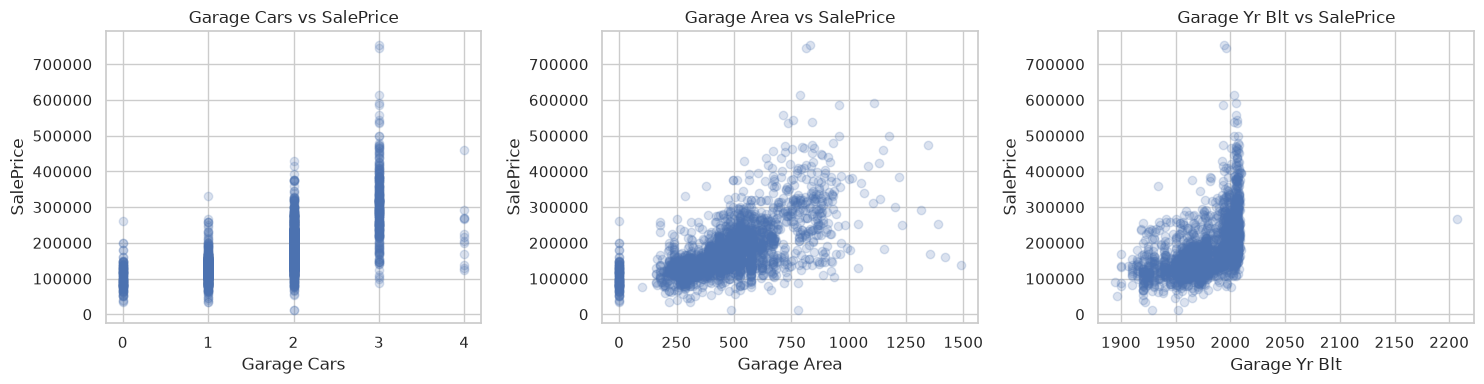

In [60]:
scatter_subplot(garage_df,
                ['Garage Cars', 'Garage Area', 'Garage Yr Blt'],
                'SalePrice',
                save_path="./images/scatter-garage-vs-price.png")

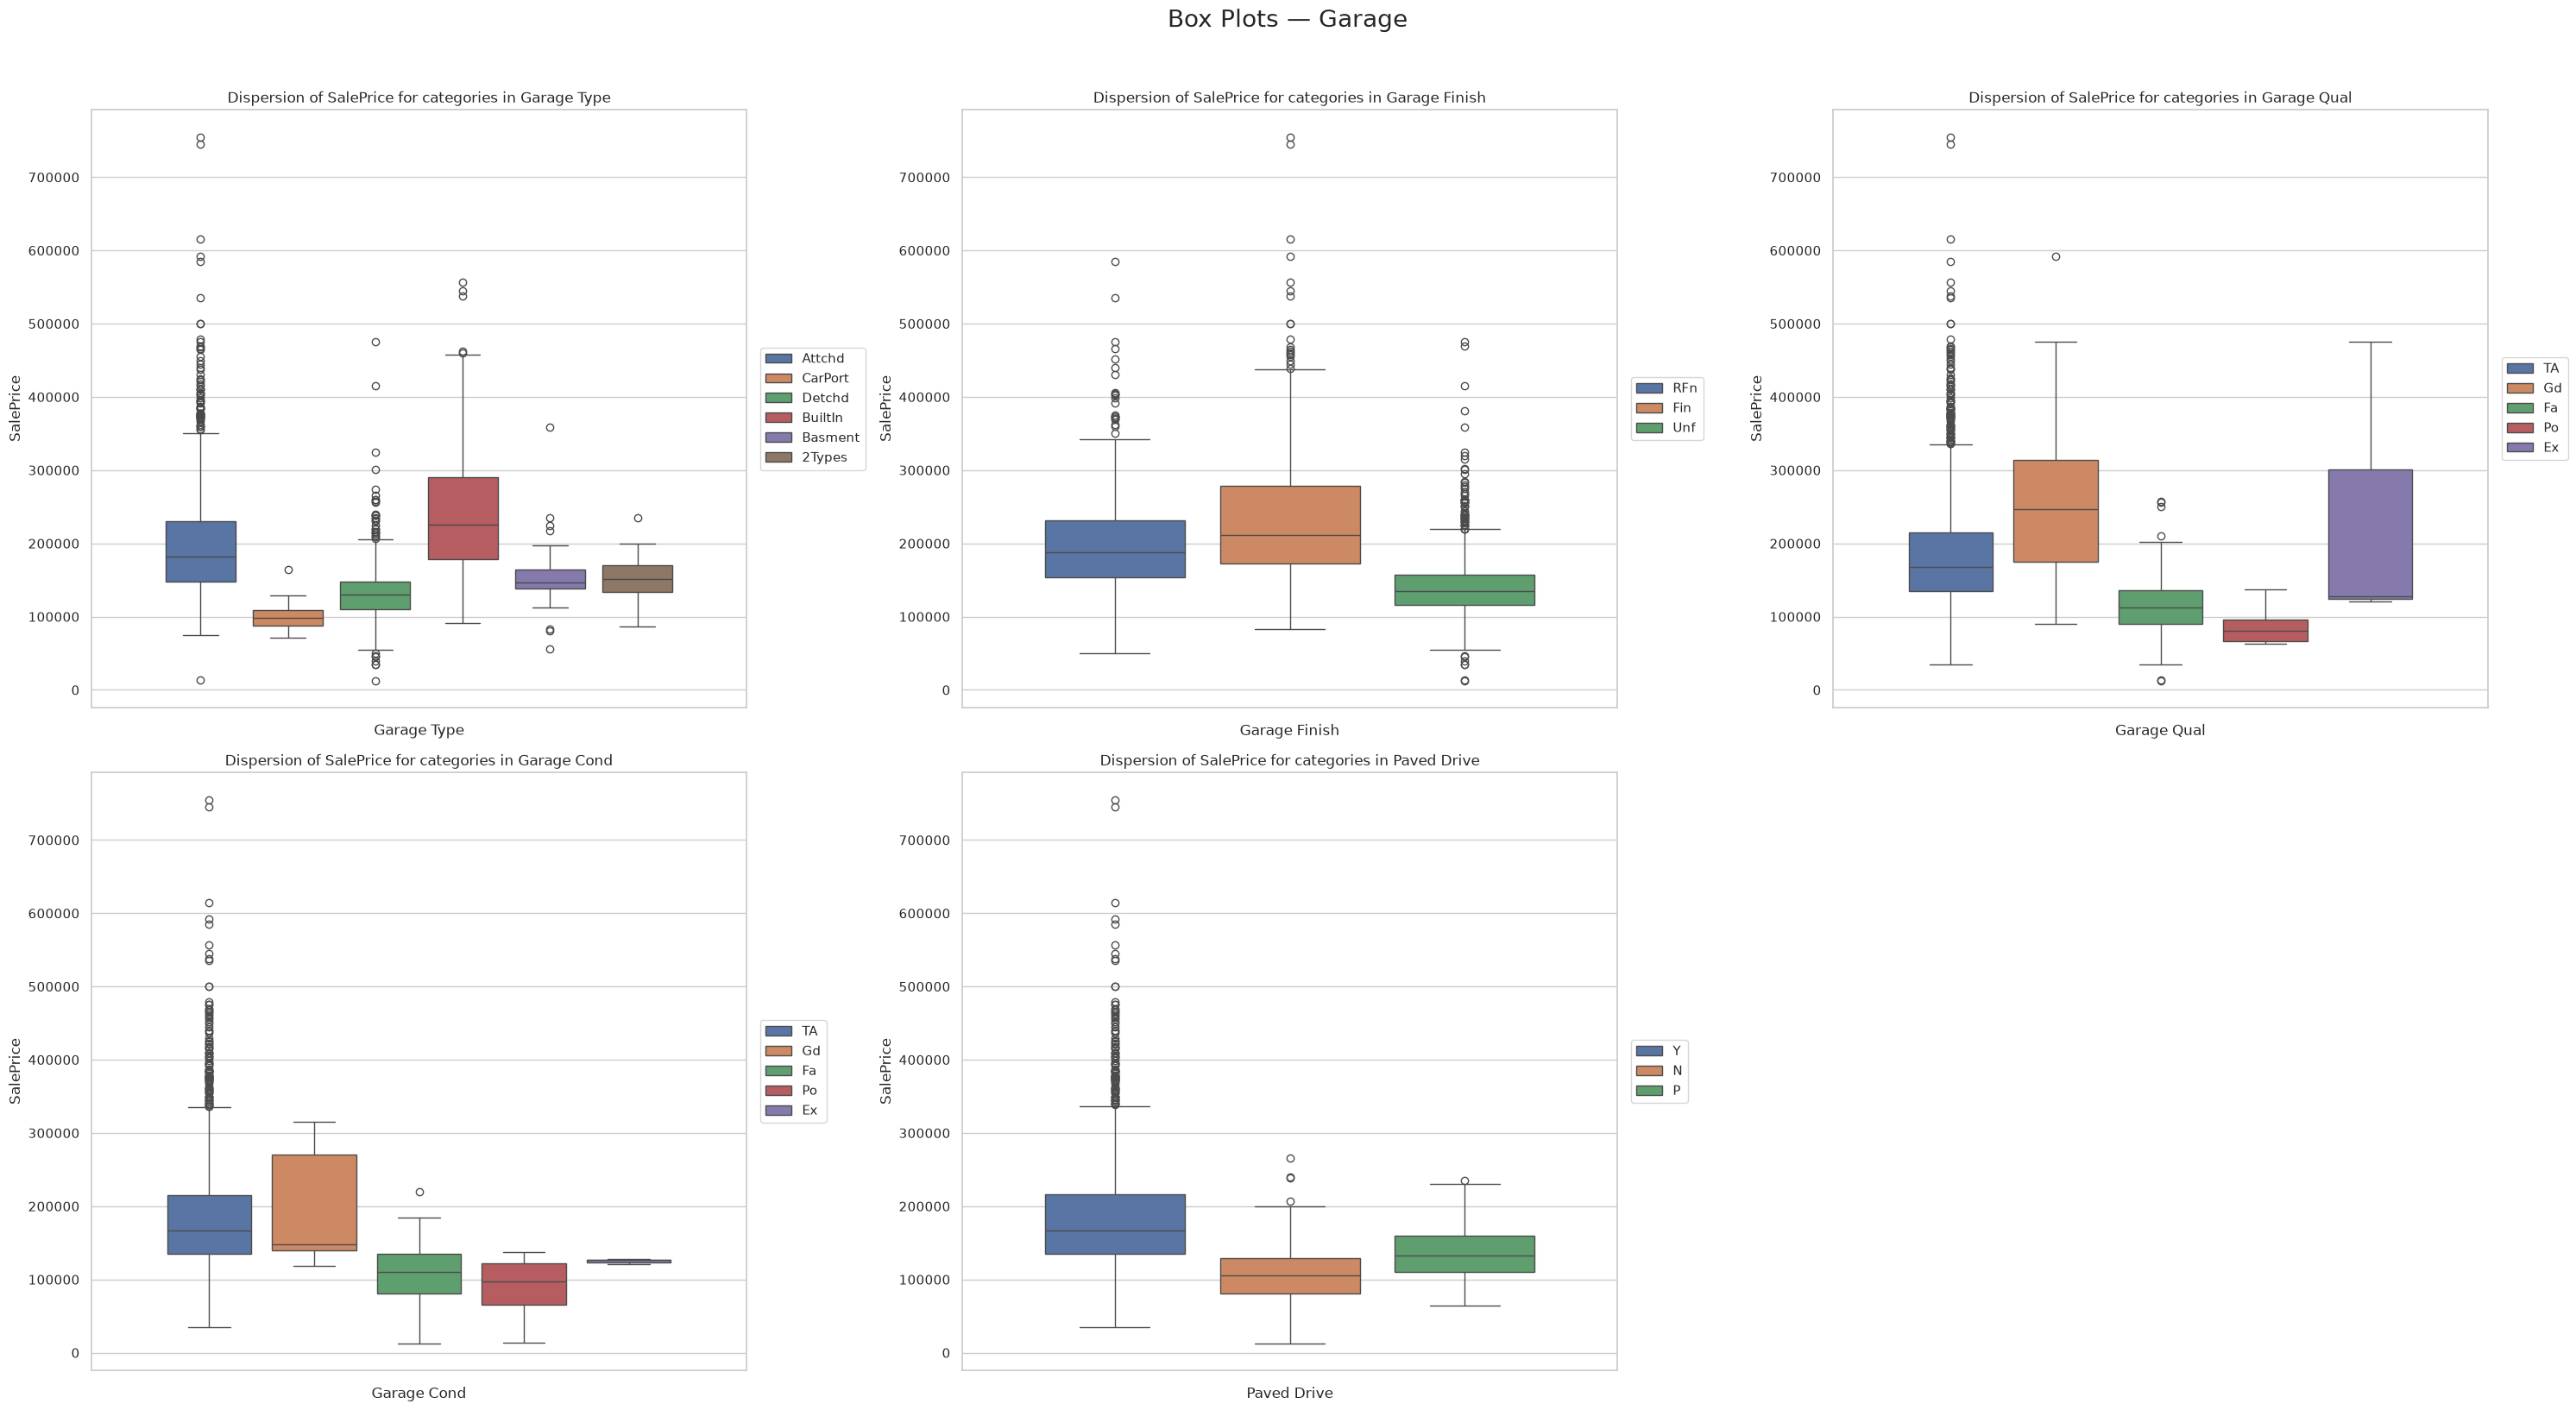

In [61]:
cat_columns = ['Garage Type', 'Garage Finish', 'Garage Qual',
               'Garage Cond', 'Paved Drive']

boxplot_grid(garage_df, cat_columns, ncols=3,
             save_path="./images/boxplots-for-garage-information.png",
             suptitle="Box Plots — Garage")

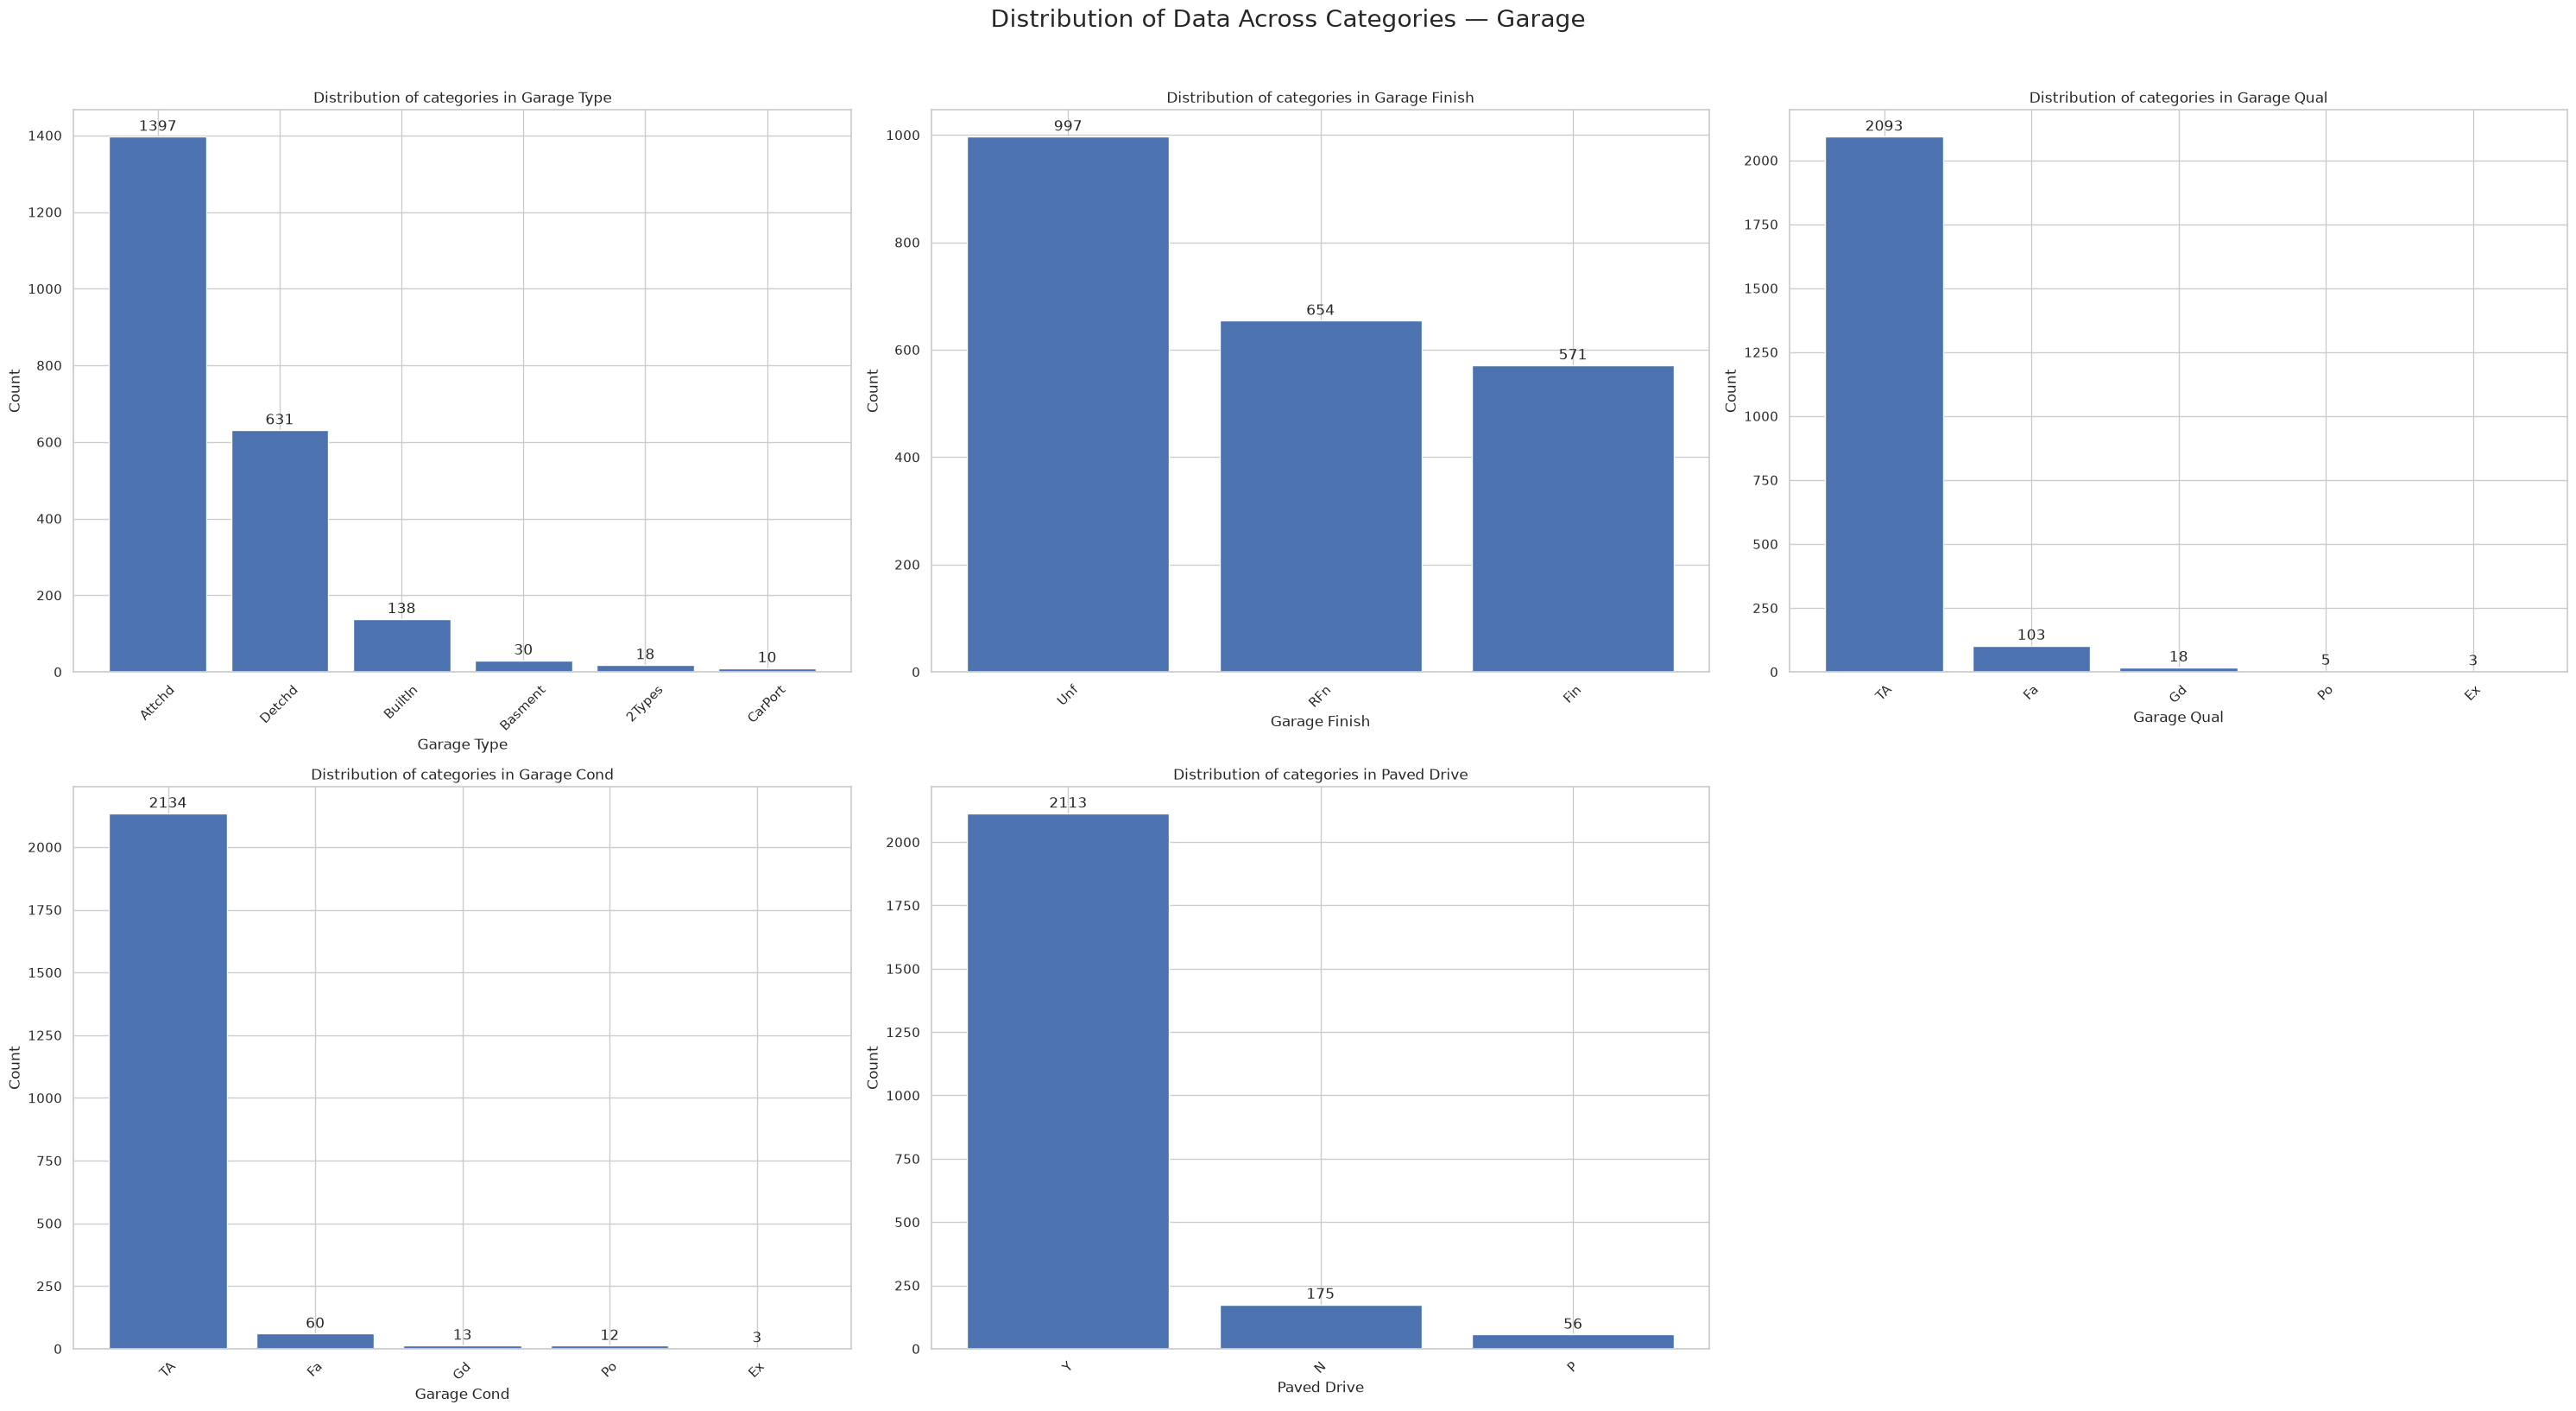

In [62]:
bar_chart_grid(garage_df, cat_columns, ncols=3,
               save_path="./images/dispersion-of-data-for-garage-information.png",
               suptitle="Distribution of Data Across Categories — Garage")

In [63]:
missing_summary(garage_df)

,Empty rows
Garage Type,120
Garage Yr Blt,122
Garage Finish,122
Garage Cars,1
Garage Area,1
Garage Qual,122
Garage Cond,122
Paved Drive,0
SalePrice,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| **Garage Type** | ~120 missing — means "no garage" | `fillna('None')` |
| **Garage Yr Blt** | ~122 missing — no garage | `fillna(0)` or drop — year is meaningless without a garage |
| **Garage Finish** | ~122 missing — no garage | `fillna('None')` → maps to 0 via `QUALITY_MAPPINGS` |
| **Garage Cars** | 1 missing | `fillna(0)` |
| **Garage Area** | 1 missing | `fillna(0)` |
| **Garage Qual / Cond** | ~122 missing — no garage | `fillna('None')` → maps to 0 via `QUALITY_MAPPINGS` |

2. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **Garage Finish** | Ordinal (Unf/RFn/Fin) | Map to 1/2/3 — already in `QUALITY_MAPPINGS` |
| **Garage Qual / Cond** | Ordinal quality scale | Map to 1–5 — already in `QUALITY_MAPPINGS` |
| **Paved Drive** | Ordinal (N/P/Y) | Map to 0/1/2 — already in `QUALITY_MAPPINGS` |

3. Key Predictors

| Column | Spearman ρ | Note |
|---|---|---|
| **Garage Cars** | ~0.69 | Strong — capacity is a proxy for house size/value |
| **Garage Area** | ~0.65 | Strong — closely correlated with Garage Cars |
| **Garage Yr Blt** | ~0.62 | Strong — newer garages → newer/pricier homes |

4. Rare-Category Handling

| Column | Rare categories | Fix |
|---|---|---|
| **Garage Type** | CarPort (10), 2Types (18), Basment (30) | Consider collapsing into `'Other'` |
| **Garage Qual** | 95%+ TA — near-constant | Limited predictive power individually |
| **Garage Cond** | 96%+ TA — near-constant | Limited predictive power individually |

5. Feature Engineering

| Feature | Source | Note |
|---|---|---|
| **HasGarage** | `Garage Area > 0` | Binary flag — already in `AmesFeatureEngineer` |

---

---
## Outdoor & Amenities
| Column | Meaning |
|---|---|
| **Wood Deck SF** | Wood deck area in square feet |
| **Open Porch SF** | Open porch area in square feet |
| **Enclosed Porch** | Enclosed porch area in square feet |
| **3Ssn Porch** | Three-season porch area in square feet |
| **Screen Porch** | Screen porch area in square feet |
| **Pool Area** | Pool area in square feet |
| **Pool QC** | Pool quality (Ex/Gd/TA/Fa) |
| **Fence** | Fence quality (GdPrv, MnPrv, GdWo, MnWw) |
| **Misc Feature** | Miscellaneous feature not covered in other categories (Shed, 2nd Garage, etc.) |
| **Misc Val** | Dollar value of miscellaneous feature |
---

In [64]:
outdoor_df = df[['Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
                  '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Pool QC',
                  'Fence', 'Misc Feature', 'Misc Val', 'SalePrice']]

In [65]:
outdoor_df.dtypes

Wood Deck SF      int64
Open Porch SF     int64
Enclosed Porch    int64
3Ssn Porch        int64
Screen Porch      int64
Pool Area         int64
Pool QC             str
Fence               str
Misc Feature        str
Misc Val          int64
SalePrice         int64
dtype: object

In [66]:
numeric_features = ['Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
                    '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val']
correlation_table(outdoor_df, numeric_features)

,Pearson,Spearman,Kendall
Wood Deck SF,0.333,0.354,0.260
Open Porch SF,0.298,0.465,0.339
Enclosed Porch,-0.131,-0.237,-0.184
3Ssn Porch,0.035,0.044,0.036
Screen Porch,0.137,0.112,0.090
Pool Area,0.079,0.057,0.046
Misc Val,-0.018,-0.053,-0.043


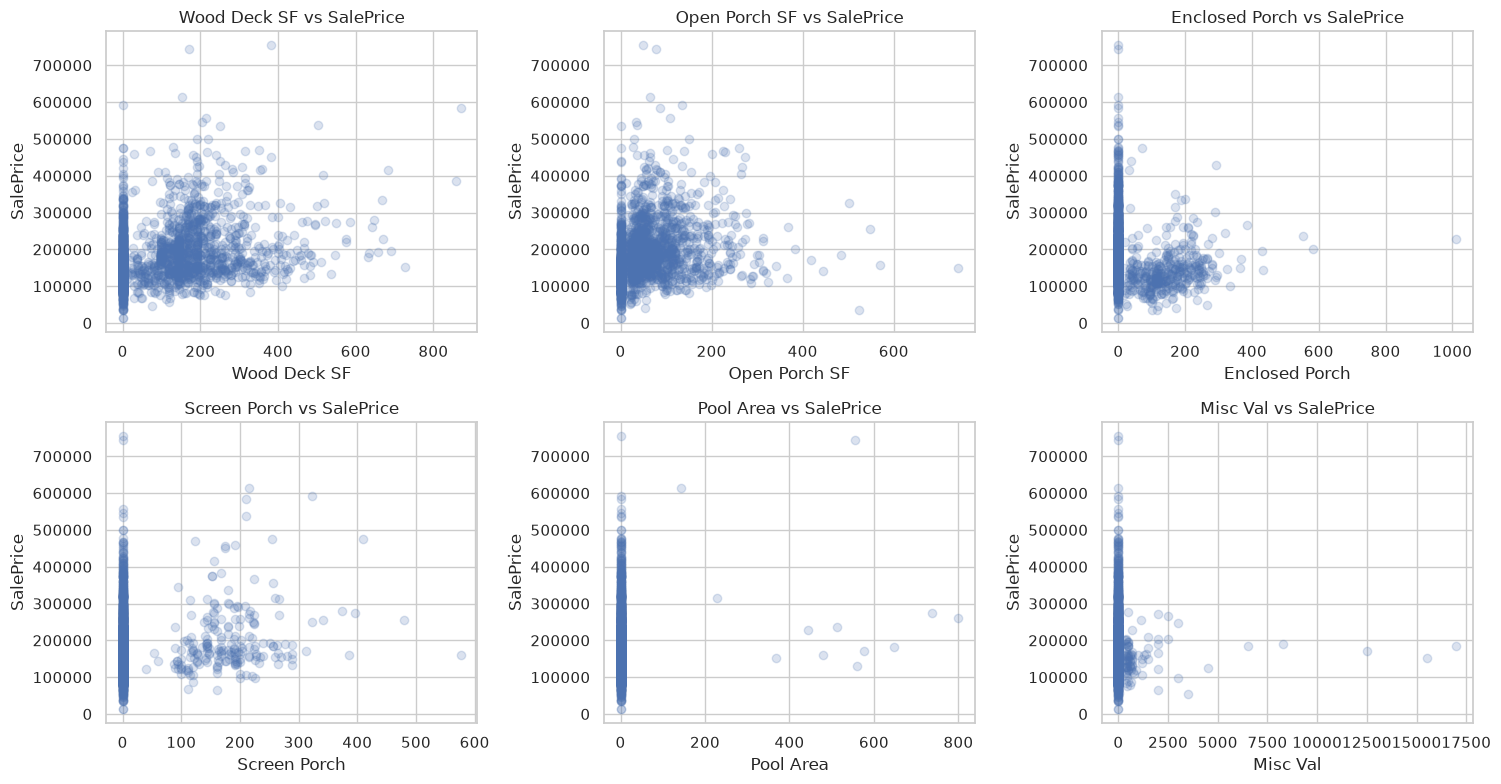

In [67]:
scatter_subplot(outdoor_df,
                ['Wood Deck SF', 'Open Porch SF', 'Enclosed Porch',
                 'Screen Porch', 'Pool Area', 'Misc Val'],
                'SalePrice',
                save_path="./images/scatter-outdoor-vs-price.png")

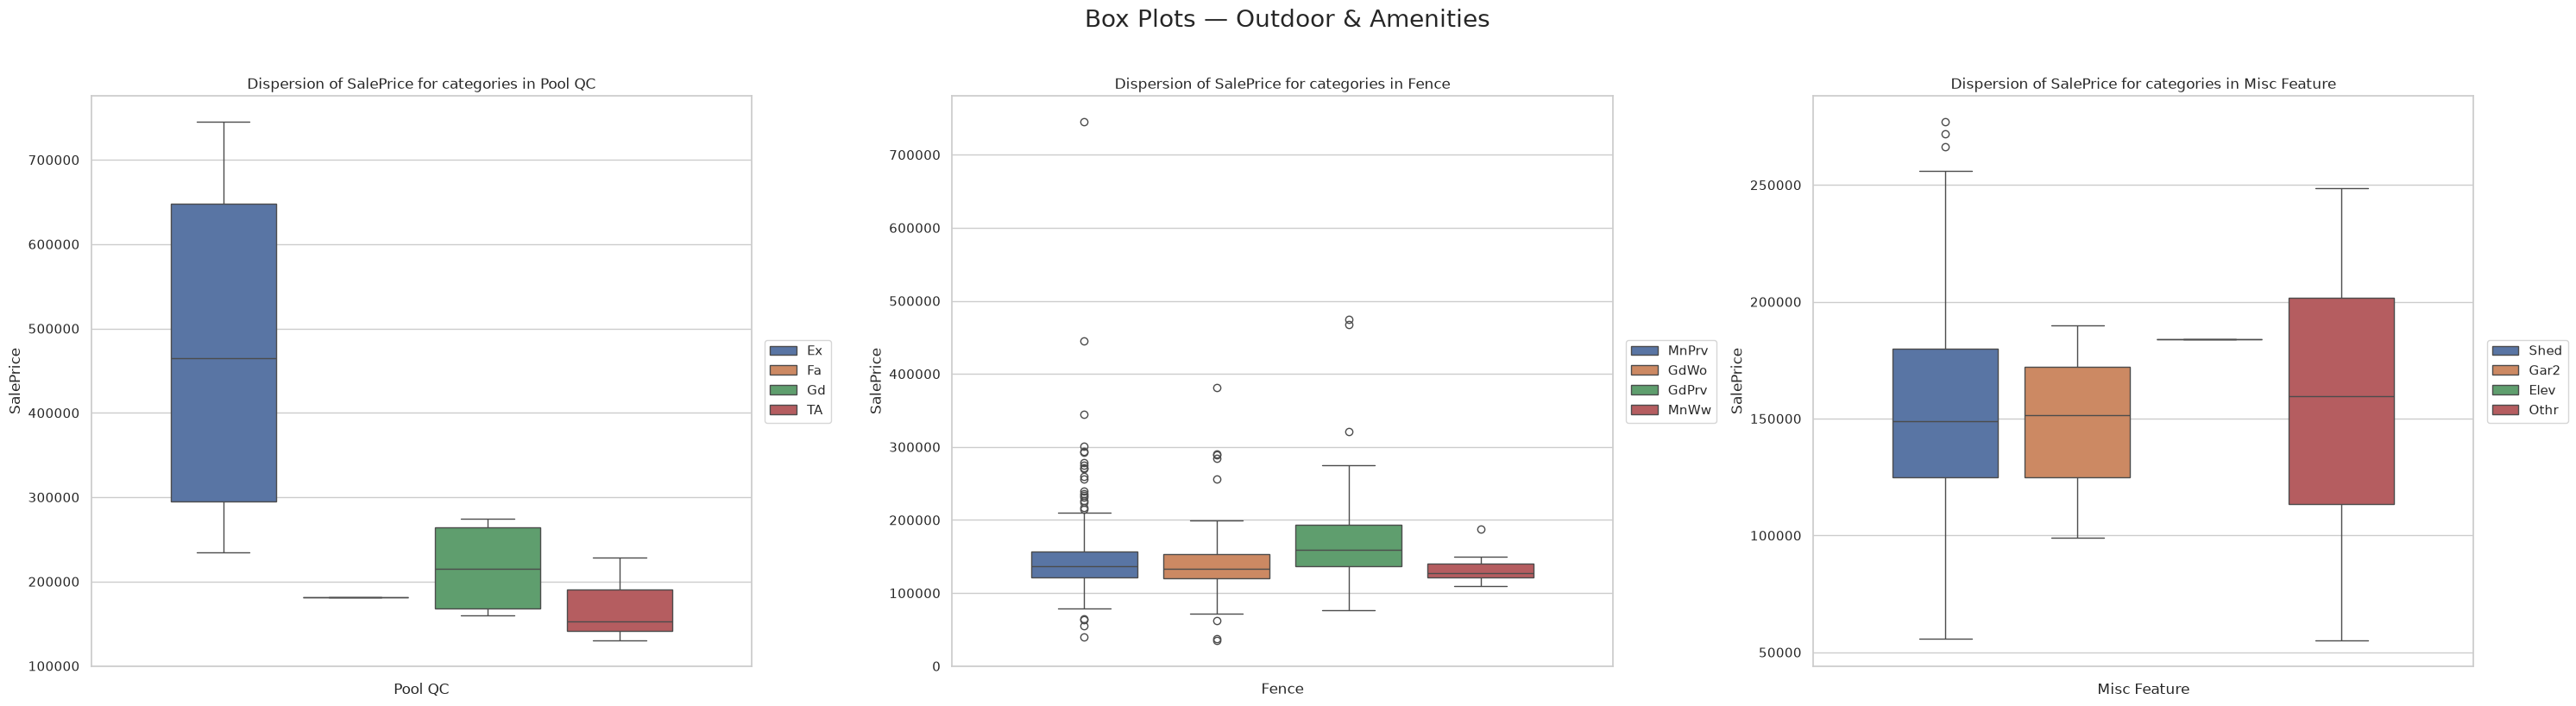

In [68]:
cat_columns = ['Pool QC', 'Fence', 'Misc Feature']

boxplot_grid(outdoor_df, cat_columns, ncols=3,
             save_path="./images/boxplots-for-outdoor-information.png",
             suptitle="Box Plots — Outdoor & Amenities")

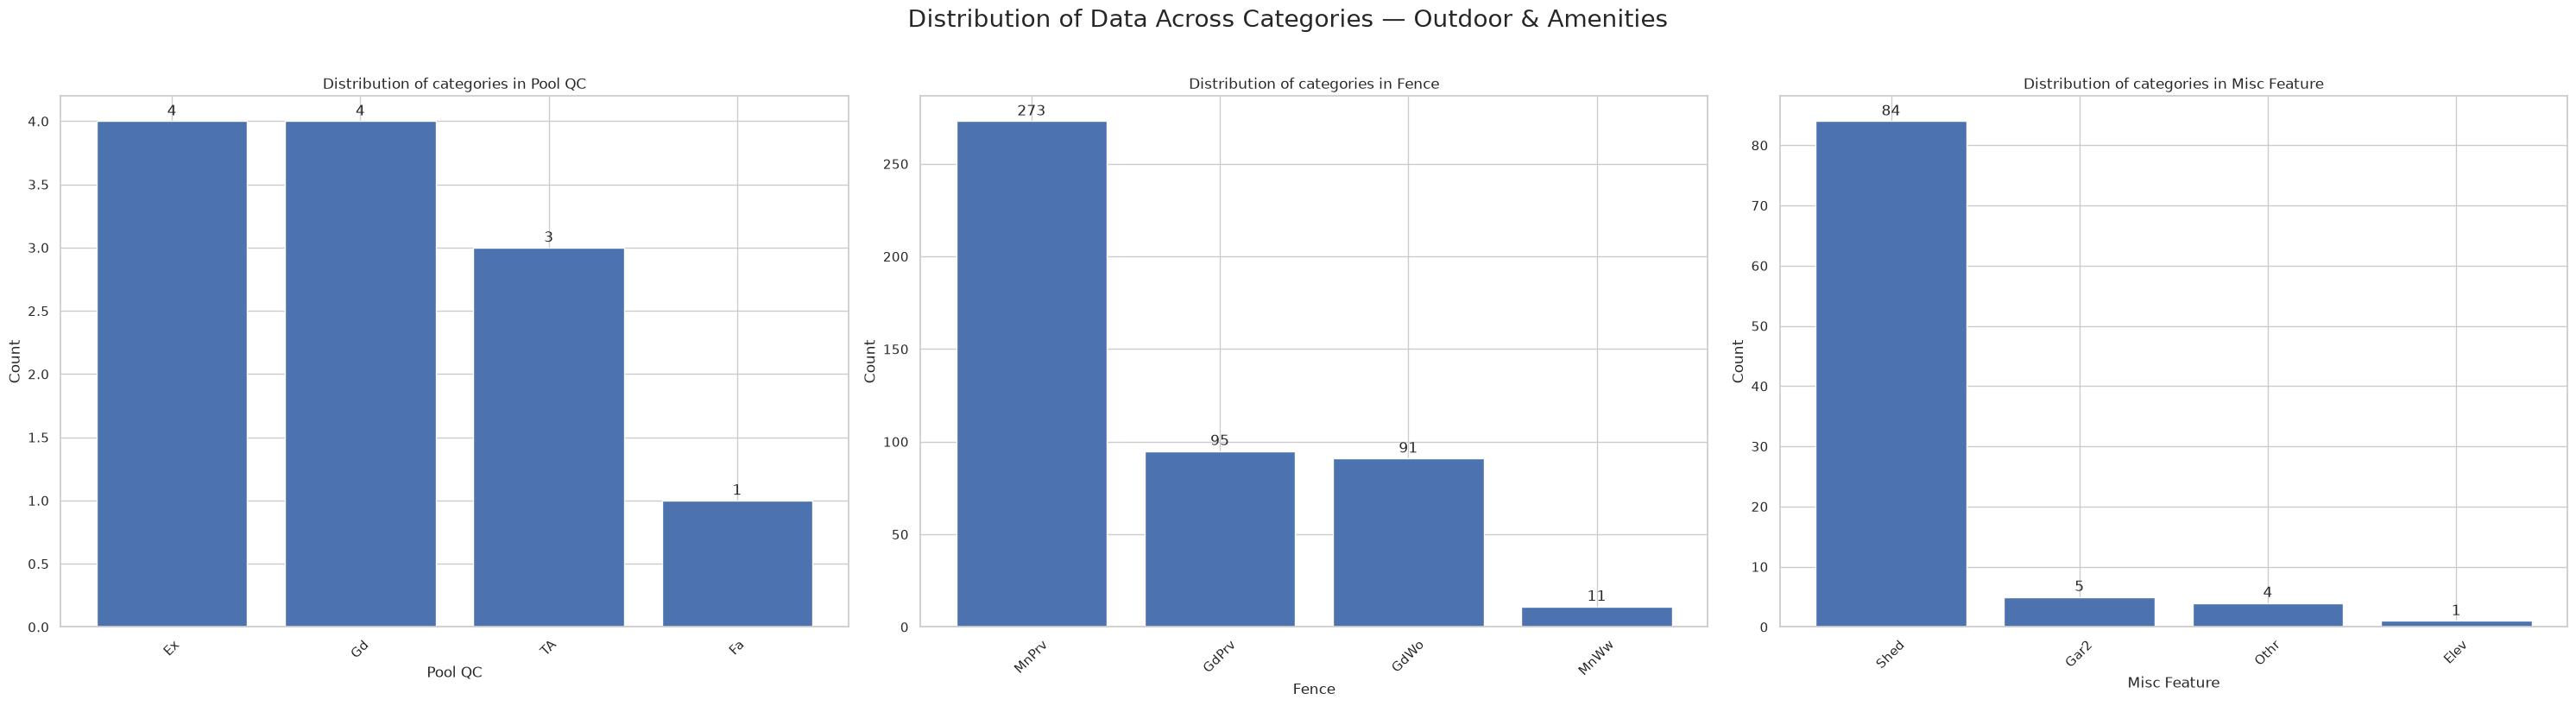

In [69]:
bar_chart_grid(outdoor_df, cat_columns, ncols=3,
               save_path="./images/dispersion-of-data-for-outdoor-information.png",
               suptitle="Distribution of Data Across Categories — Outdoor & Amenities")

In [70]:
missing_summary(outdoor_df)

,Empty rows
Wood Deck SF,0
Open Porch SF,0
Enclosed Porch,0
3Ssn Porch,0
Screen Porch,0
Pool Area,0
Pool QC,2332
Fence,1874
Misc Feature,2250
Misc Val,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| **Pool QC** | ~2332 missing (~99.5%) — means "no pool" | `fillna('None')` → maps to 0 via `QUALITY_MAPPINGS` |
| **Fence** | ~1874 missing (~80%) — means "no fence" | `fillna('NoFence')` — treat as a genuine category |
| **Misc Feature** | ~2250 missing (~96%) — means no miscellaneous feature | `fillna('None')` |

2. Key Predictors

| Column | Spearman ρ | Note |
|---|---|---|
| **Open Porch SF** | ~0.47 | Moderate positive — larger open porches in pricier homes |
| **Wood Deck SF** | ~0.35 | Moderate positive |
| **Enclosed Porch** | ~−0.24 | Negative — enclosed porches are common in older, cheaper homes |

3. Drop Candidates (near-zero variance / no predictive value)

| Column | Reason |
|---|---|
| **Pool Area / Pool QC** | 99.5% zero/missing — only ~12 houses have pools; too sparse to learn from |
| **3Ssn Porch** | 97%+ zeros, Spearman ρ ≈ 0.04 — near-zero signal |
| **Misc Feature / Misc Val** | 96% missing; Misc Val Spearman ρ ≈ −0.05 — no predictive value |

4. Feature Engineering

| Feature | Source | Note |
|---|---|---|
| **TotalPorchSF** | Sum of all porch + deck columns | Already in `AmesFeatureEngineer` — aggregates sparse individual columns into one cleaner signal |

---

---
## Sale Info
| Column | Meaning |
|---|---|
| **Mo Sold** | Month sold (1–12) |
| **Yr Sold** | Year sold (2006–2010) |
| **Sale Type** | Type of sale (Warranty Deed, New construction, Court Officer Deed, Contract, etc.) |
| **Sale Condition** | Condition of sale (Normal, Abnormal, Partial, Family, etc.) |

> **Note:** These are *transaction-level* attributes, not physical property features. They describe *how* the sale happened, not *what* the house is. Including them can help predict sale price for historical data but may not generalize to new listings where sale type/condition is unknown.
---

In [71]:
sale_df = df[['Mo Sold', 'Yr Sold', 'Sale Type', 'Sale Condition', 'SalePrice']]

In [72]:
sale_df.dtypes

Mo Sold           int64
Yr Sold           int64
Sale Type           str
Sale Condition      str
SalePrice         int64
dtype: object

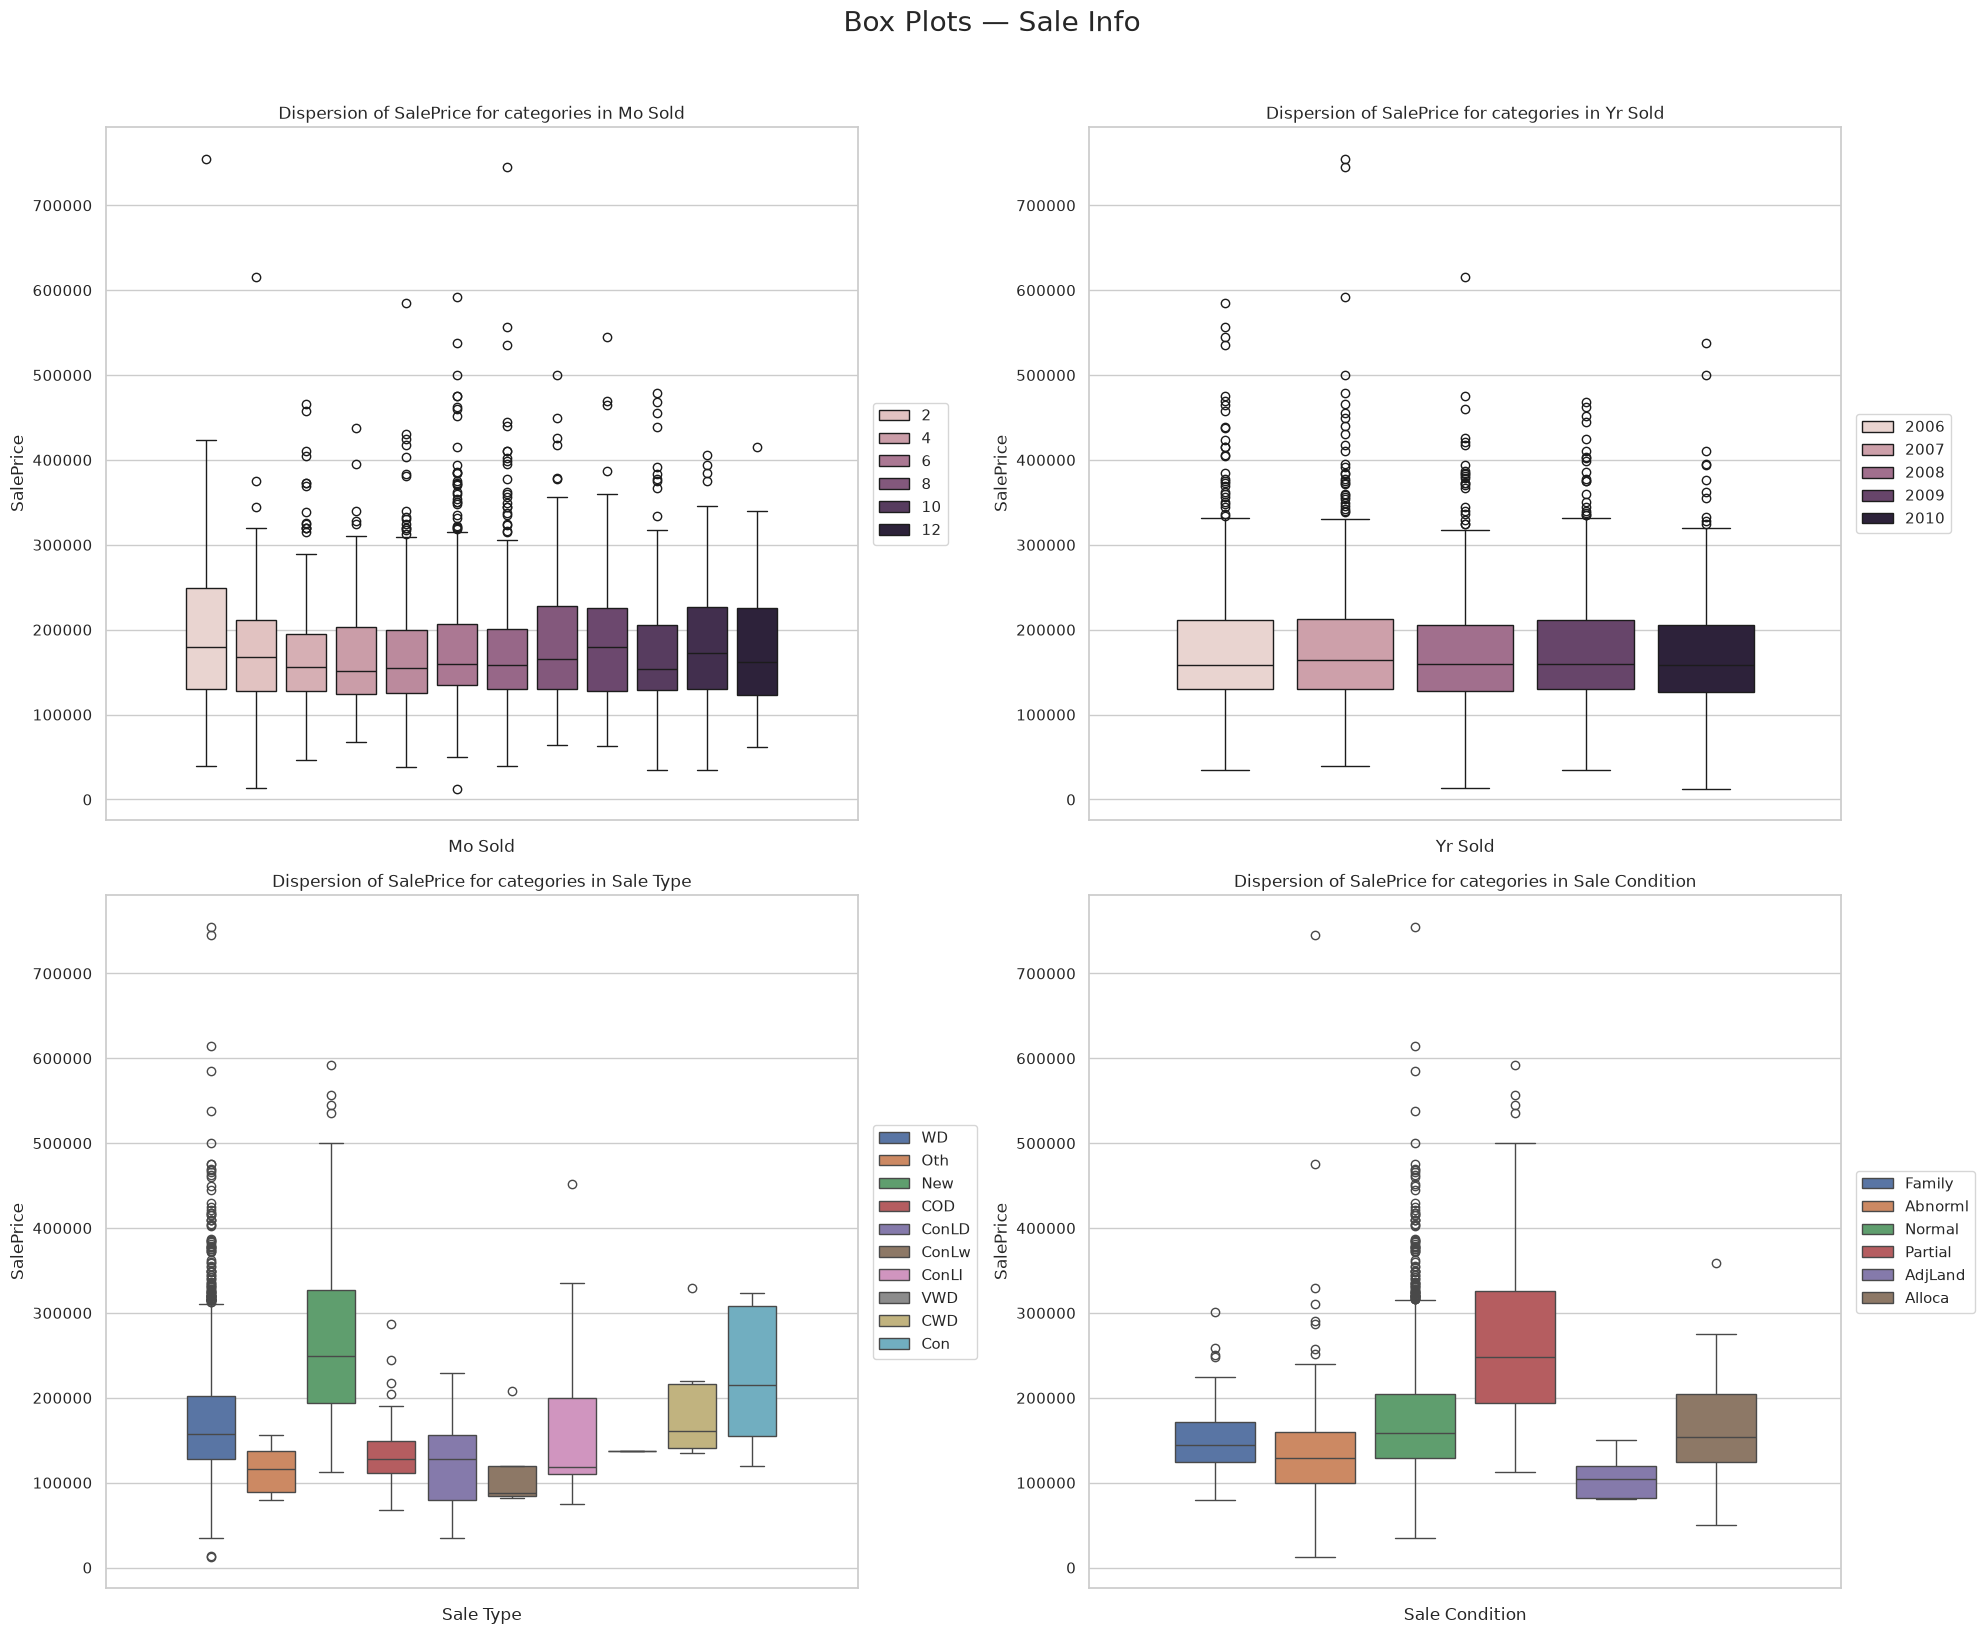

In [73]:
plot_columns = ['Mo Sold', 'Yr Sold', 'Sale Type', 'Sale Condition']

boxplot_grid(sale_df, plot_columns, ncols=2,
             save_path="./images/boxplots-for-sale-information.png",
             suptitle="Box Plots — Sale Info")

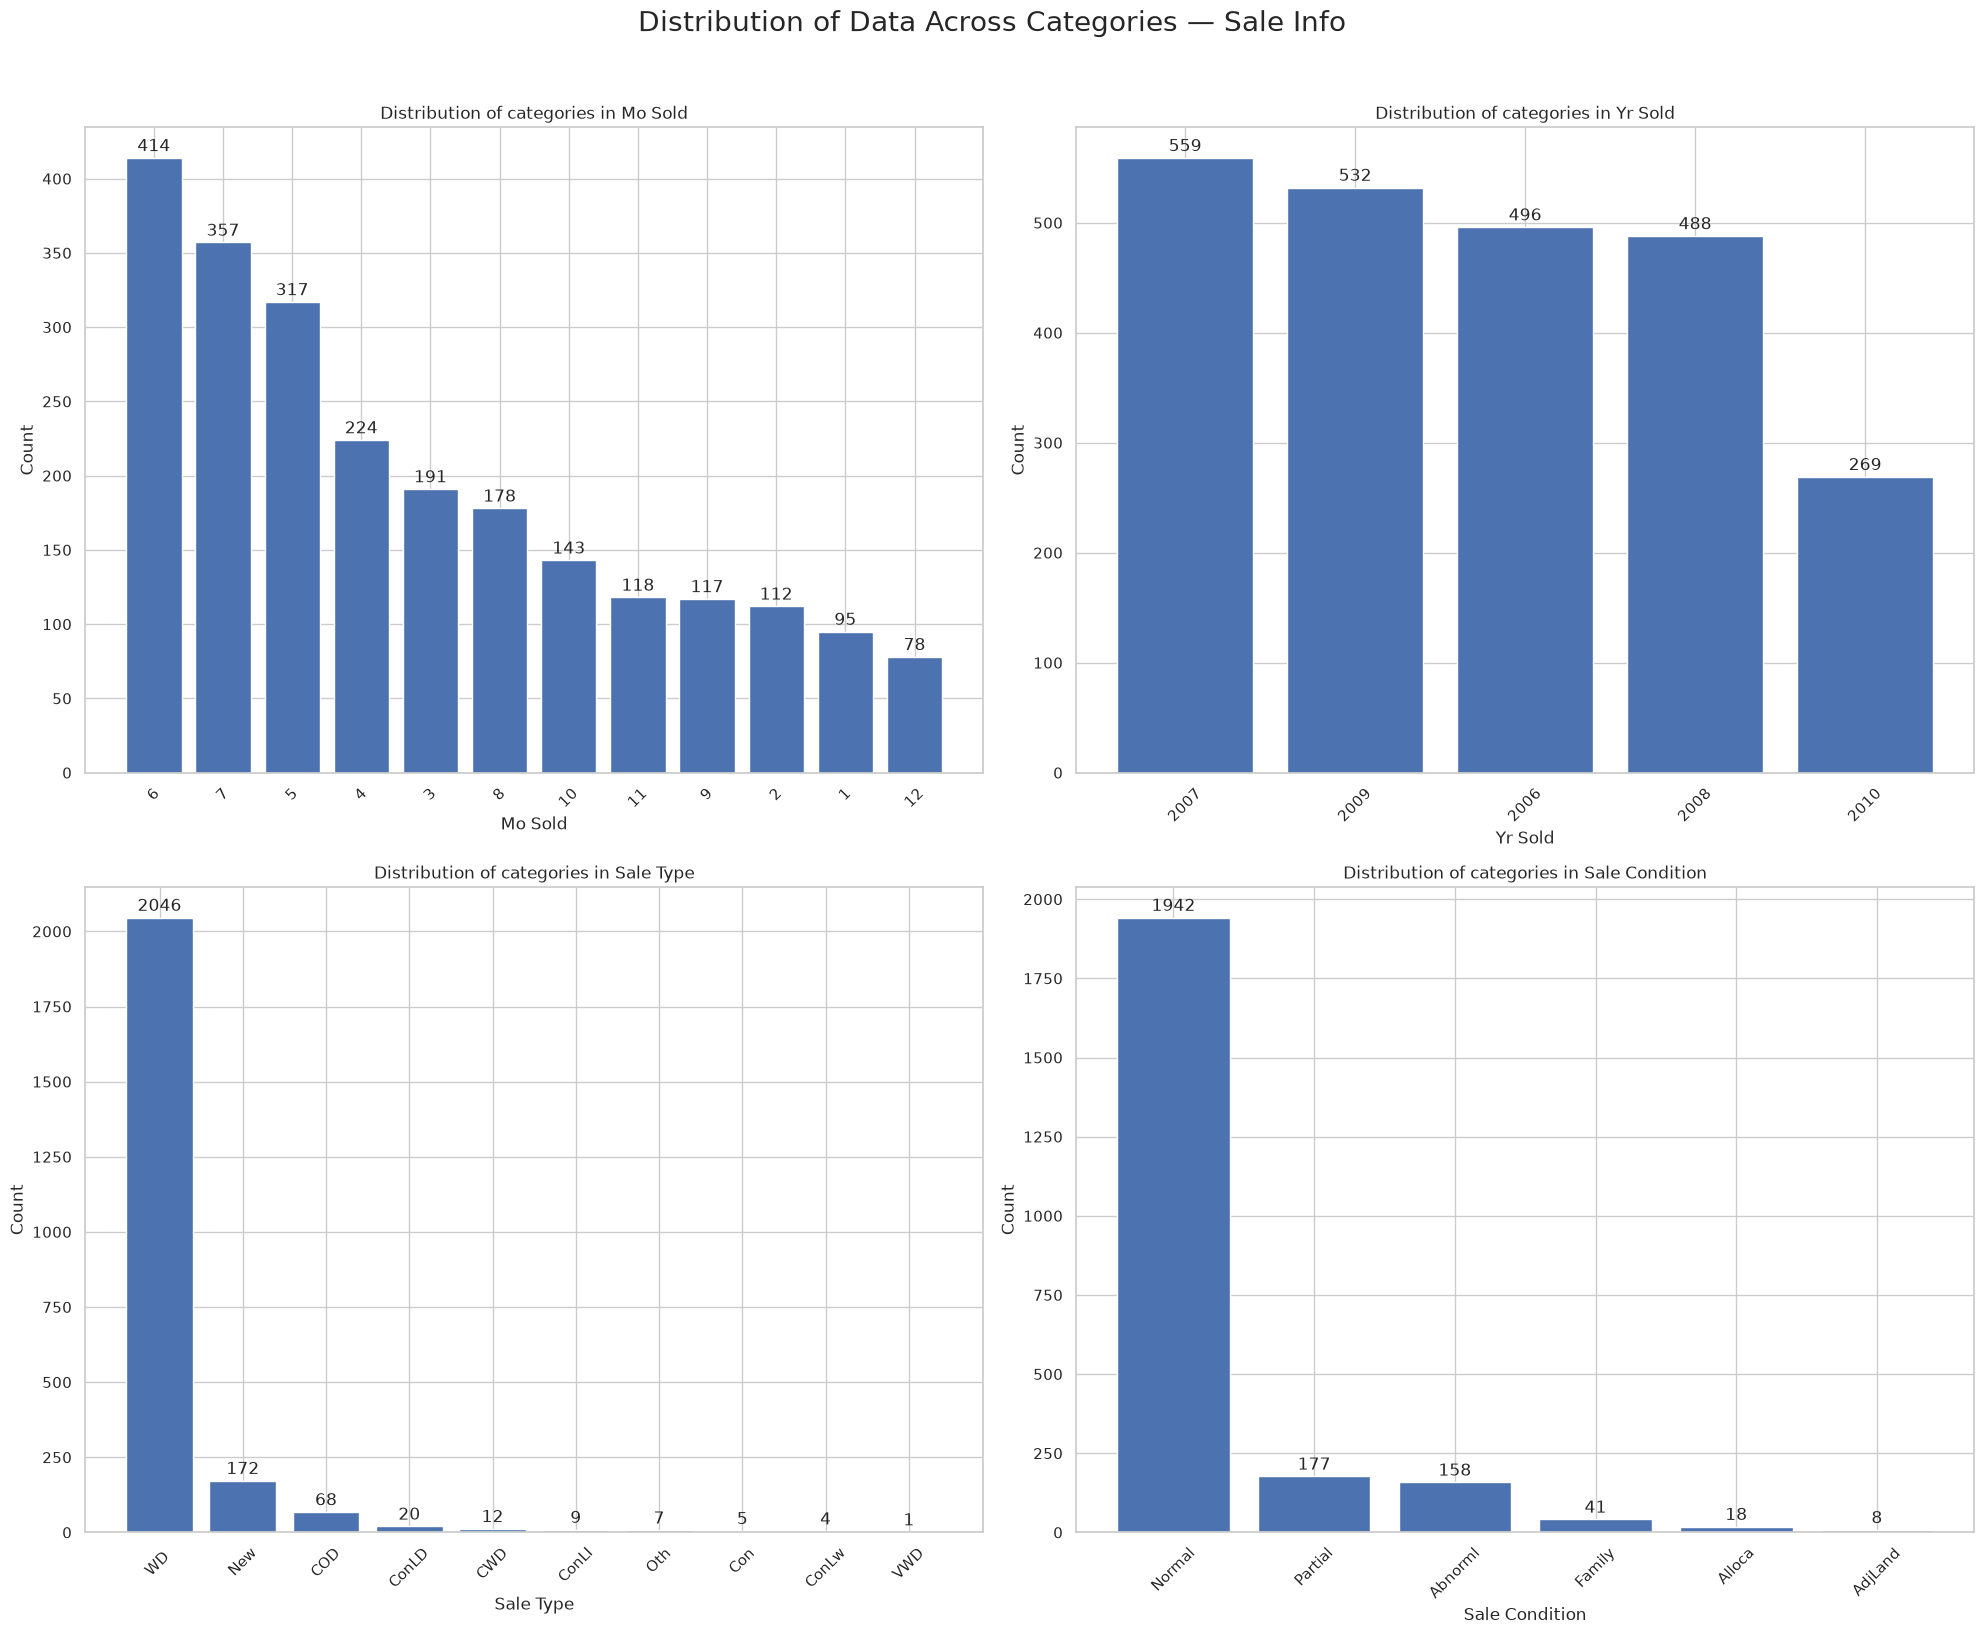

In [74]:
bar_chart_grid(sale_df, plot_columns, ncols=2,
               save_path="./images/dispersion-of-data-for-sale-information.png",
               suptitle="Distribution of Data Across Categories — Sale Info")

In [75]:
missing_summary(sale_df)

,Empty rows
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0
SalePrice,0


---
1. Missing Value Fixes

| Column | Issue | Fix |
|---|---|---|
| — | No missing values in this group | — |

2. Encoding Fixes

| Column | Issue | Fix |
|---|---|---|
| **Mo Sold** | Numeric 1–12 but cyclical/categorical — no ordinal meaning (month 12 is not "more" than month 1) | Treat as categorical for box-plots; consider cyclical encoding (sin/cos) or one-hot |
| **Yr Sold** | Numeric but only 5 unique values (2006–2010) | Treat as categorical — already used for `HouseAgeAtSale` and `RemodAgeAtSale` in feature engineering |

3. Rare-Category Handling

| Column | Rare categories | Fix |
|---|---|---|
| **Sale Type** | ConLD (20), CWD (12), ConLI (9), Oth (7), Con (5), ConLw (4), VWD (1) — all <1% | Collapse all contract/rare types into `'Other'` |
| **Sale Condition** | AdjLand (8), Alloca (18), Family (41) — thin | Consider collapsing AdjLand + Alloca into `'Other'` |

4. Key Observations

| Column | Spearman ρ | Note |
|---|---|---|
| **Mo Sold** | ~0.04 | Negligible — month of sale has almost no linear relationship to price |
| **Yr Sold** | ~−0.02 | Negligible — reflects market-wide trends (2008 crisis), not house attributes |
| **Sale Type = New** | — | "New" construction sales correlate with higher prices, but this overlaps with Year Built/Remod |
| **Sale Condition = Partial** | — | Partial sales (new construction not yet complete) tend to be higher priced |

---